# Klasteryzacja dokumentów 20 Newsgroups — raport główny

**Autorzy:**  
- Patryk Jan Sozański, 300258
- Imię i nazwisko

Ten notebook stanowi raport do projektu grupowania tekstu na zbiorze 20 Newsgroups (UCI). Zawiera opis problemu, podstawy teoretyczne, implementacje kolejnych elementow pipeline'u oraz komorki wykonawcze, ktore uruchamiaja eksperymenty krok po kroku.

Celem projektu jest porownanie reprezentacji dokumentow tekstowych oraz algorytmow klasteryzacji: `K-means`, `klasteryzacji hierarchicznej`, `DBSCAN` oraz `klasteryzacji spektralnej`. Etykiety z `20 Newsgroups` nie sa uzywane do uczenia ani grupowania; pojawiaja sie dopiero w ocenie zewnetrznej przez `ARI`.

## Opis problemu

Klasteryzacja dokumentow to zadanie nienadzorowane: chcemy grupowac teksty tak, aby dokumenty podobne tematycznie trafialy do tych samych klastrow, bez wykorzystania etykiet klas podczas uczenia.  
W praktyce problem sprowadza sie do:
- wyboru reprezentacji tekstu (jak zamienic dokument na wektor),
- wyboru algorytmu klasteryzacji,
- doboru hiperparametrow (np. liczba klastrow `k`, linkage, `eps`),
- oceny jakosci klastrow metrykami wewnetrznymi i zewnetrznymi.

## Podejscie eksperymentalne

Pipeline jest uruchamiany etapowo:
1. **Przygotowanie danych**: czyszczenie, normalizacja, tokenizacja i lematyzacja.  
2. **Budowa reprezentacji**:
    - bazowa, podstawowa reprezentacja `TF-IDF` (baseline),
    - statyczne embeddingi (`GloVe` jako proxy, `fastText`),
    - kontekstowe embeddingi (`SBERT`).
3. **Klasteryzacja**:
    - `K-means`,
    - `Agglomerative Clustering`,
    - `DBSCAN`,
    - `Spectral Clustering`.
4. **Ocena jakosci**:
    - metryki wewnetrzne: `silhouette`, `Davies-Bouldin`, `Dunn`,
    - metryka zewnetrzna: `ARI` (tylko do porownania z rzeczywistymi etykietami).
5. **Analiza i raportowanie**:
    - wybor najlepszych przebiegow,
    - interpretacja klastrow przez slowa kluczowe i dokumenty reprezentatywne,
    - zapis artefaktow (CSV/JSON/wykresy/MLflow).

Eksperyment wspiera dwa tryby pracy:
- `quick` do szybkiej walidacji calego przeplywu,
- `full` do pelnej analizy i wynikow koncowych.

## 1. Srodowisko uruchomieniowe

Notebook nie wykonuje lokalnie komend instalacyjnych w komorkach. Lokalnie powinien byc uruchamiany na kernelu `Python (.venv)`, przygotowanym przez `setup_local_env.sh`. Komorka ponizej tylko sprawdza, czy wymagane biblioteki sa dostepne, i podaje jasny komunikat, jesli brakuje srodowiska.

In [1]:

import importlib.util
import sys
from pathlib import Path

REQUIRED_PACKAGES = ['mlflow', 'matplotlib', 'numpy', 'pandas', 'nltk', 'sentence_transformers', 'sklearn', 'gensim', 'tqdm']
missing_packages = [pkg for pkg in REQUIRED_PACKAGES if importlib.util.find_spec(pkg) is None]

print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version.split()[0]}")

if missing_packages:
    raise RuntimeError(
        "Missing packages: " + ", ".join(missing_packages) + "\n"
        "Local setup: run ./setup_local_env.sh and select kernel 'Python (.venv) ZUM'."
    )

print("Environment check passed.")

Python executable: /Users/patrykjansozanski/Desktop/studia/zum/projekt/text_group_20Newsgroups/.venv/bin/python
Python version: 3.13.13
Environment check passed.


## 1. Konfiguracja i parametry sterujące

W celu łatwego zarządzania eksperymentem, wprowadzamy globalny słownik konfiguracyjny. Pozwala to na:
1. Szybkie przełączanie między trybem szybkiego testowania (`quick`), a pełną ewaluacją (`full`).
2. Centralne zarządzanie siatkami parametrów dla każdego z algorytmów.
3. Parametryzację kosztownych operacji wektoryzacji i obliczania metryk dających odpowiedzi w czasie rzeczywistym.

Główne klucze konfiguracji:
- `mode`: tryb wykonania (`quick` lub `full`),
- `seed`: ziarno losowości dla zapewnienia powtarzalności (reprodukowalność),
- `kmeans_sample_size`: liczba dokumentów używana dla algorytmu K-Means (algorytm o złożoności liniowej $O(n)$),
- `hierarchical_sample_size`: limit próbek dla klasteryzacji hierarchicznej (algorytm o złożoności $O(n^2)$),
- `dbscan_sample_size`: limit próbek dla algorytmu DBSCAN (algorytm gęstościowy operujący na macierzy odległości $O(n^2)$) - **TODO**,
- `spectral_sample_size`: limit próbek dla klasteryzacji spektralnej ($O(n^3)$ lub na wybranym grafie $O(n^2)$) - **TODO**,
- `silhouette_sample_size`: próbkowanie dla miary silhouette,
- `davies_bouldin_sample_size`: próbkowanie dla miary Davies-Bouldin,
- `ari_sample_size`: próbkowanie dla miary ARI,
- `dunn_max_points`: limit punktów do liczenia Dunn Index,
- `embedding_models`: aktywne modele embeddingowe i ich parametry,
- `clustering_grid`: siatki hiperparametrów dla wybranych algorytmów (**TODO :** Należy uzupełnić siatki DBSCAN/Spectral),
- `artifact_dir`: katalog zapisywania wynikowych tabel, wykresów, cache i logów środowiska `MLflow`,
- `force_recompute_embeddings`: możliwość wymuszenia ponownego przeliczania embeddingów (zignorowanie zachowanego cache),
- `static_progress`, `sbert_batch_size`: specyficzne parametry wykonawcze widoków.

### Tryb `quick` (iteracyjny i deweloperski)
Przeznaczenie: szybkie testy notebooka, sprawdzenie logiki i debugowanie przepływu na zmniejszonej próbce, aby dać sensowne wyniki bez wielogodzinnych oczekiwań.

Parametry losowań próbek (algorytmy):
- `kmeans_sample_size = 3000`,
- `hierarchical_sample_size = 3000`,
- `dbscan_sample_size = TODO`,
- `spectral_sample_size = TODO`.

Parametry losowań próbek (miary jakości):
- `silhouette_sample_size = 1500`,
- `davies_bouldin_sample_size = 3000`,
- `ari_sample_size = 3000`,
- `dunn_max_points = 1500`.

Siatki (`clustering_grid`) w trybie `quick`:
- `kmeans`: `k = [15, 20, 25]`, `n_init = [10]`, `max_iter = 300`,
- `hierarchical`: `k = [15, 20, 25]`, `linkage = ["average", "ward"]`,
- `dbscan`: **TODO**,
- `spectral`: **TODO**.

### Tryb `full` (produkcyjny)
Przeznaczenie: docelowe grupowanie całego dostępnego zbioru korpusu 20 Newsgroups (prawie 19 tys. dokumentów), oraz bogatsze poszukiwania siatki (grid search).

Parametry losowań próbek (algorytmy) w `full`:
- `kmeans_sample_size = None` (cały zbiór),
- `hierarchical_sample_size = None` (cały zbiór),
- `dbscan_sample_size = None` (**TODO**: można ustawić limit jeśli zabraknie pamięci),
- `spectral_sample_size = None` (**TODO**: można ustawić limit jeśli zabraknie pamięci).

Parametry losowań próbek (miary jakości) w `full`:
- `silhouette_sample_size = 3000` (kontrolowane ograniczenie kosztu obliczeń),
- `davies_bouldin_sample_size = None` (bez przycinania),
- `ari_sample_size = None` (bez przycinania),
- `dunn_max_points = 3000` (kontrolowane ograniczenie kosztu obliczeń).

Siatki (`clustering_grid`) w trybie `full`:
- `kmeans`: `k = [10, 15, 20, 25, 30]`, `n_init = [10, 30]`, `max_iter = 300`,
- `hierarchical`: `k = [10, 15, 20, 25, 30]`, `linkage = ["average", "complete", "ward"]`,
- `dbscan`: **TODO**,
- `spectral`: **TODO**.

Uwaga wydajnościowa: dla metryk opartych o odległości para-punkt (`silhouette`, `Dunn`) pełny zbiór może być kosztowny pamięciowo i czasowo, dlatego pozostawiono osobne parametry próbkowania dla każdej miary.

In [2]:
from __future__ import annotations

import gc
import json
import math
import os
import random
import re
import time
import warnings
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import mlflow
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (
    adjusted_rand_score,
    davies_bouldin_score,
    pairwise_distances,
    silhouette_score,
)
from sklearn.preprocessing import Normalizer
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


DEFAULT_EMBEDDING_MODELS: Dict[str, Dict[str, Any]] = {
    "word2vec_proxy_glove": {
        "enabled": True,
        "family": "static",
        "source": "glove-wiki-gigaword-300",
        "label": "Static proxy (GloVe 300)",
    },
    "fasttext": {
        "enabled": True,
        "family": "static",
        "source": "fasttext-wiki-news-subwords-300",
        "label": "fastText wiki-news 300",
    },
    "sbert": {
        "enabled": True,
        "family": "transformer",
        "source": "sentence-transformers/all-MiniLM-L6-v2",
        "label": "SBERT MiniLM-L6-v2",
    },
}


DEFAULT_CLUSTERING_GRID: Dict[str, Dict[str, Any]] = {
    "quick": {
        "kmeans": {
            "k_values": [15, 20, 25],
            "n_init_values": [10],
            "max_iter": 300,
        },
        "hierarchical": {
            "k_values": [15, 20, 25],
            "linkages": ["average", "ward"],
        },
        # TODO: Uzupełnij parametry dla DBSCAN ze słownikiem (quick)
        "dbscan": {
            # TODO ...
        },
        # TODO: Uzupełnij parametry dla modeli spektralnych (quick)
        "spectral": {
            # TODO ...
        }
    },
    "full": {
        "kmeans": {
            "k_values": [10, 15, 20, 25, 30],
            "n_init_values": [10, 30],
            "max_iter": 300,
        },
        "hierarchical": {
            "k_values": [10, 15, 20, 25, 30],
            "linkages": ["average", "complete", "ward"],
        },
        # TODO: Uzupełnij parametry alg. gęstościowych dla szerokich łowów (full)
        "dbscan": {
           # TODO ...
        },
        # TODO: Uzupełnij parametry dla modeli spektralnych (full)
        "spectral": {
            # TODO ...
        }
    },
}


_GENSIM_MODELS: Dict[str, Any] = {}
_SBERT_MODELS: Dict[str, SentenceTransformer] = {}


def default_config(mode: str) -> Dict[str, Any]:
    mode = mode.lower().strip()
    if mode not in {"quick", "full"}:
        raise ValueError(f"Unsupported mode: {mode}")

    artifact_dir = Path(f"artifacts_{mode}")
    base_config: Dict[str, Any] = {
        "mode": mode,
        "seed": 42,

        # Minimalna dlugosc dokumentu: dokument przechodzi, gdy spelnia
        # co najmniej jeden z progow (znaki lub tokeny po basic cleaning).
        "min_clean_chars": 50,
        "min_basic_tokens": 8,

        # Limity dla poszczególnych algorytmów na bazie ich czasu wykonań K-Means O(n) reszta O(n^2)
        "kmeans_sample_size": 3000 if mode == "quick" else None,
        "hierarchical_sample_size": 3000 if mode == "quick" else None,

        # TODO: Określ limit docelowych dokumentów poniżej, aby nie operować na pełnym zbiorze w trybie quick
        "dbscan_sample_size": None,  # TODO
        "spectral_sample_size": None,  # TODO

        # Próbki dla miar jakości
        "silhouette_sample_size": 1500 if mode == "quick" else 3000,
        "davies_bouldin_sample_size": 3000 if mode == "quick" else None,
        "ari_sample_size": 3000 if mode == "quick" else None,
        "dunn_max_points": 1500 if mode == "quick" else 3000,

        "embedding_models": json.loads(json.dumps(DEFAULT_EMBEDDING_MODELS)),
        "clustering_grid": json.loads(
            json.dumps(DEFAULT_CLUSTERING_GRID[mode])
        ),
        "mlflow_experiment": f"zum_20newsgroups_{mode}",
        "artifact_dir": str(artifact_dir),
        "explain_top_terms": 10,
        "explain_top_docs": 5,
        "interpretation_max_features": 15000,
        "sbert_batch_size": 32,
        "static_progress": True,
        "force_recompute_embeddings": False,
    }
    return base_config


def resolve_config(config: Optional[Dict[str, Any]] = None) -> Dict[str, Any]:
    if config is None:
        return default_config("quick")

    merged = default_config(config.get("mode", "quick"))
    for key, value in config.items():
        if isinstance(value, dict) and isinstance(merged.get(key), dict):
            merged[key].update(value)
        else:
            merged[key] = value

    artifact_dir = Path(merged["artifact_dir"])
    merged["artifact_dir"] = str(artifact_dir)
    return merged

/Users/patrykjansozanski/Desktop/studia/zum/projekt/text_group_20Newsgroups/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Wybor trybu i parametrow

Ta komorka tworzy slownik `CONFIG`. Zmien `MODE` na `full`, gdy chcesz wykonac pelniejszy eksperyment. Dla pracy iteracyjnej zostaw `quick`, bo szybciej sprawdza caly przeplyw.

In [3]:
MODE = "full"
CONFIG = default_config(MODE)

CONFIG["force_recompute_embeddings"] = False
CONFIG["static_progress"] = True

# Filtr dlugosci dokumentu: dokument przechodzi, gdy spelnia prog znakow lub tokenow.
CONFIG["min_clean_chars"] = 50
CONFIG["min_basic_tokens"] = 8
CONFIG

{'mode': 'full',
 'seed': 42,
 'min_clean_chars': 50,
 'min_basic_tokens': 8,
 'kmeans_sample_size': None,
 'hierarchical_sample_size': None,
 'dbscan_sample_size': None,
 'spectral_sample_size': None,
 'silhouette_sample_size': 3000,
 'davies_bouldin_sample_size': None,
 'ari_sample_size': None,
 'dunn_max_points': 3000,
 'embedding_models': {'word2vec_proxy_glove': {'enabled': True,
   'family': 'static',
   'source': 'glove-wiki-gigaword-300',
   'label': 'Static proxy (GloVe 300)'},
  'fasttext': {'enabled': True,
   'family': 'static',
   'source': 'fasttext-wiki-news-subwords-300',
   'label': 'fastText wiki-news 300'},
  'sbert': {'enabled': True,
   'family': 'transformer',
   'source': 'sentence-transformers/all-MiniLM-L6-v2',
   'label': 'SBERT MiniLM-L6-v2'}},
 'clustering_grid': {'kmeans': {'k_values': [10, 15, 20, 25, 30],
   'n_init_values': [10, 30],
   'max_iter': 300},
  'hierarchical': {'k_values': [10, 15, 20, 25, 30],
   'linkages': ['average', 'complete', 'ward']},

## 4. Przygotowanie srodowiska i danych

Ten etap tworzy katalogi artefaktow, ustawia cache dla modeli, pobiera zasoby NLTK oraz laduje zbior `20 Newsgroups`. Usuwamy naglowki, stopki i cytaty, poniewaz moglyby sztucznie zdradzac grupe dyskusyjna i zaburzac klasteryzacje semantyczna.

Dla embeddingow statycznych tekst jest silniej normalizowany: male litery, usuniecie znakow nieliterowych, stop words i lematyzacja. Dla `SBERT` zachowujemy bardziej naturalna postac tekstu, bo model ma wlasny tokenizer i korzysta z kontekstu zdania.

Dodatkowo eliminujemy zbyt krotkie wiadomosci na podstawie progow `min_clean_chars` i `min_basic_tokens`. Krotka argumentacja: takie wpisy zwykle niosa za malo informacji semantycznej, podnosza poziom szumu i pogarszaja stabilnosc metryk klasteryzacji.

Szczegolowy przebieg tego kroku:
1. Tworzymy katalog roboczy dla wybranego trybu (`artifacts_quick` albo `artifacts_full`) oraz podkatalogi na cache, tabele, wykresy i runy `MLflow`.
2. Ustawiamy zmienne srodowiskowe wskazujace, gdzie zapisywac modele `gensim` i `sentence-transformers`, aby nie mieszac cache z innymi projektami.
3. Pobieramy zasoby `NLTK` potrzebne do czyszczenia i lematyzacji tekstu.
4. Wczytujemy zbior `20 Newsgroups` do `DataFrame`, nadajemy identyfikator `doc_id` i zachowujemy etykiety tylko do ewaluacji.
5. Odfiltrowujemy dokumenty niespelniajace minimalnej dlugosci (`min_clean_chars`, `min_basic_tokens`).
6. Budujemy kilka rownoleglych reprezentacji tekstu: surowa, podstawowo wyczyszczona, tokeny do embeddingow statycznych, tekst do analizy slow oraz tekst do modelu `SBERT`.
7. Na koncu przygotowujemy osobne widoki dokumentow (`dataset_views`) dla roznych algorytmow, aby kontrolowac wielkosc probek i nie mieszac konfiguracji `quick` z `full`.

In [4]:
def setup_environment(config: Dict[str, Any]) -> None:
    import nltk

    artifact_dir = Path(config["artifact_dir"])
    cache_dir = artifact_dir / "cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    (artifact_dir / "tables").mkdir(parents=True, exist_ok=True)
    (artifact_dir / "plots").mkdir(parents=True, exist_ok=True)
    (artifact_dir / "mlruns").mkdir(parents=True, exist_ok=True)

    # Trzymamy cache modeli lokalnie w katalogu artefaktow danego trybu eksperymentu.
    os.environ["GENSIM_DATA_DIR"] = str(cache_dir / "gensim-data")
    os.environ["SENTENCE_TRANSFORMERS_HOME"] = str(cache_dir / "sentence-transformers")
    os.environ["TOKENIZERS_PARALLELISM"] = "false"

    # Zasoby NLTK sa potrzebne do stop-words i lematyzacji w preprocessingu statycznym.
    nltk.download("stopwords", quiet=True)
    nltk.download("wordnet", quiet=True)
    nltk.download("omw-1.4", quiet=True)

    mlflow.set_tracking_uri((artifact_dir / "mlruns").resolve().as_uri())
    mlflow.set_experiment(config["mlflow_experiment"])


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)


def load_dataset(config: Dict[str, Any]) -> pd.DataFrame:
    data_home = Path(config["artifact_dir"]) / "cache" / "sklearn-data"
    min_clean_chars = int(config.get("min_clean_chars", 0) or 0)
    min_basic_tokens = int(config.get("min_basic_tokens", 0) or 0)

    print("Downloading/loading 20 Newsgroups dataset...")
    dataset = fetch_20newsgroups(
        subset="all",
        remove=("headers", "footers", "quotes"),
        data_home=str(data_home),
    )

    # Tworzymy jedna glowna tabele dokumentow, a etykiety zachowujemy tylko do ewaluacji.
    df = pd.DataFrame(
        {
            "doc_id": np.arange(len(dataset.data), dtype=int),
            "text_raw": [text if isinstance(text, str) else "" for text in dataset.data],
            "target": dataset.target.astype(int),
        }
    )
    df["target_name"] = df["target"].map(lambda idx: dataset.target_names[idx])

    # Liczymy metryki dlugosci na podstawowym czyszczeniu i odrzucamy skrajnie krotkie dokumenty.
    df["text_clean_basic"] = df["text_raw"].map(clean_text_basic)
    df["clean_char_count"] = df["text_clean_basic"].map(len)
    df["basic_token_count"] = df["text_clean_basic"].map(lambda t: len(t.split()) if t else 0)

    initial_docs = len(df)
    if min_clean_chars > 0 or min_basic_tokens > 0:
        keep_mask = pd.Series(False, index=df.index)
        if min_clean_chars > 0:
            keep_mask = keep_mask | (df["clean_char_count"] >= min_clean_chars)
        if min_basic_tokens > 0:
            keep_mask = keep_mask | (df["basic_token_count"] >= min_basic_tokens)
        df = df.loc[keep_mask].reset_index(drop=True)

    removed_docs = initial_docs - len(df)

    # Rozdzielamy preprocessing na kilka sciezek, bo modele statyczne i SBERT
    # potrzebuja innej postaci tekstu wejsciowego.
    df["static_tokens"] = df["text_clean_basic"].map(preprocess_for_static_embeddings)
    df["analysis_text"] = df["static_tokens"].map(" ".join)
    df["sbert_text"] = df["text_clean_basic"].map(preprocess_for_sbert)
    df["static_token_count"] = df["static_tokens"].map(len)

    print(
        f"Loaded {initial_docs} documents; kept {len(df)} after length filtering "
        f"(removed: {removed_docs}, min_clean_chars={min_clean_chars}, "
        f"min_basic_tokens={min_basic_tokens})."
    )
    print(
        f"Empty after static preprocessing (post-filter): "
        f"{(df['static_token_count'] == 0).sum()}"
    )
    return df


def prepare_dataset_views(
    dataset_df: pd.DataFrame, config: Dict[str, Any]
) -> Dict[str, np.ndarray]:
    rng = np.random.default_rng(config["seed"])
    all_doc_ids = dataset_df["doc_id"].to_numpy()

    def sample_ids(size_key: str) -> np.ndarray:
        val = config.get(size_key)
        if val is None or val >= len(all_doc_ids):
            return all_doc_ids.copy()
        ids = rng.choice(all_doc_ids, size=val, replace=False)
        return np.sort(ids)

    # Każdy algorytm dostaje własny widok dokumentów. Dzięki temu łatwo pokazać,
    # które próbki są używane w quick/full i niezależnie sterować kosztownymi metodami.
    return {
        "kmeans": sample_ids("kmeans_sample_size"),
        "hierarchical": sample_ids("hierarchical_sample_size"),
        "dbscan": sample_ids("dbscan_sample_size"),
        "spectral": sample_ids("spectral_sample_size"),
    }


def clean_text_basic(text: str) -> str:
    if not text:
        return ""
    text = text.replace("\x00", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def preprocess_for_sbert(text: str) -> str:
    text = clean_text_basic(text)
    return text if text else "empty document"


_STOPWORDS: Optional[set[str]] = None
_LEMMATIZER: Optional[WordNetLemmatizer] = None


def preprocess_for_static_embeddings(text: str) -> List[str]:
    global _STOPWORDS, _LEMMATIZER

    if _STOPWORDS is None:
        _STOPWORDS = set(stopwords.words("english"))
    if _LEMMATIZER is None:
        _LEMMATIZER = WordNetLemmatizer()

    text = clean_text_basic(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [token for token in text.split() if len(token) > 1]
    cleaned = [
        _LEMMATIZER.lemmatize(token)
        for token in tokens
        if token not in _STOPWORDS
    ]
    return cleaned

In [5]:

setup_environment(CONFIG)
set_seed(CONFIG["seed"])

dataset_df = load_dataset(CONFIG)
dataset_views = prepare_dataset_views(dataset_df, CONFIG)

display(dataset_df[["doc_id", "target_name", "static_token_count", "text_clean_basic"]].head())
print({name: len(doc_ids) for name, doc_ids in dataset_views.items()})

2026/04/25 19:11:11 INFO mlflow.tracking.fluent: Experiment with name 'zum_20newsgroups_full' does not exist. Creating a new experiment.


Downloading/loading 20 Newsgroups dataset...
Loaded 18846 documents; kept 17986 after length filtering (removed: 860, min_clean_chars=50, min_basic_tokens=8).
Empty after static preprocessing (post-filter): 4


,doc_id,target_name,static_token_count,text_clean_basic
0,0,rec.sport.hockey,71,I am sure some bashers of Pens fans are pretty...
1,1,comp.sys.ibm.pc.hardware,35,My brother is in the market for a high-perform...
2,2,talk.politics.mideast,114,Finally you said what you dream about. Mediter...
3,3,comp.sys.ibm.pc.hardware,71,Think! It's the SCSI card doing the DMA transf...
4,4,comp.sys.mac.hardware,55,1) I have an old Jasmine drive which I cannot ...


{'kmeans': 17986, 'hierarchical': 17986, 'dbscan': 17986, 'spectral': 17986}


## 5.1 Bazowa reprezentacja TF-IDF

Zanim przejdziemy do embeddingow, wprowadzamy klasyczna reprezentacje worka slow oparta o `TF-IDF`. Jest to punkt odniesienia dla dalszych eksperymentow: pozwala sprawdzic, czy bardziej zaawansowane reprezentacje semantyczne rzeczywiscie daja lepsze klastry niz prosta reprezentacja czestosciowo-wagowa.

W praktyce ten wariant:
1. buduje slownik cech na podstawie oczyszczonego tekstu,
2. przypisuje wyzsze wagi slowom charakterystycznym dla dokumentu, a nizsze bardzo czestym slowom,
3. daje reprezentacje interpretowalna i latwa do porownania z embeddingami,
4. po dodaniu do `embedding_views` bedzie automatycznie przechodzil przez ten sam pipeline eksperymentalny, zapisy artefaktow i logowanie w `MLflow` co pozostale reprezentacje.

> **ZADANIE DLA CIEBIE:** Zgodnie z dokumentacją, przygotuj strukturę / reprezentację bazową TF-IDF z zestawu danych. W ramce poniżej jest zarys. Uzupełnij bloki `TODO` z instancją i wektoryzacją używając obiektów `sklearn`, oraz dodaj obliczoną strukturę pod nowym kluczem do już utworzonego słownika zbiorczego `embedding_views`. Pipeline od razu uwzględni wariant w przebiegach, jeśli użyjesz kluczy identycznych jak niżej w szablonie.

In [6]:
# TODO: Uzupełnij blok - dodaj transformację bazową TF-IDF do porównania z modelem osadzeń gładkich
# Po podłączeniu pod `embedding_views` wariant TF-IDF będzie automatycznie uwzględniony
# w eksperymentach, tabelach wynikowych, artefaktach i logach MLflow.

from sklearn.feature_extraction.text import TfidfVectorizer

print("Preparing embeddings: tfidf_baseline")
# 1. Zastanów się nad parametrami (max_features, ngram_range itd.) i zainicjalizuj wektoryzator TfidfVectorizer
# tfidf = TfidfVectorizer(max_features=10000, ...)
#
# TIP - parametry TF-IDF wpływające na jakość klasteryzacji:
#   - max_features: ogranicz słownik (np. 5000, 10000, 20000) - mniejszy słownik = szybciej, ale traci rzadkie słowa
#   - ngram_range: (1,1) tylko unigramy; (1,2) dodaje bigramy i często poprawia wyniki
#   - min_df / max_df: odfiltruj skrajnie rzadkie lub bardzo popularne tokeny (np. min_df=2, max_df=0.95)
#   - sublinear_tf=True: logarytmiczne skalowanie TF, zmniejsza wpływ bardzo częstych słów
#
# TIP - redukcja wymiarowości (może znacząco wpłynąć na wyniki klasteryzacji):
#   TF-IDF daje macierz o bardzo wysokiej wymiarowości (tyle kolumn co max_features).
#   Warto rozważyć redukcję przed klasteryzacją, np.:
#   - TruncatedSVD (LSA): from sklearn.decomposition import TruncatedSVD
#     svd = TruncatedSVD(n_components=100, random_state=42)
#     X_tfidf = svd.fit_transform(X_tfidf_sparse)  # nie trzeba .toarray()
#   - Inne opcje: NMF, UMAP, PCA (PCA tylko na dense - kosztowne pamięciowo)
#   Liczba komponentów (np. 50, 100, 200) jest kolejnym hiperparametrem do przetestowania.

# 2. Przekształć tekst ("analysis_text") na reprezentację dense wektorową.
# Pamiętaj, że TF-IDF w `sklearn` zwraca macierz rzadką, więc jeśli chcesz zachować
# zgodność z dalszym pipeline'em, musisz jawnie zamienić ją na macierz dense.
# X_tfidf = ...

# 3. Odkomentuj i podłącz wynik na sam dół słownika embedding_views.
# embedding_views["tfidf_baseline"] = {
#     "embedding_name": "tfidf_baseline",
#     "family": "static_tfidf",
#     "source": "sklearn_tfidf",
#     "label": "TF-IDF baseline",
#     "doc_ids": dataset_df["doc_id"].to_numpy(),
#     "X": X_tfidf,
# }
# Po tym kroku pipeline sam zapisze parametry i metryki dla tej reprezentacji w MLflow.

Preparing embeddings: tfidf_baseline


## 5.2 Reprezentacja tekstu przez embeddingi

Embedding zamienia dokument na wektor liczbowy, czyli punkt w przestrzeni cech, ale robi to inaczej niz klasyczne `TF-IDF`: zamiast opierac sie glownie na czestosciach slow, stara sie uchwycic podobienstwo semantyczne i relacje znaczeniowe pomiedzy wyrazami lub calymi fragmentami tekstu.

W tym notebooku wykorzystujemy dwa glowne typy reprezentacji embeddingowych:
1. embeddingi statyczne, takie jak `GloVe` i `fastText`, gdzie kazde slowo ma staly wektor niezalezny od kontekstu, a reprezentacja dokumentu powstaje przez usrednienie wektorow jego tokenow,
2. embeddingi kontekstowe, tutaj `SBERT`, gdzie model analizuje cale fragmenty tekstu i generuje wektory uwzgledniajace znaczenie slow w kontekscie zdania lub akapitu.

Szczegoly przetwarzania w tej sekcji:
1. dla kazdego aktywnego modelu z konfiguracji budujemy osobny widok embeddingowy,
2. jesli embeddingi zostaly juz policzone wczesniej, ladujemy je z cache zamiast przeliczac od nowa,
3. dla modeli statycznych obliczamy sredni wektor dokumentu na podstawie tokenow po preprocessingu,
4. dla `SBERT` dzielimy dlugie dokumenty na fragmenty mieszczace sie w limicie tokenow modelu, embedujemy kazdy fragment osobno, a potem usredniamy wynik do jednego wektora dokumentu,
5. na koncu normalizujemy wektory do dlugosci jednostkowej, co stabilizuje porownania i dobrze wspolgra z dalszymi algorytmami klasteryzacji.

Taka organizacja pozwala porownac klasyczny baseline `TF-IDF` z reprezentacjami, ktore lepiej modeluja semantyke tekstu i podobienstwo pomiedzy dokumentami.

In [7]:
def build_all_embedding_views(
    dataset_df: pd.DataFrame, config: Dict[str, Any]
) -> Dict[str, Dict[str, Any]]:
    views: Dict[str, Dict[str, Any]] = {}
    for embedding_name, embedding_cfg in config["embedding_models"].items():
        if not embedding_cfg.get("enabled", True):
            continue

        # Każdy wpis konfiguracji opisuje jeden wariant reprezentacji tekstu.
        print(f"Preparing embeddings: {embedding_name}")
        if embedding_cfg["family"] == "static":
            views[embedding_name] = build_static_embedding_view(
                dataset_df=dataset_df,
                embedding_name=embedding_name,
                embedding_cfg=embedding_cfg,
                config=config,
            )
        elif embedding_cfg["family"] == "transformer":
            views[embedding_name] = build_sbert_embedding_view(
                dataset_df=dataset_df,
                embedding_name=embedding_name,
                embedding_cfg=embedding_cfg,
                config=config,
            )
        else:
            raise ValueError(f"Unsupported family: {embedding_cfg['family']}")
    return views


def build_static_embedding_view(
    dataset_df: pd.DataFrame,
    embedding_name: str,
    embedding_cfg: Dict[str, Any],
    config: Dict[str, Any],
) -> Dict[str, Any]:
    cache_path = (
        Path(config["artifact_dir"])
        / "cache"
        / f"{embedding_name}_{len(dataset_df)}docs_static_embeddings.npz"
    )
    model = load_gensim_vectors(embedding_cfg["source"])
    vector_size = int(model.vector_size)

    # Jeśli reprezentacja została już policzona wcześniej, ładujemy ją z cache.
    if cache_path.exists() and not config.get("force_recompute_embeddings", False):
        cached = np.load(cache_path, allow_pickle=True)
        doc_ids = cached["doc_ids"]
        embeddings = cached["embeddings"]
        missing_ratio = cached["missing_ratio"]
    else:
        doc_ids: List[int] = []
        rows: List[np.ndarray] = []
        missing_ratio: List[float] = []
        iterator: Iterable[Tuple[int, List[str]]] = zip(
            dataset_df["doc_id"], dataset_df["static_tokens"]
        )
        if config.get("static_progress", True):
            iterator = tqdm(
                iterator,
                total=len(dataset_df),
                desc=f"Static embeddings: {embedding_name}",
            )

        # Dla każdego dokumentu liczymy średni wektor po tokenach znalezionych w modelu.
        for doc_id, tokens in iterator:
            vector, ratio = document_vector_from_tokens(tokens, model, vector_size)
            if vector is None:
                continue
            doc_ids.append(int(doc_id))
            rows.append(vector.astype(np.float32))
            missing_ratio.append(float(ratio))

        embeddings = np.vstack(rows) if rows else np.zeros((0, vector_size), dtype=np.float32)
        doc_ids = np.array(doc_ids, dtype=int)
        missing_ratio = np.array(missing_ratio, dtype=float)
        np.savez_compressed(
            cache_path,
            doc_ids=doc_ids,
            embeddings=embeddings,
            missing_ratio=missing_ratio,
        )

    # Normalizacja ułatwia porównania między dokumentami niezależnie od ich skali.
    embeddings = Normalizer(copy=False).fit_transform(embeddings)
    return {
        "embedding_name": embedding_name,
        "family": embedding_cfg["family"],
        "source": embedding_cfg["source"],
        "label": embedding_cfg["label"],
        "doc_ids": doc_ids,
        "X": embeddings,
        "missing_ratio": missing_ratio,
    }


def build_sbert_embedding_view(
    dataset_df: pd.DataFrame,
    embedding_name: str,
    embedding_cfg: Dict[str, Any],
    config: Dict[str, Any],
) -> Dict[str, Any]:
    cache_path = (
        Path(config["artifact_dir"])
        / "cache"
        / f"{embedding_name}_{len(dataset_df)}docs_sbert_embeddings.npz"
    )
    if cache_path.exists() and not config.get("force_recompute_embeddings", False):
        cached = np.load(cache_path, allow_pickle=True)
        doc_ids = cached["doc_ids"]
        embeddings = cached["embeddings"]
        chunk_counts = cached["chunk_counts"]
    else:
        model = load_sbert_model(embedding_cfg["source"])
        tokenizer = model.tokenizer
        max_length = int(model.max_seq_length)

        flat_chunks: List[str] = []
        chunk_doc_indices: List[int] = []
        chunk_counts: List[int] = []

        # Długie dokumenty dzielimy na fragmenty, aby zmieściły się w limicie modelu.
        for idx, text in tqdm(
            enumerate(dataset_df["sbert_text"]),
            total=len(dataset_df),
            desc="Preparing SBERT chunks",
        ):
            chunks = split_text_for_sbert(
                text=text,
                tokenizer=tokenizer,
                max_length=max_length,
            )
            chunk_counts.append(len(chunks))
            for chunk in chunks:
                flat_chunks.append(chunk)
                chunk_doc_indices.append(idx)

        # Model embeduje wszystkie fragmenty, a później agregujemy je z powrotem do dokumentów.
        chunk_embeddings = model.encode(
            flat_chunks,
            batch_size=int(config["sbert_batch_size"]),
            convert_to_numpy=True,
            show_progress_bar=True,
            normalize_embeddings=False,
        )

        vector_size = chunk_embeddings.shape[1]
        embeddings = np.zeros((len(dataset_df), vector_size), dtype=np.float32)
        counts = np.zeros(len(dataset_df), dtype=np.int32)

        for chunk_vector, doc_idx in zip(chunk_embeddings, chunk_doc_indices):
            embeddings[doc_idx] += chunk_vector.astype(np.float32)
            counts[doc_idx] += 1

        counts[counts == 0] = 1
        embeddings = embeddings / counts[:, None]
        doc_ids = dataset_df["doc_id"].to_numpy(dtype=int)
        chunk_counts = np.array(chunk_counts, dtype=int)
        np.savez_compressed(
            cache_path,
            doc_ids=doc_ids,
            embeddings=embeddings,
            chunk_counts=chunk_counts,
        )

    embeddings = Normalizer(copy=False).fit_transform(embeddings.astype(np.float32))
    return {
        "embedding_name": embedding_name,
        "family": embedding_cfg["family"],
        "source": embedding_cfg["source"],
        "label": embedding_cfg["label"],
        "doc_ids": doc_ids,
        "X": embeddings,
        "chunk_counts": chunk_counts,
    }


def document_vector_from_tokens(
    tokens: List[str], model: Any, vector_size: int
) -> Tuple[Optional[np.ndarray], float]:
    if not tokens:
        return None, 1.0

    vectors: List[np.ndarray] = []
    missing = 0
    for token in tokens:
        try:
            vector = model.get_vector(token)
            vectors.append(np.asarray(vector, dtype=np.float32))
        except KeyError:
            missing += 1

    if not vectors:
        return None, 1.0

    stacked = np.vstack(vectors)
    return stacked.mean(axis=0), missing / max(len(tokens), 1)


def load_gensim_vectors(model_name: str) -> Any:
    if model_name not in _GENSIM_MODELS:
        import gensim.downloader as api

        print(f"Loading Gensim model: {model_name}")
        _GENSIM_MODELS[model_name] = api.load(model_name)
    return _GENSIM_MODELS[model_name]


def load_sbert_model(model_name: str) -> SentenceTransformer:
    if model_name not in _SBERT_MODELS:
        print(f"Loading SentenceTransformer model: {model_name}")
        _SBERT_MODELS[model_name] = SentenceTransformer(model_name)
    return _SBERT_MODELS[model_name]


def split_text_for_sbert(text: str, tokenizer: Any, max_length: int) -> List[str]:
    token_ids = tokenizer.encode(text, add_special_tokens=False, truncation=False)
    if not token_ids:
        return ["empty document"]

    chunk_size = max(max_length - 2, 8)
    chunks: List[str] = []
    for start in range(0, len(token_ids), chunk_size):
        chunk_ids = token_ids[start : start + chunk_size]
        chunk_text = tokenizer.decode(
            chunk_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=True,
        ).strip()
        if chunk_text:
            chunks.append(chunk_text)

    return chunks if chunks else ["empty document"]

In [8]:
embedding_views = build_all_embedding_views(dataset_df, CONFIG)

for embedding_name, embedding_view in embedding_views.items():
    print(
        embedding_name,
        embedding_view["X"].shape,
        embedding_view["family"],
        embedding_view["source"],
    )

Preparing embeddings: word2vec_proxy_glove
Loading Gensim model: glove-wiki-gigaword-300
[==================================================] 100.0% 376.1/376.1MB downloaded


Static embeddings: word2vec_proxy_glove: 100%|██████████| 17986/17986 [00:02<00:00, 7915.42it/s]


Preparing embeddings: fasttext
Loading Gensim model: fasttext-wiki-news-subwords-300
[==================================================] 100.0% 958.5/958.4MB downloaded


Static embeddings: fasttext: 100%|██████████| 17986/17986 [00:02<00:00, 6054.57it/s]


Preparing embeddings: sbert
Loading SentenceTransformer model: sentence-transformers/all-MiniLM-L6-v2


Batches: 100%|██████████| 1080/1080 [03:55<00:00,  4.58it/s]


word2vec_proxy_glove (17982, 300) static glove-wiki-gigaword-300
fasttext (17982, 300) static fasttext-wiki-news-subwords-300
sbert (17986, 384) transformer sentence-transformers/all-MiniLM-L6-v2


## 6. Klasteryzacja i metryki jakości

W tej sekcji przeprowadzamy eksperymenty z czterema algorytmami klasteryzacji nienadzorowanej na reprezentacjach wektorowych dokumentów. Każdy algorytm jest opisany w osobnej podsekcji (6.1–6.4) wraz z kodem przebiegów grid search.

### Algorytmy klasteryzacji

**K-Means (6.1)** — iteracyjny algorytm centroidów; złożoność $O(n \cdot k \cdot I)$, gdzie $I$ to liczba iteracji. Wymaga podania liczby klastrów $k$. Sprawdza się dla skupisk kulistych i dobrze oddzielonych.

**Klasteryzacja hierarchiczna aglomeracyjna (6.2)** — łączy dokumenty od dołu ku górze wedle wybranego kryterium połączeń (linkage). Złożoność $O(n^2)$, daje dendrogram pozwalający analizować hierarchię grup.

**DBSCAN (6.3)** — algorytm gęstościowy; nie wymaga podania $k$, grupuje obszary o wystarczającej gęstości, odrzucając szumy jako outliers. Złożoność $O(n^2)$ dla macierzy odległości. Wrażliwy na parametry `eps` i `min_samples`.

**Klasteryzacja spektralna (6.4)** — transformuje dane do przestrzeni spektralnej grafu podobieństwa i klasteryzuje tam. Złożoność $O(n^3)$ lub $O(n^2)$ dla przybliżeń grafowych. Skuteczna przy niekonweksowej strukturze danych.

### Metryki jakości

Każdy przebieg jest oceniany czterema metrykami:
- **Silhouette** ↑: średnia szerokość sylwetki; zakres $[-1, 1]$, wyższe = lepiej.
- **Davies–Bouldin** ↓: średnia podobieństwa między klastrami; niższe = lepiej.
- **ARI** ↑: Adjusted Rand Index; zewnętrzna miara zgodności z prawdziwymi etykietami, zakres $[-1, 1]$. Używana wyłącznie do oceny post-hoc.
- **Dunn Index** ↑: stosunek minimalnej odległości między-klastrowej do maksymalnej wewnątrz-klastrowej; wyższe = lepiej. Obliczany na próbce `dunn_max_points` ze względu na koszt $O(n^2)$.

In [9]:
def make_run_name(config: Dict[str, Any], embedding_view: Dict[str, Any], params: Dict[str, Any]) -> str:
    alg = params["algorithm"]
    emb = embedding_view["embedding_name"]
    if alg == "dbscan":
        return f"{config['mode']}_{emb}_dbscan_eps{params.get('eps', '?')}_ms{params.get('min_samples', '?')}"
    return (
        f"{config['mode']}_{emb}_{alg}_"
        f"k{params['k']}_{params['linkage'] or 'na'}"
    )


def execute_single_run(
    X: np.ndarray,
    fit_df: pd.DataFrame,
    embedding_view: Dict[str, Any],
    params: Dict[str, Any],
    config: Dict[str, Any],
) -> Dict[str, Any]:
    start_time = time.time()
    algorithm = params["algorithm"]
    run_name = make_run_name(config, embedding_view, params)

    with mlflow.start_run(run_name=run_name, nested=False):
        mlflow.set_tags(
            {
                "mode": config["mode"],
                "embedding_family": embedding_view["family"],
                "embedding_source": embedding_view["source"],
                "embedding_name": embedding_view["embedding_name"],
                "algorithm": algorithm,
                "k": str(params.get("k", -1)),
                "linkage": str(params.get("linkage")),
                "seed": str(config["seed"]),
                "sample_size": str(len(fit_df)),
            }
        )
        mlflow.log_params(
            {
                "algorithm": algorithm,
                "embedding_name": embedding_view["embedding_name"],
                "embedding_source": embedding_view["source"],
                "embedding_family": embedding_view["family"],
                "k": params.get("k", -1),
                "n_init": params.get("n_init") or 0,
                "max_iter": params.get("max_iter") or 0,
                "metric": params.get("metric", "euclidean"),
                "linkage": params.get("linkage") or "na",
                "seed": config["seed"],
                "n_docs": len(fit_df),
            }
        )

        labels = fit_predict_clustering(X=X, params=params, seed=config["seed"])
        silhouette_metric = (
            params["metric"] if algorithm == "hierarchical" else "euclidean"
        )
        metrics = compute_internal_metrics(
            X=X,
            labels=labels,
            y_true=fit_df["target"].to_numpy(),
            silhouette_metric=silhouette_metric,
            silhouette_sample_size=config.get("silhouette_sample_size"),
            davies_bouldin_sample_size=config.get("davies_bouldin_sample_size"),
            ari_sample_size=config.get("ari_sample_size"),
            dunn_metric=params.get("metric", "euclidean"),
            dunn_max_points=int(config.get("dunn_max_points", 1500)),
            seed=config["seed"],
        )
        runtime_sec = time.time() - start_time
        metrics["runtime_sec"] = runtime_sec
        mlflow.log_metrics({k: v for k, v in metrics.items() if not math.isnan(v)})

    row = {
        "mode": config["mode"],
        "embedding_name": embedding_view["embedding_name"],
        "embedding_label": embedding_view["label"],
        "embedding_family": embedding_view["family"],
        "embedding_source": embedding_view["source"],
        "algorithm": algorithm,
        "k": params.get("k", -1),
        "eps": params.get("eps"),
        "min_samples": params.get("min_samples"),
        "n_neighbors": params.get("n_neighbors"),
        "n_init": params.get("n_init"),
        "max_iter": params.get("max_iter"),
        "metric": params.get("metric", "euclidean"),
        "linkage": params.get("linkage"),
        "n_docs": len(fit_df),
        **metrics,
    }
    return row


def fit_predict_clustering(X: np.ndarray, params: Dict[str, Any], seed: int) -> np.ndarray:
    from sklearn.cluster import DBSCAN, SpectralClustering

    if params["algorithm"] == "kmeans":
        model = KMeans(
            n_clusters=params["k"],
            n_init=params["n_init"],
            max_iter=params["max_iter"],
            random_state=seed,
        )
        return model.fit_predict(X)

    if params["algorithm"] == "hierarchical":
        model = AgglomerativeClustering(
            n_clusters=params["k"],
            metric=params["metric"],
            linkage=params["linkage"],
        )
        return model.fit_predict(X)

    if params["algorithm"] == "dbscan":
        # TODO: Odkomentuj po uzupełnieniu run_dbscan_grid i konfiguracji siatki
        # model = DBSCAN(eps=params["eps"], min_samples=params["min_samples"], metric=params["metric"])
        # return model.fit_predict(X)
        raise NotImplementedError("DBSCAN: uzupełnij implementację w sekcji 6.3")

    if params["algorithm"] == "spectral":
        # TODO: Odkomentuj po uzupełnieniu run_spectral_grid i konfiguracji siatki
        # model = SpectralClustering(
        #     n_clusters=params["k"], random_state=seed, affinity="nearest_neighbors",
        #     n_neighbors=params.get("n_neighbors", 10),
        # )
        # return model.fit_predict(X)
        raise NotImplementedError("Spectral: uzupełnij implementację w sekcji 6.4")

    raise ValueError(f"Unsupported algorithm: {params['algorithm']}")


def compute_dunn_index(
    X: np.ndarray,
    labels: np.ndarray,
    metric: str,
    seed: int,
    max_points: int = 1500,
) -> float:
    X_eval, labels_eval = maybe_sample_for_dunn(X=X, labels=labels, seed=seed, max_points=max_points)
    distances = pairwise_distances(X_eval, metric=metric)
    clusters = np.unique(labels_eval)
    intra_max = 0.0
    inter_min = math.inf

    for cluster in clusters:
        mask = labels_eval == cluster
        cluster_distances = distances[np.ix_(mask, mask)]
        if cluster_distances.size > 1:
            intra = float(cluster_distances.max())
            intra_max = max(intra_max, intra)

    for idx, cluster_a in enumerate(clusters):
        mask_a = labels_eval == cluster_a
        for cluster_b in clusters[idx + 1:]:
            mask_b = labels_eval == cluster_b
            cross = distances[np.ix_(mask_a, mask_b)]
            if cross.size:
                inter_min = min(inter_min, float(cross.min()))

    if intra_max == 0 or inter_min == math.inf:
        return float("nan")
    return inter_min / intra_max


def maybe_sample_for_dunn(
    X: np.ndarray, labels: np.ndarray, seed: int, max_points: int
) -> Tuple[np.ndarray, np.ndarray]:
    if len(X) <= max_points:
        return X, labels

    rng = np.random.default_rng(seed)
    sampled_indices: List[int] = []
    unique_labels, counts = np.unique(labels, return_counts=True)
    proportions = counts / counts.sum()

    for cluster, proportion in zip(unique_labels, proportions):
        cluster_indices = np.where(labels == cluster)[0]
        quota = max(2, int(round(proportion * max_points)))
        quota = min(quota, len(cluster_indices))
        chosen = rng.choice(cluster_indices, size=quota, replace=False)
        sampled_indices.extend(chosen.tolist())

    sampled_indices = np.array(sorted(set(sampled_indices)), dtype=int)
    if len(sampled_indices) > max_points:
        sampled_indices = np.array(
            sorted(rng.choice(sampled_indices, size=max_points, replace=False)), dtype=int
        )
    return X[sampled_indices], labels[sampled_indices]


def compute_internal_metrics(
    X: np.ndarray,
    labels: np.ndarray,
    y_true: np.ndarray,
    silhouette_metric: str,
    silhouette_sample_size: Optional[int],
    davies_bouldin_sample_size: Optional[int],
    ari_sample_size: Optional[int],
    dunn_metric: str,
    dunn_max_points: int,
    seed: int,
) -> Dict[str, float]:
    unique_labels = np.unique(labels[labels >= 0])  # wyklucz szumy DBSCAN (-1)
    n_valid = int((labels >= 0).sum())
    if len(unique_labels) < 2 or len(unique_labels) >= n_valid:
        return {
            "silhouette": float("nan"),
            "davies_bouldin": float("nan"),
            "ari": float("nan"),
            "dunn": float("nan"),
        }

    # Dla DBSCAN odrzucamy punkty oznaczone jako szum (-1) z obliczeń metryk wewnętrznych
    valid_mask = labels >= 0
    X_valid = X[valid_mask]
    labels_valid = labels[valid_mask]
    y_valid = y_true[valid_mask]

    silhouette_value = float("nan")
    db_value = float("nan")
    ari_value = float("nan")
    dunn_value = float("nan")

    X_sil, labels_sil, _ = sample_for_metric(
        X=X_valid, labels=labels_valid, y_true=y_valid,
        sample_size=silhouette_sample_size, seed=seed,
    )
    if len(np.unique(labels_sil)) >= 2 and len(np.unique(labels_sil)) < len(labels_sil):
        silhouette_value = float(
            silhouette_score(X_sil, labels_sil, metric=silhouette_metric, random_state=seed)
        )

    X_db, labels_db, _ = sample_for_metric(
        X=X_valid, labels=labels_valid, y_true=y_valid,
        sample_size=davies_bouldin_sample_size, seed=seed,
    )
    if len(np.unique(labels_db)) >= 2 and len(np.unique(labels_db)) < len(labels_db):
        db_value = float(davies_bouldin_score(X_db, labels_db))

    _, labels_ari, y_ari = sample_for_metric(
        X=X_valid, labels=labels_valid, y_true=y_valid,
        sample_size=ari_sample_size, seed=seed,
    )
    if len(labels_ari) > 1:
        ari_value = float(adjusted_rand_score(y_ari, labels_ari))

    # Dunn Index — obliczany dla wszystkich przebiegów na próbce dunn_max_points
    if len(unique_labels) >= 2:
        dunn_value = compute_dunn_index(
            X=X_valid, labels=labels_valid,
            metric=dunn_metric, seed=seed, max_points=dunn_max_points,
        )

    return {
        "silhouette": silhouette_value,
        "davies_bouldin": db_value,
        "ari": ari_value,
        "dunn": dunn_value,
    }


def sample_for_metric(
    X: np.ndarray,
    labels: np.ndarray,
    y_true: np.ndarray,
    sample_size: Optional[int],
    seed: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    if sample_size is None or sample_size >= len(X):
        return X, labels, y_true

    rng = np.random.default_rng(seed)
    sampled_idx = np.sort(rng.choice(len(X), size=sample_size, replace=False))
    return X[sampled_idx], labels[sampled_idx], y_true[sampled_idx]


def select_embedding_subset(
    dataset_df: pd.DataFrame,
    embedding_view: Dict[str, Any],
    requested_doc_ids: np.ndarray,
) -> Tuple[np.ndarray, pd.DataFrame]:
    doc_ids = embedding_view["doc_ids"]
    mask = np.isin(doc_ids, requested_doc_ids)
    subset_doc_ids = doc_ids[mask]
    X = embedding_view["X"][mask]
    fit_df = (
        dataset_df.set_index("doc_id")
        .loc[subset_doc_ids]
        .reset_index()
        .copy()
    )
    return X, fit_df


def run_experiments(
    dataset_df: pd.DataFrame,
    dataset_views: Dict[str, np.ndarray],
    embedding_views: Dict[str, Dict[str, Any]],
    config: Dict[str, Any],
) -> pd.DataFrame:
    all_results: List[Dict[str, Any]] = []

    for embedding_name, embedding_view in embedding_views.items():
        print(f"\n=== Embedding: {embedding_name} ===")

        all_results.extend(run_kmeans_grid(
            dataset_df=dataset_df,
            doc_ids=dataset_views["kmeans"],
            embedding_view=embedding_view,
            config=config,
        ))
        all_results.extend(run_hierarchical_grid(
            dataset_df=dataset_df,
            doc_ids=dataset_views["hierarchical"],
            embedding_view=embedding_view,
            config=config,
        ))
        # TODO: Odkomentuj poniższe gdy sekcje 6.3 i 6.4 są zaimplementowane
        # all_results.extend(run_dbscan_grid(
        #     dataset_df=dataset_df, doc_ids=dataset_views["dbscan"],
        #     embedding_view=embedding_view, config=config,
        # ))
        # all_results.extend(run_spectral_grid(
        #     dataset_df=dataset_df, doc_ids=dataset_views["spectral"],
        #     embedding_view=embedding_view, config=config,
        # ))
        gc.collect()

    results_df = pd.DataFrame(all_results)
    if results_df.empty:
        raise RuntimeError("No experiment results were produced.")
    return results_df.sort_values(
        ["algorithm", "embedding_name", "silhouette"],
        ascending=[True, True, False],
    ).reset_index(drop=True)

## 6.1 K-Means

K-Means minimalizuje sumę kwadratów odległości punktów od centroidów klastrów. W każdej iteracji:
1. każdy dokument jest przypisywany do najbliższego centroidu,
2. centroidy są przeliczane jako średnie punktów w danym klastrze.

Algorytm jest wrażliwy na inicjalizację — parametr `n_init` powtarza przebieg z różnymi centroidami i zachowuje wynik o najniższej inercji. Wektory są znormalizowane do długości jednostkowej, co sprawia, że metryka euklidesowa jest równoważna kosinusowej.

**Przebieg eksperymentu:** grid search po `k` (liczba klastrów) i `n_init` (liczba restartów). Dla każdej kombinacji obliczane są wszystkie 4 metryki jakości.

In [10]:
def run_kmeans_grid(
    dataset_df: pd.DataFrame,
    doc_ids: np.ndarray,
    embedding_view: Dict[str, Any],
    config: Dict[str, Any],
) -> List[Dict[str, Any]]:
    grid = config["clustering_grid"]["kmeans"]
    X, fit_df = select_embedding_subset(
        dataset_df=dataset_df,
        embedding_view=embedding_view,
        requested_doc_ids=doc_ids,
    )
    if len(fit_df) < 10:
        return []

    results: List[Dict[str, Any]] = []
    for k in grid["k_values"]:
        for n_init in grid["n_init_values"]:
            params = {
                "algorithm": "kmeans",
                "k": int(k),
                "n_init": int(n_init),
                "max_iter": int(grid["max_iter"]),
                "metric": "euclidean",
                "linkage": None,
            }
            result = execute_single_run(
                X=X,
                fit_df=fit_df,
                embedding_view=embedding_view,
                params=params,
                config=config,
            )
            results.append(result)
            print(
                f"  kmeans k={k} n_init={n_init} "
                f"sil={result['silhouette']:.4f} db={result['davies_bouldin']:.4f} "
                f"ari={result['ari']:.4f} dunn={result['dunn']:.4f}"
            )
    return results

## 6.2 Klasteryzacja hierarchiczna aglomeracyjna

Klasteryzacja hierarchiczna (Agglomerative) buduje dendrogram łącząc dokumenty od dołu ku górze. Na każdym kroku scalane są dwa klastry o najmniejszej odległości według wybranego linkage:
- **ward** — minimalizuje wzrost wewnętrznej wariancji; wymaga metryki euklidesowej,
- **average** — odległość między klastrami to średnia wszystkich par; działa z kosinusową,
- **complete** — odległość to maksymalna para; tworzy zwarte klastry.

Wynik jest deterministyczny — brak inicjalizacji losowej. Złożoność $O(n^2)$ sprawia, że dla dużych zbiorów konieczne jest próbkowanie (`hierarchical_sample_size`).

**Przebieg eksperymentu:** grid search po `k` (cięcie dendrogramu) i `linkage` (strategia łączenia). Dla każdej kombinacji obliczane są wszystkie 4 metryki jakości.

In [11]:
def run_hierarchical_grid(
    dataset_df: pd.DataFrame,
    doc_ids: np.ndarray,
    embedding_view: Dict[str, Any],
    config: Dict[str, Any],
) -> List[Dict[str, Any]]:
    grid = config["clustering_grid"]["hierarchical"]
    X, fit_df = select_embedding_subset(
        dataset_df=dataset_df,
        embedding_view=embedding_view,
        requested_doc_ids=doc_ids,
    )
    if len(fit_df) < 10:
        return []

    results: List[Dict[str, Any]] = []
    for k in grid["k_values"]:
        for linkage in grid["linkages"]:
            metric = "euclidean" if linkage == "ward" else "cosine"
            params = {
                "algorithm": "hierarchical",
                "k": int(k),
                "n_init": None,
                "max_iter": None,
                "metric": metric,
                "linkage": linkage,
            }
            result = execute_single_run(
                X=X,
                fit_df=fit_df,
                embedding_view=embedding_view,
                params=params,
                config=config,
            )
            results.append(result)
            print(
                f"  hierarchical k={k} linkage={linkage} "
                f"sil={result['silhouette']:.4f} db={result['davies_bouldin']:.4f} "
                f"ari={result['ari']:.4f} dunn={result['dunn']:.4f}"
            )
    return results

## 6.3 DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) nie wymaga z góry określonej liczby klastrów — wykrywa je jako obszary gęste, rozdzielone mniej zaludnionymi strefami.

Kluczowe pojęcia:
- **eps** — promień sąsiedztwa (odległość kosinusowa lub euklidesowa),
- **min_samples** — minimalna liczba sąsiadów, aby punkt był uznany za rdzeń klastra,
- punkty niebędące rdzeniem ani granicą żadnego klastra są oznaczane etykietą `-1` (szumy); są wykluczone z obliczeń metryk wewnętrznych.

Dla danych wysokowymiarowych TF-IDF/embeddingów warto zacząć od małych wartości `eps` i stopniowo je zwiększać — zbyt małe `eps` daje prawie same szumy, zbyt duże tworzy jeden wielki klaster. Metryki jakości mogą być niestabilne przy dużej liczbie outlierów.

**Przebieg eksperymentu:** grid search po `eps` i `min_samples` dla każdej reprezentacji. Uzupełnij siatki w `DEFAULT_CLUSTERING_GRID` (sekcja 2).

> **TODO:** Zaimplementuj `run_dbscan_grid` w komórce poniżej i odkomentuj wywołanie w `run_experiments`.

In [12]:
# TODO: Zaimplementuj run_dbscan_grid analogicznie do run_kmeans_grid
# Po implementacji:
#   1. Odkomentuj wywołanie w run_experiments (powyżej).
#   2. Uzupełnij siatki eps_values i min_samples_values w DEFAULT_CLUSTERING_GRID (sekcja 2).
#   3. Odkomentuj fit_predict_clustering dla "dbscan" w komórce infrastruktury powyżej.
#   4. Ustaw dbscan_sample_size w CONFIG (sekcja 2) na rozsądną wartość (np. 3000).

from sklearn.cluster import DBSCAN  # noqa: F811


def run_dbscan_grid(
    dataset_df: pd.DataFrame,
    doc_ids: np.ndarray,
    embedding_view: Dict[str, Any],
    config: Dict[str, Any],
) -> List[Dict[str, Any]]:
    grid = config["clustering_grid"].get("dbscan", {})
    if not grid.get("eps_values"):
        print("  [DBSCAN] Brak konfiguracji siatki — pomiń lub uzupełnij DEFAULT_CLUSTERING_GRID.")
        return []

    X, fit_df = select_embedding_subset(
        dataset_df=dataset_df,
        embedding_view=embedding_view,
        requested_doc_ids=doc_ids,
    )
    if len(fit_df) < 10:
        return []

    results: List[Dict[str, Any]] = []

    for eps in grid["eps_values"]:
        for min_samples in grid["min_samples_values"]:
            params = {
                "algorithm": "dbscan",
                "k": -1,           # DBSCAN nie wymaga k z góry
                "eps": float(eps),
                "min_samples": int(min_samples),
                "n_init": None,
                "max_iter": None,
                "metric": "cosine",
                "linkage": None,
            }
            # TODO: Odkomentuj gdy fit_predict_clustering obsługuje dbscan
            # result = execute_single_run(
            #     X=X, fit_df=fit_df, embedding_view=embedding_view,
            #     params=params, config=config,
            # )
            # n_clusters = len(set(result.get("labels", [])) - {-1})
            # print(
            #     f"  dbscan eps={eps} min_samples={min_samples} "
            #     f"clusters={n_clusters} sil={result['silhouette']:.4f} "
            #     f"ari={result['ari']:.4f} dunn={result['dunn']:.4f}"
            # )
            # results.append(result)

    return results

## 6.4 Klasteryzacja spektralna

Klasteryzacja spektralna konstruuje graf podobieństwa między dokumentami (oparty na sąsiadach k-NN lub jądrze RBF), oblicza spektrum Laplacianu tego grafu i na otrzymanych wektorach własnych uruchamia K-Means.

Właściwości:
- skuteczna przy niekonweksowej i złożonej strukturze skupisk,
- wyniki zależą od konstrukcji grafu podobieństwa (`affinity`, `n_neighbors`),
- złożoność $O(n^3)$ lub $O(n^2)$ dla przybliżeń — wymaga silnego próbkowania przy dużych zbiorach (`spectral_sample_size`).

**Przebieg eksperymentu:** grid search po `k` (liczba klastrów) i `n_neighbors` (rozmiar sąsiedztwa grafu). Uzupełnij siatki w `DEFAULT_CLUSTERING_GRID` (sekcja 2).

> **TODO:** Zaimplementuj `run_spectral_grid` w komórce poniżej i odkomentuj wywołanie w `run_experiments`.

In [13]:
# TODO: Zaimplementuj run_spectral_grid analogicznie do run_hierarchical_grid
# Po implementacji:
#   1. Odkomentuj wywołanie w run_experiments (powyżej).
#   2. Uzupełnij siatki k_values i n_neighbors_values w DEFAULT_CLUSTERING_GRID (sekcja 2).
#   3. Odkomentuj fit_predict_clustering dla "spectral" w komórce infrastruktury powyżej.
#   4. Ustaw spectral_sample_size w CONFIG — zalecane max 2000–3000 ze względu na O(n^3).

from sklearn.cluster import SpectralClustering  # noqa: F811


def run_spectral_grid(
    dataset_df: pd.DataFrame,
    doc_ids: np.ndarray,
    embedding_view: Dict[str, Any],
    config: Dict[str, Any],
) -> List[Dict[str, Any]]:
    grid = config["clustering_grid"].get("spectral", {})
    if not grid.get("k_values"):
        print("  [Spectral] Brak konfiguracji siatki — pomiń lub uzupełnij DEFAULT_CLUSTERING_GRID.")
        return []

    X, fit_df = select_embedding_subset(
        dataset_df=dataset_df,
        embedding_view=embedding_view,
        requested_doc_ids=doc_ids,
    )
    if len(fit_df) < 10:
        return []

    results: List[Dict[str, Any]] = []

    for k in grid["k_values"]:
        for n_neighbors in grid.get("n_neighbors_values", [10]):
            params = {
                "algorithm": "spectral",
                "k": int(k),
                "n_neighbors": int(n_neighbors),
                "n_init": None,
                "max_iter": None,
                "metric": "cosine",
                "linkage": None,
            }
            # TODO: Odkomentuj gdy fit_predict_clustering obsługuje spectral
            # result = execute_single_run(
            #     X=X, fit_df=fit_df, embedding_view=embedding_view,
            #     params=params, config=config,
            # )
            # print(
            #     f"  spectral k={k} n_neighbors={n_neighbors} "
            #     f"sil={result['silhouette']:.4f} ari={result['ari']:.4f} dunn={result['dunn']:.4f}"
            # )
            # results.append(result)

    return results

In [14]:

results_df = run_experiments(
    dataset_df=dataset_df,
    dataset_views=dataset_views,
    embedding_views=embedding_views,
    config=CONFIG,
)

display(results_df.sort_values("silhouette", ascending=False).head(10))


=== Embedding: word2vec_proxy_glove ===
  kmeans k=10 n_init=10 sil=0.0394 db=3.2397 ari=0.1644 dunn=0.1236
  kmeans k=10 n_init=30 sil=0.0394 db=3.2397 ari=0.1644 dunn=0.1236
  kmeans k=15 n_init=10 sil=0.0161 db=3.2781 ari=0.1790 dunn=0.1486
  kmeans k=15 n_init=30 sil=0.0224 db=3.2333 ari=0.1838 dunn=0.0929
  kmeans k=20 n_init=10 sil=0.0144 db=3.3522 ari=0.1834 dunn=0.1197
  kmeans k=20 n_init=30 sil=0.0144 db=3.3522 ari=0.1834 dunn=0.1197
  kmeans k=25 n_init=10 sil=0.0165 db=3.3575 ari=0.1867 dunn=0.1278
  kmeans k=25 n_init=30 sil=0.0165 db=3.3575 ari=0.1867 dunn=0.1278
  kmeans k=30 n_init=10 sil=0.0070 db=3.4201 ari=0.1819 dunn=0.1175
  kmeans k=30 n_init=30 sil=0.0070 db=3.4201 ari=0.1819 dunn=0.1175
  hierarchical k=10 linkage=average sil=0.6260 db=1.5311 ari=-0.0000 dunn=0.2571
  hierarchical k=10 linkage=complete sil=0.0793 db=3.3683 ari=0.0087 dunn=0.0293
  hierarchical k=10 linkage=ward sil=0.0246 db=3.7190 ari=0.1643 dunn=0.1478
  hierarchical k=15 linkage=average sil=

,mode,embedding_name,embedding_label,embedding_family,embedding_source,algorithm,k,eps,min_samples,n_neighbors,n_init,max_iter,metric,linkage,n_docs,silhouette,davies_bouldin,ari,dunn,runtime_sec
0,full,fasttext,fastText wiki-news 300,static,fasttext-wiki-news-subwords-300,hierarchical,10,None,None,None,NaN,NaN,cosine,average,17982,0.685078,0.873007,-0.000027,0.124107,75.219153
30,full,word2vec_proxy_glove,Static proxy (GloVe 300),static,glove-wiki-gigaword-300,hierarchical,10,None,None,None,NaN,NaN,cosine,average,17982,0.625997,1.531115,-0.000013,0.257116,59.220965
31,full,word2vec_proxy_glove,Static proxy (GloVe 300),static,glove-wiki-gigaword-300,hierarchical,15,None,None,None,NaN,NaN,cosine,average,17982,0.625997,1.249923,-0.000013,0.255618,64.536711
1,full,fasttext,fastText wiki-news 300,static,fasttext-wiki-news-subwords-300,hierarchical,15,None,None,None,NaN,NaN,cosine,average,17982,0.623315,0.974137,-0.000023,0.115105,44.919422
2,full,fasttext,fastText wiki-news 300,static,fasttext-wiki-news-subwords-300,hierarchical,20,None,None,None,NaN,NaN,cosine,average,17982,0.612915,1.051604,-0.000027,0.109497,36.982330
32,full,word2vec_proxy_glove,Static proxy (GloVe 300),static,glove-wiki-gigaword-300,hierarchical,20,None,None,None,NaN,NaN,cosine,average,17982,0.610428,1.217917,-0.000014,0.239449,65.301916
3,full,fasttext,fastText wiki-news 300,static,fasttext-wiki-news-subwords-300,hierarchical,25,None,None,None,NaN,NaN,cosine,average,17982,0.586566,1.029774,-0.000029,0.122007,113.863625
4,full,fasttext,fastText wiki-news 300,static,fasttext-wiki-news-subwords-300,hierarchical,30,None,None,None,NaN,NaN,cosine,average,17982,0.580164,1.050472,-0.000030,0.132786,114.236481
33,full,word2vec_proxy_glove,Static proxy (GloVe 300),static,glove-wiki-gigaword-300,hierarchical,25,None,None,None,NaN,NaN,cosine,average,17982,0.555447,1.195061,-0.000013,0.266809,75.779260
34,full,word2vec_proxy_glove,Static proxy (GloVe 300),static,glove-wiki-gigaword-300,hierarchical,30,None,None,None,NaN,NaN,cosine,average,17982,0.555430,1.176408,-0.000026,0.229286,79.256070


## 7. Wybor najlepszych przebiegow

Kazdy przebieg oceniamy kompleksowo, laczac kilka perspektyw jakosci:
- `silhouette` premiuje separacje i spojność klastrow,
- `Davies-Bouldin` karze konfiguracje z klastrami zbyt podobnymi do siebie,
- `Dunn Index` premiuje duzy margines miedzy klastrami wzgledem ich rozmycia,
- `ARI` traktujemy pomocniczo, jako zewnetrzna informacje o zgodnosci z prawdziwymi etykietami.

Najpierw dla kazdej pary `embedding + algorytm` liczymy zagregowany wynik jakosci (`quality_score`) oparty na znormalizowanych metrykach. Pozwala to porownywac konfiguracje bardziej stabilnie, bez nadmiernego uzaleznienia od pojedynczej miary. Nastepnie budujemy kilka czytelnych przekrojow porownawczych:
- tabele najlepszych przebiegow dla kazdej pary `embedding + algorytm`,
- porownanie, ktory embedding wygrywa dla kazdego algorytmu,
- porownanie, ktory algorytm najlepiej wspolpracuje z danym embeddingiem,
- ranking globalny najlepszych konfiguracji,
- wykresy pokazujace liderow, kompromis miedzy jakoscia i czasem oraz uklad wynikow w przekroju `embedding x algorytm`.

### Jak liczymy `quality_score`

`quality_score` jest liczony osobno w kazdej grupie przebiegow odpowiadajacej jednej parze `embedding_name + algorithm`. Oznacza to, ze np. wszystkie konfiguracje `fasttext + hierarchical` sa porownywane miedzy soba, ale nie sa normalizowane wspolnie z `sbert + kmeans`. Dzięki temu ranking wybiera najlepsza konfiguracje hiperparametrow dla danego typu reprezentacji i algorytmu, zamiast premiowac tylko te pary, ktore z natury daja wyzsze wartosci jednej metryki.

Dla kazdej z czterech metryk wyznaczamy najpierw wersje znormalizowana do zakresu od `0` do `1`:
- dla metryk typu "im wiecej, tym lepiej" (`silhouette`, `dunn`, `ari`) uzywamy klasycznego skalowania min-max,
- dla `Davies-Bouldin`, gdzie nizsza wartosc jest lepsza, po normalizacji odwracamy skale jako `1 - normalized_value`.

Jesli w danej grupie wszystkie wartosci konkretnej metryki sa identyczne, to kazdy przebieg dostaje dla tej metryki wynik `1.0`, zeby nie wprowadzac sztucznych roznic. Jesli metryka jest niedostepna (`NaN`), to nie wnosi swojego wkladu do licznika ani mianownika wyniku lacznego.

Po normalizacji liczymy wazona srednia dostepnych metryk:

$$
quality\_score = \frac{0.35 \cdot silhouette_{norm} + 0.20 \cdot db_{norm} + 0.30 \cdot dunn_{norm} + 0.15 \cdot ari_{norm}}{\text{suma wag dostepnych metryk}}
$$

W praktyce oznacza to nastepujace wagi:
- `silhouette`: `0.35` — najwieksza waga, bo najlepiej laczy spojność klastra i separacje od innych,
- `dunn`: `0.30` — silnie premiuje wyraznie odseparowane klastry,
- `davies_bouldin`: `0.20` — stabilizuje ocene przez kare za zbyt podobne klastry,
- `ari`: `0.15` — najmniejsza waga, bo jest to miara zewnetrzna i sluzy tylko pomocniczo.

Na koncu najlepszy przebieg w danej parze `embedding + algorytm` wybieramy po sortowaniu malejacym po `quality_score`. Gdy dwa przebiegi maja bardzo zblizony wynik laczny, tie-break dziala kolejno po: `silhouette`, `dunn`, `davies_bouldin` i `ari`.

Taki uklad lepiej wspiera dalsza interpretacje wynikow: pozwala odroznic pojedyncze lokalne maksimum od konfiguracji rzeczywiscie mocnych w wielu metrykach naraz.

### Które przebiegi przechodzą do sekcji 8?

Do interpretacji klastrów w sekcji 8 wybierane są **top 3 przebiegi według `quality_score`** z powyższego rankingu globalnego. `quality_score` jest liczony per para `embedding + algorytm` (normalizacja wewnątrz grupy), więc najlepszy przebieg każdej pary może trafić do raportu — niezależnie od bezwzględnych wartości metryk.

Oznacza to, że jeśli np. SBERT + K-Means ma `quality_score = 0.81`, a fastText + Hierarchical `0.79`, to do sekcji 8 trafiają oba — i dla obu generowane są profile klastrów, przykłady dokumentów centralnych i granicznych.

In [15]:
def normalize_metric(series: pd.Series, higher_is_better: bool) -> pd.Series:
    valid = series.dropna().astype(float)
    if valid.empty:
        return pd.Series(np.nan, index=series.index, dtype=float)

    min_value = float(valid.min())
    max_value = float(valid.max())
    if math.isclose(min_value, max_value):
        normalized = pd.Series(1.0, index=valid.index, dtype=float)
    else:
        normalized = (valid - min_value) / (max_value - min_value)

    if not higher_is_better:
        normalized = 1.0 - normalized

    output = pd.Series(np.nan, index=series.index, dtype=float)
    output.loc[valid.index] = normalized
    return output


def score_group_runs(group_df: pd.DataFrame) -> pd.DataFrame:
    scored = group_df.copy()
    metric_specs = {
        "silhouette": {"higher_is_better": True, "weight": 0.35},
        "davies_bouldin": {"higher_is_better": False, "weight": 0.20},
        "dunn": {"higher_is_better": True, "weight": 0.30},
        "ari": {"higher_is_better": True, "weight": 0.15},
    }

    weighted_sum = pd.Series(0.0, index=scored.index, dtype=float)
    weight_sum = pd.Series(0.0, index=scored.index, dtype=float)

    for metric_name, spec in metric_specs.items():
        normalized = normalize_metric(
            scored[metric_name],
            higher_is_better=spec["higher_is_better"],
        )
        scored[f"{metric_name}_normalized"] = normalized
        valid_mask = normalized.notna()
        weighted_sum.loc[valid_mask] += normalized.loc[valid_mask] * spec["weight"]
        weight_sum.loc[valid_mask] += spec["weight"]

    scored["quality_score"] = weighted_sum / weight_sum.replace(0.0, np.nan)
    scored["quality_score"] = scored["quality_score"].fillna(-1.0)

    scored["selection_summary"] = scored.apply(
        lambda row: (
            f"score={row['quality_score']:.3f}; "
            f"sil={row['silhouette']:.3f}; "
            f"db={row['davies_bouldin']:.3f}; "
            f"dunn={row['dunn']:.3f}; "
            f"ari={row['ari']:.3f}"
        ),
        axis=1,
    )
    return scored


def select_best_runs(results_df: pd.DataFrame) -> pd.DataFrame:
    scored_df = (
        results_df.groupby(["embedding_name", "algorithm"], group_keys=False)
        .apply(score_group_runs)
        .reset_index(drop=True)
    )

    best_runs_df = (
        scored_df.sort_values(
            by=[
                "embedding_name",
                "algorithm",
                "quality_score",
                "silhouette",
                "dunn",
                "davies_bouldin",
                "ari",
            ],
            ascending=[True, True, False, False, False, True, False],
        )
        .groupby(["embedding_name", "algorithm"], as_index=False)
        .head(1)
        .reset_index(drop=True)
    )
    return best_runs_df


def add_dunn_scores(
    best_runs_df: pd.DataFrame,
    dataset_df: pd.DataFrame,
    dataset_views: Dict[str, np.ndarray],
    embedding_views: Dict[str, Dict[str, Any]],
    config: Dict[str, Any],
) -> pd.DataFrame:
    # Dunn jest liczony juz w sekcji 6; tu tylko uzupełniamy ewentualne braki.
    best_runs_df = best_runs_df.copy()
    missing_mask = best_runs_df["dunn"].isna()
    if not missing_mask.any():
        return best_runs_df

    print(f"Recomputing Dunn for {missing_mask.sum()} runs with missing values...")
    for idx in best_runs_df.index[missing_mask]:
        row = best_runs_df.loc[idx]
        subset_name = row["algorithm"] if row["algorithm"] in dataset_views else "kmeans"
        embedding_view = embedding_views[row["embedding_name"]]
        X, _ = select_embedding_subset(
            dataset_df=dataset_df,
            embedding_view=embedding_view,
            requested_doc_ids=dataset_views[subset_name],
        )
        params = params_from_row(row)
        labels = fit_predict_clustering(X=X, params=params, seed=config["seed"])
        best_runs_df.at[idx, "dunn"] = compute_dunn_index(
            X=X,
            labels=labels,
            metric=row["metric"],
            seed=config["seed"],
            max_points=int(config["dunn_max_points"]),
        )
    return best_runs_df


def params_from_row(row: pd.Series) -> Dict[str, Any]:
    return {
        "algorithm": row["algorithm"],
        "k": int(row["k"]),
        "n_init": int(row["n_init"]) if pd.notna(row["n_init"]) else None,
        "max_iter": int(row["max_iter"]) if pd.notna(row["max_iter"]) else None,
        "metric": row["metric"],
        "linkage": row["linkage"] if pd.notna(row["linkage"]) else None,
    }


def build_comparison_views(best_runs_df: pd.DataFrame) -> Dict[str, pd.DataFrame]:
    display_columns = [
        "embedding_name",
        "embedding_label",
        "algorithm",
        "k",
        "metric",
        "linkage",
        "quality_score",
        "silhouette",
        "davies_bouldin",
        "dunn",
        "ari",
        "runtime_sec",
        "selection_summary",
    ]
    pairwise_table = (
        best_runs_df[display_columns]
        .sort_values(["quality_score", "silhouette", "dunn"], ascending=[False, False, False])
        .reset_index(drop=True)
    )

    best_embedding_per_algorithm = (
        best_runs_df.sort_values(
            ["algorithm", "quality_score", "silhouette", "dunn"],
            ascending=[True, False, False, False],
        )
        .groupby("algorithm", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    best_algorithm_per_embedding = (
        best_runs_df.sort_values(
            ["embedding_name", "quality_score", "silhouette", "dunn"],
            ascending=[True, False, False, False],
        )
        .groupby("embedding_name", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    global_ranking = pairwise_table.head(10).copy()
    global_ranking.insert(0, "rank", np.arange(1, len(global_ranking) + 1))

    return {
        "pairwise_table": pairwise_table,
        "best_embedding_per_algorithm": best_embedding_per_algorithm[display_columns],
        "best_algorithm_per_embedding": best_algorithm_per_embedding[display_columns],
        "global_ranking": global_ranking,
    }


def summarize_best_runs(best_runs_df: pd.DataFrame) -> str:
    if best_runs_df.empty:
        return "Brak przebiegow do porownania."

    overall_best = best_runs_df.sort_values(
        ["quality_score", "silhouette", "dunn"],
        ascending=[False, False, False],
    ).iloc[0]
    fastest_best = best_runs_df.sort_values("runtime_sec", ascending=True).iloc[0]
    strongest_silhouette = best_runs_df.sort_values("silhouette", ascending=False).iloc[0]

    lines = [
        "Podsumowanie sekcji 7:",
        (
            f"- Najmocniejszy przebieg lacznie: {overall_best['embedding_name']} + "
            f"{overall_best['algorithm']} (quality_score={overall_best['quality_score']:.3f}, "
            f"silhouette={overall_best['silhouette']:.3f}, dunn={overall_best['dunn']:.3f})."
        ),
        (
            f"- Najwyzszy silhouette: {strongest_silhouette['embedding_name']} + "
            f"{strongest_silhouette['algorithm']} ({strongest_silhouette['silhouette']:.3f})."
        ),
        (
            f"- Najszybszy zwyciezca w swojej parze embedding+algorytm: "
            f"{fastest_best['embedding_name']} + {fastest_best['algorithm']} "
            f"({fastest_best['runtime_sec']:.2f}s)."
        ),
    ]
    return "\n".join(lines)


def create_best_runs_plots(best_runs_df: pd.DataFrame, config: Dict[str, Any]) -> Dict[str, str]:
    if best_runs_df.empty:
        return {}

    plot_df = best_runs_df.copy()
    plot_df["run_label"] = plot_df["embedding_name"] + "\n" + plot_df["algorithm"]
    plot_df = plot_df.sort_values(
        ["quality_score", "silhouette", "dunn"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    plots_dir = Path(config["artifact_dir"]) / "plots"
    plots_dir.mkdir(parents=True, exist_ok=True)
    ranking_path = plots_dir / "section7_ranking_heatmap.png"
    tradeoff_path = plots_dir / "section7_quality_runtime.png"

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    top_df = plot_df.head(min(8, len(plot_df))).iloc[::-1]
    axes[0].barh(top_df["run_label"], top_df["quality_score"], color="#355C7D")
    axes[0].set_title("Najlepsze konfiguracje wg quality_score")
    axes[0].set_xlabel("quality_score")
    axes[0].grid(axis="x", alpha=0.2)

    heatmap_df = plot_df.pivot(index="embedding_name", columns="algorithm", values="quality_score").sort_index()
    heatmap = axes[1].imshow(heatmap_df.to_numpy(), cmap="YlGnBu", aspect="auto")
    axes[1].set_title("Mapa quality_score: embedding x algorithm")
    axes[1].set_xticks(np.arange(len(heatmap_df.columns)))
    axes[1].set_xticklabels(heatmap_df.columns, rotation=20)
    axes[1].set_yticks(np.arange(len(heatmap_df.index)))
    axes[1].set_yticklabels(heatmap_df.index)
    for row_idx, row_name in enumerate(heatmap_df.index):
        for col_idx, col_name in enumerate(heatmap_df.columns):
            value = heatmap_df.loc[row_name, col_name]
            if pd.notna(value):
                axes[1].text(col_idx, row_idx, f"{value:.2f}", ha="center", va="center", fontsize=9)
    fig.colorbar(heatmap, ax=axes[1], fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(ranking_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 5.5))
    algorithm_colors = {
        "kmeans": "#F67280",
        "hierarchical": "#6C5B7B",
        "dbscan": "#C06C84",
        "spectral": "#2A9D8F",
    }
    colors = plot_df["algorithm"].map(lambda alg: algorithm_colors.get(alg, "#355C7D"))
    ax.scatter(
        plot_df["runtime_sec"],
        plot_df["quality_score"],
        s=140,
        c=colors,
        alpha=0.85,
        edgecolors="black",
        linewidths=0.5,
    )
    for _, row in plot_df.iterrows():
        ax.annotate(
            row["embedding_name"],
            (row["runtime_sec"], row["quality_score"]),
            textcoords="offset points",
            xytext=(6, 4),
            fontsize=8,
        )
    ax.set_title("Kompromis jakosc vs czas")
    ax.set_xlabel("runtime_sec")
    ax.set_ylabel("quality_score")
    ax.grid(alpha=0.2)
    handles = [
        plt.Line2D(
            [0], [0], marker="o", color="w", label=name,
            markerfacecolor=color, markeredgecolor="black", markersize=9,
        )
        for name, color in algorithm_colors.items()
        if name in set(plot_df["algorithm"])
    ]
    if handles:
        ax.legend(handles=handles, title="Algorithm", loc="lower right")
    fig.tight_layout()
    fig.savefig(tradeoff_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    return {
        "ranking_heatmap": str(ranking_path),
        "quality_runtime": str(tradeoff_path),
    }


def display_best_runs_plots(plot_paths: Dict[str, str]) -> None:
    if not plot_paths:
        return

    from IPython.display import Image, display

    for key in ["ranking_heatmap", "quality_runtime"]:
        if key in plot_paths:
            display(Image(filename=plot_paths[key]))

Podsumowanie sekcji 7:
- Najmocniejszy przebieg lacznie: word2vec_proxy_glove + hierarchical (quality_score=0.831, silhouette=0.626, dunn=0.256).
- Najwyzszy silhouette: fasttext + hierarchical (0.685).
- Najszybszy zwyciezca w swojej parze embedding+algorytm: sbert + kmeans (3.11s).


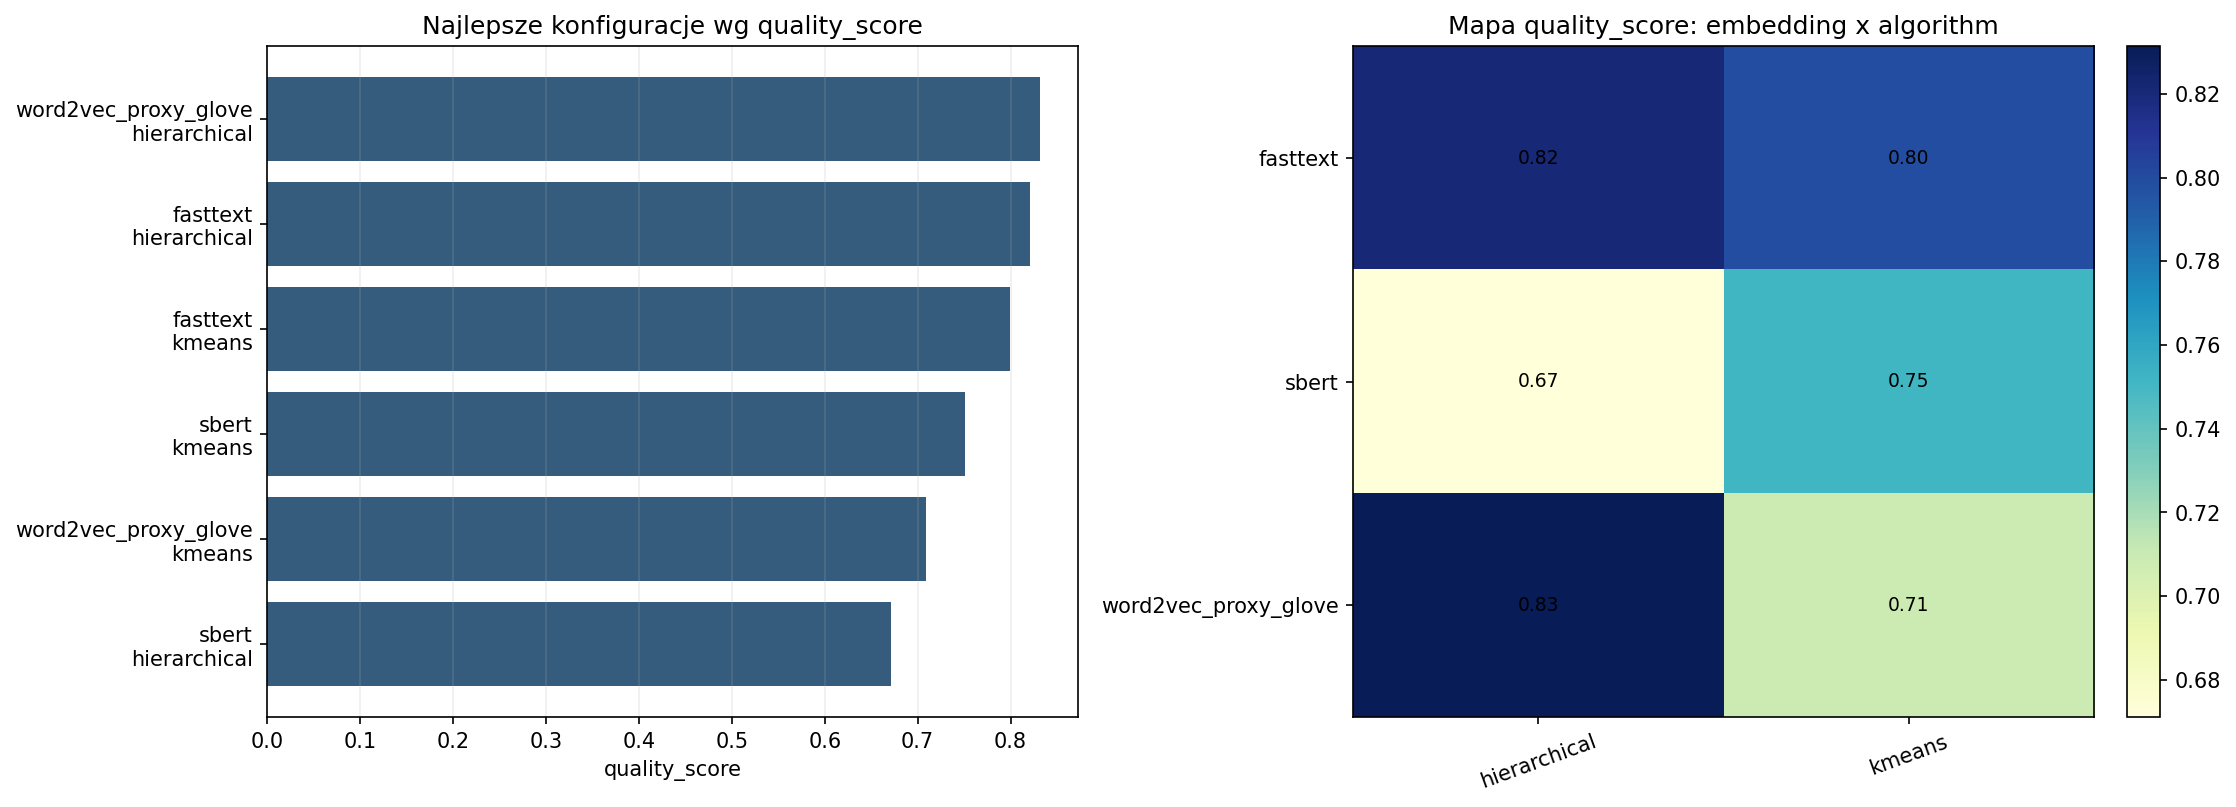

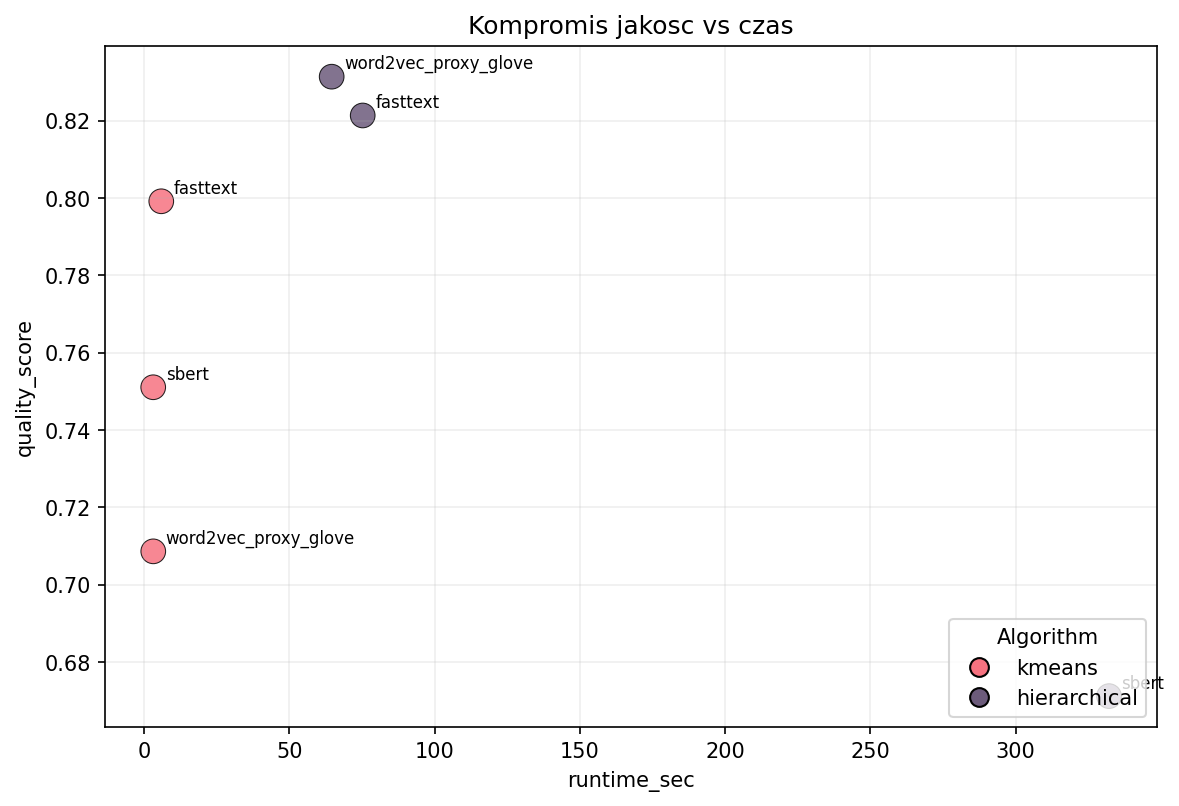


---
### Tabela 1: `global_ranking` — globalny ranking top-10

Zestawienie **10 najlepszych konfiguracji** spośród wszystkich przebadanych par embedding + algorytm,
posortowane malejąco po `quality_score`. Kolumna `rank` numeruje pozycje od 1 do 10.

> Użycie: szybki przegląd absolutnych liderów eksperymentu — które kombinacje embedding + algorytm
> dominują w łącznej ocenie wielu metryk naraz.


,rank,embedding_name,embedding_label,algorithm,k,metric,linkage,quality_score,silhouette,davies_bouldin,dunn,ari,runtime_sec,selection_summary
0,1,word2vec_proxy_glove,Static proxy (GloVe 300),hierarchical,15,cosine,average,0.831348,0.625997,1.249923,0.255618,-0.000013,64.536711,score=0.831; sil=0.626; db=1.250; dunn=0.256; ...
1,2,fasttext,fastText wiki-news 300,hierarchical,10,cosine,average,0.821316,0.685078,0.873007,0.124107,-0.000027,75.219153,score=0.821; sil=0.685; db=0.873; dunn=0.124; ...
2,3,fasttext,fastText wiki-news 300,kmeans,10,euclidean,None,0.799127,0.019440,3.325837,0.124677,0.112725,5.879428,score=0.799; sil=0.019; db=3.326; dunn=0.125; ...
3,4,sbert,SBERT MiniLM-L6-v2,kmeans,25,euclidean,None,0.751030,0.031996,4.184971,0.405127,0.373261,3.105463,score=0.751; sil=0.032; db=4.185; dunn=0.405; ...
4,5,word2vec_proxy_glove,Static proxy (GloVe 300),kmeans,10,euclidean,None,0.708595,0.039380,3.239658,0.123603,0.164431,3.124533,score=0.709; sil=0.039; db=3.240; dunn=0.124; ...
5,6,sbert,SBERT MiniLM-L6-v2,hierarchical,10,euclidean,ward,0.671155,0.023407,5.358825,0.434106,0.263657,332.111896,score=0.671; sil=0.023; db=5.359; dunn=0.434; ...



---
### Tabela 2: `pairwise_table` — najlepszy przebieg dla każdej pary embedding × algorytm

Dla każdej kombinacji `(embedding_name, algorithm)` wybrano **jeden najlepszy przebieg** (po `quality_score`).
Tabela zawiera wszystkie pary i jest posortowana malejąco — tj. para z najwyższym łącznym wynikiem jest na górze.

> Użycie: porównanie reprezentantów każdej pary, bez szumu ze strony gorszych konfiguracji
> hiperparametrów tego samego wariantu.


,embedding_name,embedding_label,algorithm,k,metric,linkage,quality_score,silhouette,davies_bouldin,dunn,ari,runtime_sec,selection_summary
0,word2vec_proxy_glove,Static proxy (GloVe 300),hierarchical,15,cosine,average,0.831348,0.625997,1.249923,0.255618,-0.000013,64.536711,score=0.831; sil=0.626; db=1.250; dunn=0.256; ...
1,fasttext,fastText wiki-news 300,hierarchical,10,cosine,average,0.821316,0.685078,0.873007,0.124107,-0.000027,75.219153,score=0.821; sil=0.685; db=0.873; dunn=0.124; ...
2,fasttext,fastText wiki-news 300,kmeans,10,euclidean,None,0.799127,0.019440,3.325837,0.124677,0.112725,5.879428,score=0.799; sil=0.019; db=3.326; dunn=0.125; ...
3,sbert,SBERT MiniLM-L6-v2,kmeans,25,euclidean,None,0.751030,0.031996,4.184971,0.405127,0.373261,3.105463,score=0.751; sil=0.032; db=4.185; dunn=0.405; ...
4,word2vec_proxy_glove,Static proxy (GloVe 300),kmeans,10,euclidean,None,0.708595,0.039380,3.239658,0.123603,0.164431,3.124533,score=0.709; sil=0.039; db=3.240; dunn=0.124; ...
5,sbert,SBERT MiniLM-L6-v2,hierarchical,10,euclidean,ward,0.671155,0.023407,5.358825,0.434106,0.263657,332.111896,score=0.671; sil=0.023; db=5.359; dunn=0.434; ...



---
### Tabela 3: `best_embedding_per_algorithm` — najlepszy embedding dla każdego algorytmu

Dla każdego algorytmu z osobna (K-Means, Hierarchical, ...) wybrano embedding,
który osiągnął **najwyższy `quality_score`** w tej parze.

> Użycie: odpowiada na pytanie *"Jaka reprezentacja tekstu najlepiej współpracuje z danym algorytmem?"*
> — np. czy SBERT zawsze wygrywa z GloVe, czy tylko dla wybranych metod klasteryzacji.


,embedding_name,embedding_label,algorithm,k,metric,linkage,quality_score,silhouette,davies_bouldin,dunn,ari,runtime_sec,selection_summary
0,word2vec_proxy_glove,Static proxy (GloVe 300),hierarchical,15,cosine,average,0.831348,0.625997,1.249923,0.255618,-0.000013,64.536711,score=0.831; sil=0.626; db=1.250; dunn=0.256; ...
1,fasttext,fastText wiki-news 300,kmeans,10,euclidean,None,0.799127,0.019440,3.325837,0.124677,0.112725,5.879428,score=0.799; sil=0.019; db=3.326; dunn=0.125; ...



---
### Tabela 4: `best_algorithm_per_embedding` — najlepszy algorytm dla każdego embeddingu

Dla każdego embeddingu z osobna (GloVe, fastText, SBERT, ...) wybrano algorytm,
który osiągnął **najwyższy `quality_score`** w tej parze.

> Użycie: odpowiada na pytanie *"Który algorytm klasteryzacji najlepiej pasuje do danej reprezentacji?"*
> — np. czy dla SBERT lepiej sprawdza się K-Means czy klasteryzacja hierarchiczna.


,embedding_name,embedding_label,algorithm,k,metric,linkage,quality_score,silhouette,davies_bouldin,dunn,ari,runtime_sec,selection_summary
0,fasttext,fastText wiki-news 300,hierarchical,10,cosine,average,0.821316,0.685078,0.873007,0.124107,-0.000027,75.219153,score=0.821; sil=0.685; db=0.873; dunn=0.124; ...
1,sbert,SBERT MiniLM-L6-v2,kmeans,25,euclidean,None,0.751030,0.031996,4.184971,0.405127,0.373261,3.105463,score=0.751; sil=0.032; db=4.185; dunn=0.405; ...
2,word2vec_proxy_glove,Static proxy (GloVe 300),hierarchical,15,cosine,average,0.831348,0.625997,1.249923,0.255618,-0.000013,64.536711,score=0.831; sil=0.626; db=1.250; dunn=0.256; ...


{'ranking_heatmap': 'artifacts_full/plots/section7_ranking_heatmap.png',
 'quality_runtime': 'artifacts_full/plots/section7_quality_runtime.png'}

In [16]:

from IPython.display import Markdown

best_runs_df = select_best_runs(results_df)
best_runs_df = add_dunn_scores(
    best_runs_df=best_runs_df,
    dataset_df=dataset_df,
    dataset_views=dataset_views,
    embedding_views=embedding_views,
    config=CONFIG,
)

comparison_views = build_comparison_views(best_runs_df)
plot_paths = create_best_runs_plots(best_runs_df, CONFIG)
print(summarize_best_runs(best_runs_df))
display_best_runs_plots(plot_paths)

display(Markdown("""
---
### Tabela 1: `global_ranking` — globalny ranking top-10

Zestawienie **10 najlepszych konfiguracji** spośród wszystkich przebadanych par embedding + algorytm,
posortowane malejąco po `quality_score`. Kolumna `rank` numeruje pozycje od 1 do 10.

> Użycie: szybki przegląd absolutnych liderów eksperymentu — które kombinacje embedding + algorytm
> dominują w łącznej ocenie wielu metryk naraz.
"""))
display(comparison_views["global_ranking"])

display(Markdown("""
---
### Tabela 2: `pairwise_table` — najlepszy przebieg dla każdej pary embedding × algorytm

Dla każdej kombinacji `(embedding_name, algorithm)` wybrano **jeden najlepszy przebieg** (po `quality_score`).
Tabela zawiera wszystkie pary i jest posortowana malejąco — tj. para z najwyższym łącznym wynikiem jest na górze.

> Użycie: porównanie reprezentantów każdej pary, bez szumu ze strony gorszych konfiguracji
> hiperparametrów tego samego wariantu.
"""))
display(comparison_views["pairwise_table"])

display(Markdown("""
---
### Tabela 3: `best_embedding_per_algorithm` — najlepszy embedding dla każdego algorytmu

Dla każdego algorytmu z osobna (K-Means, Hierarchical, ...) wybrano embedding,
który osiągnął **najwyższy `quality_score`** w tej parze.

> Użycie: odpowiada na pytanie *"Jaka reprezentacja tekstu najlepiej współpracuje z danym algorytmem?"*
> — np. czy SBERT zawsze wygrywa z GloVe, czy tylko dla wybranych metod klasteryzacji.
"""))
display(comparison_views["best_embedding_per_algorithm"])

display(Markdown("""
---
### Tabela 4: `best_algorithm_per_embedding` — najlepszy algorytm dla każdego embeddingu

Dla każdego embeddingu z osobna (GloVe, fastText, SBERT, ...) wybrano algorytm,
który osiągnął **najwyższy `quality_score`** w tej parze.

> Użycie: odpowiada na pytanie *"Który algorytm klasteryzacji najlepiej pasuje do danej reprezentacji?"*
> — np. czy dla SBERT lepiej sprawdza się K-Means czy klasteryzacja hierarchiczna.
"""))
display(comparison_views["best_algorithm_per_embedding"])
plot_paths


## 8. Czesc interpretacyjna klastrow

Sama metryka globalna nie wystarcza do zrozumienia, *co* model rzeczywiscie pogrupowal. Dlatego dla najlepszych przebiegow uruchamiamy interpretacje wielometodowa, laczaca sygnal leksykalny, geometryczny i etykietowy.

W tej sekcji stosujemy kilka uzupelniajacych sie metod:
1. **Opis leksykalny klastra**: najczestsze slowa (`top_frequent_words`) oraz slowa najbardziej odrozniajace klaster od reszty (`top_distinctive_words`).
2. **Diagnostyka etykiet rzeczywistych** (tylko do interpretacji post-hoc):
   - dominujaca etykieta (`dominant_target`),
   - udzial dominujacej etykiety (`dominant_target_share`),
   - entropia etykiet (`target_entropy`, im nizsza tym klaster bardziej jednorodny).
3. **Dokumenty prototypowe i graniczne**:
   - dokumenty najbardziej centralne w klastrze (latwe do opisania semantycznie),
   - dokumenty najbardziej odlegle od centrum klastra (pokazuja granice i potencjalne mieszanie tematow).
4. **Komentarz interpretacyjny**: automatycznie tworzony opis klastra oparty o powyzsze sygnaly, ulatwiajacy szybkie czytanie wynikow.

Taki uklad pozwala nie tylko wskazac najlepszy wynik liczbowy, ale tez wyjasnic, dlaczego dany klaster jest spojny (lub nie) i jak bardzo odpowiada naturalnym kategoriom `20 Newsgroups`.

In [17]:
def explain_best_runs(
    best_runs_df: pd.DataFrame,
    dataset_df: pd.DataFrame,
    dataset_views: Dict[str, np.ndarray],
    embedding_views: Dict[str, Dict[str, Any]],
    config: Dict[str, Any],
) -> Tuple[pd.DataFrame, List[Dict[str, Any]], pd.DataFrame]:
    profile_rows: List[Dict[str, Any]] = []
    cluster_examples: List[Dict[str, Any]] = []
    run_summary_rows: List[Dict[str, Any]] = []

    for _, row in best_runs_df.iterrows():
        subset_name = "kmeans" if row["algorithm"] == "kmeans" else "hierarchical"
        embedding_view = embedding_views[row["embedding_name"]]
        X, fit_df = select_embedding_subset(
            dataset_df=dataset_df,
            embedding_view=embedding_view,
            requested_doc_ids=dataset_views[subset_name],
        )
        params = params_from_row(row)
        model, labels = refit_model(X=X, params=params, seed=config["seed"])
        run_profiles, run_examples = interpret_single_run(
            fit_df=fit_df,
            X=X,
            labels=labels,
            model=model,
            row=row,
            top_terms=int(config["explain_top_terms"]),
            top_docs=int(config["explain_top_docs"]),
            max_features=int(config["interpretation_max_features"]),
        )
        profile_rows.extend(run_profiles)
        cluster_examples.extend(run_examples)

        run_summary_rows.extend(
            summarize_run_interpretation(
                run_profiles=run_profiles,
                run_row=row,
            )
        )

    profiles_df = pd.DataFrame(profile_rows)
    run_summary_df = pd.DataFrame(run_summary_rows)
    return profiles_df, cluster_examples, run_summary_df


def refit_model(
    X: np.ndarray, params: Dict[str, Any], seed: int
) -> Tuple[Any, np.ndarray]:
    if params["algorithm"] == "kmeans":
        model = KMeans(
            n_clusters=params["k"],
            n_init=params["n_init"],
            max_iter=params["max_iter"],
            random_state=seed,
        )
    else:
        model = AgglomerativeClustering(
            n_clusters=params["k"],
            metric=params["metric"],
            linkage=params["linkage"],
        )
    labels = model.fit_predict(X)
    return model, labels


def interpret_single_run(
    fit_df: pd.DataFrame,
    X: np.ndarray,
    labels: np.ndarray,
    model: Any,
    row: pd.Series,
    top_terms: int,
    top_docs: int,
    max_features: int,
) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]]]:
    texts = fit_df["analysis_text"].fillna("").replace("", "emptytoken").tolist()
    count_vectorizer = CountVectorizer(max_features=max_features)
    tfidf_vectorizer = TfidfVectorizer(max_features=max_features)
    count_matrix = count_vectorizer.fit_transform(texts)
    tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
    count_vocab = np.array(count_vectorizer.get_feature_names_out())
    tfidf_vocab = np.array(tfidf_vectorizer.get_feature_names_out())

    profiles: List[Dict[str, Any]] = []
    examples: List[Dict[str, Any]] = []

    for cluster_id in sorted(np.unique(labels)):
        cluster_mask = labels == cluster_id
        outside_mask = ~cluster_mask
        cluster_size = int(cluster_mask.sum())

        mean_counts = np.asarray(count_matrix[cluster_mask].mean(axis=0)).ravel()
        frequent_idx = np.argsort(mean_counts)[::-1][:top_terms]
        frequent_words = [word for word in count_vocab[frequent_idx] if mean_counts.any()]

        mean_tfidf_cluster = np.asarray(tfidf_matrix[cluster_mask].mean(axis=0)).ravel()
        if outside_mask.sum() > 0:
            mean_tfidf_outside = np.asarray(tfidf_matrix[outside_mask].mean(axis=0)).ravel()
        else:
            mean_tfidf_outside = np.zeros_like(mean_tfidf_cluster)
        distinctive_scores = mean_tfidf_cluster - mean_tfidf_outside
        distinctive_idx = np.argsort(distinctive_scores)[::-1][:top_terms]
        distinctive_words = [
            word for word in tfidf_vocab[distinctive_idx] if distinctive_scores.any()
        ]

        label_stats = compute_target_label_stats(
            target_names=fit_df.loc[cluster_mask, "target_name"].astype(str),
        )

        central_indices, boundary_indices = representative_doc_indices(
            X=X,
            labels=labels,
            cluster_id=int(cluster_id),
            model=model,
            algorithm=row["algorithm"],
            metric=row["metric"],
            top_docs=top_docs,
        )

        representative_docs = build_doc_records(
            fit_df=fit_df,
            local_indices=central_indices,
            role="central",
        )
        boundary_docs = build_doc_records(
            fit_df=fit_df,
            local_indices=boundary_indices,
            role="boundary",
        )

        interpretation_note = build_cluster_note(
            cluster_size=cluster_size,
            label_stats=label_stats,
            frequent_words=frequent_words,
            distinctive_words=distinctive_words,
        )

        profiles.append(
            {
                "embedding_name": row["embedding_name"],
                "algorithm": row["algorithm"],
                "k": int(row["k"]),
                "metric": row["metric"],
                "linkage": row["linkage"] if pd.notna(row["linkage"]) else None,
                "cluster_id": int(cluster_id),
                "cluster_size": cluster_size,
                "top_frequent_words": ", ".join(frequent_words),
                "top_distinctive_words": ", ".join(distinctive_words),
                "dominant_target": label_stats["dominant_target"],
                "dominant_target_share": label_stats["dominant_target_share"],
                "target_entropy": label_stats["target_entropy"],
                "top_targets": label_stats["top_targets"],
                "interpretation_note": interpretation_note,
            }
        )
        examples.append(
            {
                "embedding_name": row["embedding_name"],
                "algorithm": row["algorithm"],
                "k": int(row["k"]),
                "metric": row["metric"],
                "linkage": row["linkage"] if pd.notna(row["linkage"]) else None,
                "cluster_id": int(cluster_id),
                "central_documents": representative_docs,
                "boundary_documents": boundary_docs,
            }
        )

    return profiles, examples


def representative_doc_indices(
    X: np.ndarray,
    labels: np.ndarray,
    cluster_id: int,
    model: Any,
    algorithm: str,
    metric: str,
    top_docs: int,
) -> Tuple[List[int], List[int]]:
    cluster_indices = np.where(labels == cluster_id)[0]
    if len(cluster_indices) == 0:
        return [], []

    if algorithm == "kmeans":
        distances = model.transform(X[cluster_indices])[:, cluster_id]
        ordered = cluster_indices[np.argsort(distances)]
    else:
        cluster_vectors = X[cluster_indices]
        dist_matrix = pairwise_distances(cluster_vectors, metric=metric)
        centrality = dist_matrix.mean(axis=1)
        ordered = cluster_indices[np.argsort(centrality)]

    docs_per_role = min(top_docs, len(ordered) // 2)
    if docs_per_role == 0:
        return ordered[:1].tolist(), []

    central = ordered[:docs_per_role].tolist()
    boundary = ordered[-docs_per_role:][::-1].tolist()
    return central, boundary


def build_doc_records(
    fit_df: pd.DataFrame,
    local_indices: List[int],
    role: str,
) -> List[Dict[str, Any]]:
    records: List[Dict[str, Any]] = []
    for local_idx in local_indices:
        record = fit_df.iloc[local_idx]
        records.append(
            {
                "role": role,
                "doc_id": int(record["doc_id"]),
                "target_name": str(record["target_name"]),
                "excerpt": truncate_text(record["text_clean_basic"]),
            }
        )
    return records


def compute_target_label_stats(target_names: pd.Series) -> Dict[str, Any]:
    label_counts = target_names.value_counts()
    total = int(label_counts.sum())
    if total == 0:
        return {
            "dominant_target": "unknown",
            "dominant_target_share": float("nan"),
            "target_entropy": float("nan"),
            "top_targets": "",
        }

    probs = (label_counts / total).to_numpy(dtype=float)
    entropy = float(-(probs * np.log2(probs + 1e-12)).sum())

    dominant_target = str(label_counts.index[0])
    dominant_share = float(label_counts.iloc[0] / total)
    top_targets = ", ".join(
        [f"{name}:{count}" for name, count in label_counts.head(3).items()]
    )

    return {
        "dominant_target": dominant_target,
        "dominant_target_share": dominant_share,
        "target_entropy": entropy,
        "top_targets": top_targets,
    }


def build_cluster_note(
    cluster_size: int,
    label_stats: Dict[str, Any],
    frequent_words: List[str],
    distinctive_words: List[str],
) -> str:
    lexical_hint = ", ".join(distinctive_words[:4] if distinctive_words else frequent_words[:4])
    if not lexical_hint:
        lexical_hint = "brak wyraznych tokenow"

    purity = label_stats["dominant_target_share"]
    if pd.isna(purity):
        purity_desc = "nieznana spojność etykiet"
    elif purity >= 0.65:
        purity_desc = "wysoka zgodnosc etykiet"
    elif purity >= 0.45:
        purity_desc = "srednia zgodnosc etykiet"
    else:
        purity_desc = "niska zgodnosc etykiet"

    return (
        f"Klaster {cluster_size} docs; dominant='{label_stats['dominant_target']}' "
        f"({purity:.2f}) - {purity_desc}; sygnatura: {lexical_hint}."
    )


def summarize_run_interpretation(
    run_profiles: List[Dict[str, Any]],
    run_row: pd.Series,
) -> List[Dict[str, Any]]:
    if not run_profiles:
        return []

    run_df = pd.DataFrame(run_profiles)
    top_by_size = run_df.sort_values("cluster_size", ascending=False).head(3)
    purity_candidates = run_df[run_df["cluster_size"] > 1]
    if purity_candidates.empty:
        purity_candidates = run_df.iloc[0:0]
    top_by_purity = purity_candidates.sort_values(
        ["dominant_target_share", "cluster_size"],
        ascending=[False, False],
    ).head(3)

    summary = {
        "embedding_name": run_row["embedding_name"],
        "algorithm": run_row["algorithm"],
        "k": int(run_row["k"]),
        "best_clusters_by_size": "; ".join(
            [
                f"#{int(r.cluster_id)} size={int(r.cluster_size)} dom={r.dominant_target}({r.dominant_target_share:.2f})"
                for r in top_by_size.itertuples()
            ]
        ),
        "best_clusters_by_purity": "; ".join(
            [
                f"#{int(r.cluster_id)} size={int(r.cluster_size)} dom={r.dominant_target}({r.dominant_target_share:.2f})"
                for r in top_by_purity.itertuples()
            ]
        ) if not top_by_purity.empty else "Brak klastrow o rozmiarze > 1.",
        "mean_target_entropy": float(
            (run_df["target_entropy"] * run_df["cluster_size"]).sum()
            / run_df["cluster_size"].sum()
        ),
        "mean_target_entropy_unweighted": float(run_df["target_entropy"].mean()),
        "quality_score": float(run_row["quality_score"]) if "quality_score" in run_row.index else float("nan"),
    }
    return [summary]


def format_interpretation_markdown(
    run_summary_df: pd.DataFrame,
    cluster_profiles_df: pd.DataFrame,
    cluster_examples: List[Dict[str, Any]],
    top_runs: int = 3,
) -> str:
    if run_summary_df.empty:
        return "Brak danych do interpretacji."

    top_rows = (
        run_summary_df
        .sort_values(["quality_score", "mean_target_entropy"], ascending=[False, True])
        .head(top_runs)
        .reset_index(drop=True)
    )
    criteria_note = (
        f"Top {top_runs} przebiegów wybranych wg **`quality_score`** z sekcji 7 "
        f"(średnia ważona: silhouette×0.35 + dunn×0.30 + davies_bouldin×0.20 + ari×0.15, "
        f"normalizowana per para embedding+algorytm)."
    )

    lines: List[str] = [
        "## Raport interpretacyjny klastrow (best runs)",
        "",
        f"> **Kryteria wyboru:** {criteria_note}",
        "",
    ]

    for rank, row in enumerate(top_rows.itertuples(index=False), start=1):
        run_name = f"{row.embedding_name} + {row.algorithm} (k={int(row.k)})"
        lines.append(f"### {rank}. {run_name}")
        lines.append("")
        lines.append(
            f"**Wynik laczny:** quality_score={row.quality_score:.3f} | "
            f"entropia wazona={row.mean_target_entropy:.3f} | "
            f"entropia niewazona={row.mean_target_entropy_unweighted:.3f}"
        )
        lines.append("")
        lines.append(f"- Najwieksze klastry: {row.best_clusters_by_size}")
        lines.append(f"- Najczystsze klastry (rozmiar > 1): {row.best_clusters_by_purity}")
        lines.append("")

        run_profiles = (
            cluster_profiles_df[
                (cluster_profiles_df["embedding_name"] == row.embedding_name)
                & (cluster_profiles_df["algorithm"] == row.algorithm)
                & (cluster_profiles_df["k"] == int(row.k))
                & (cluster_profiles_df["cluster_size"] > 1)
            ]
            .sort_values(["dominant_target_share", "cluster_size"], ascending=[False, False])
            .head(3)
        )

        lines.append("**Top klastry wg czystosci etykiet (rozmiar > 1):**")
        lines.append("")
        if run_profiles.empty:
            lines.append("Brak klastrow o rozmiarze > 1 spelniajacych kryterium czystosci.")
        else:
            lines.append("| cluster_id | size | dominant_target | share | entropy |")
            lines.append("|---:|---:|---|---:|---:|")
            for profile in run_profiles.itertuples(index=False):
                lines.append(
                    f"| {int(profile.cluster_id)} | {int(profile.cluster_size)} | "
                    f"{profile.dominant_target} | {profile.dominant_target_share:.3f} | {profile.target_entropy:.3f} |"
                )
        lines.append("")

        selected_cluster_ids = [int(x) for x in run_profiles["cluster_id"].head(2).tolist()]
        related_examples = [
            item for item in cluster_examples
            if item["embedding_name"] == row.embedding_name
            and item["algorithm"] == row.algorithm
            and item["k"] == int(row.k)
            and int(item["cluster_id"]) in selected_cluster_ids
        ]
        related_examples = sorted(related_examples, key=lambda x: x["cluster_id"])

        lines.append("**Przykladowe dokumenty (centralne i graniczne):**")
        lines.append("")
        for example in related_examples:
            lines.append(f"- Cluster {example['cluster_id']}")
            lines.append("  - Centralne:")
            for doc in example["central_documents"][:2]:
                lines.append(
                    f"    - doc_id={doc['doc_id']} | target={doc['target_name']}\n"
                    f"      > {doc['excerpt']}"
                )
            lines.append("  - Graniczne:")
            for doc in example["boundary_documents"][:2]:
                lines.append(
                    f"    - doc_id={doc['doc_id']} | target={doc['target_name']}\n"
                    f"      > {doc['excerpt']}"
                )
        lines.append("")
        lines.append("---")
        lines.append("")

    return "\n".join(lines)


def build_examples_dataframe(
    run_summary_df: pd.DataFrame,
    cluster_profiles_df: pd.DataFrame,
    cluster_examples: List[Dict[str, Any]],
    top_runs: int = 3,
    clusters_per_run: int = 2,
    docs_per_role: int = 2,
) -> pd.DataFrame:
    if run_summary_df.empty:
        return pd.DataFrame()

    top_rows = (
        run_summary_df
        .sort_values(["quality_score", "mean_target_entropy"], ascending=[False, True])
        .head(top_runs)
        .reset_index(drop=True)
    )

    rows: List[Dict[str, Any]] = []
    for run_rank, row in enumerate(top_rows.itertuples(index=False), start=1):
        run_profiles = (
            cluster_profiles_df[
                (cluster_profiles_df["embedding_name"] == row.embedding_name)
                & (cluster_profiles_df["algorithm"] == row.algorithm)
                & (cluster_profiles_df["k"] == int(row.k))
                & (cluster_profiles_df["cluster_size"] > 1)
            ]
            .sort_values(["dominant_target_share", "cluster_size"], ascending=[False, False])
            .head(clusters_per_run)
        )
        selected_cluster_ids = {int(x) for x in run_profiles["cluster_id"].tolist()}

        related_examples = [
            item for item in cluster_examples
            if item["embedding_name"] == row.embedding_name
            and item["algorithm"] == row.algorithm
            and item["k"] == int(row.k)
            and int(item["cluster_id"]) in selected_cluster_ids
        ]

        for example in sorted(related_examples, key=lambda x: x["cluster_id"]):
            for role_key, role_label in [
                ("central_documents", "central"),
                ("boundary_documents", "boundary"),
            ]:
                for doc_rank, doc in enumerate(example[role_key][:docs_per_role], start=1):
                    rows.append(
                        {
                            "run_rank": run_rank,
                            "embedding": row.embedding_name,
                            "algorithm": row.algorithm,
                            "k": int(row.k),
                            "quality_score": float(row.quality_score),
                            "cluster_id": int(example["cluster_id"]),
                            "doc_role": role_label,
                            "doc_rank": doc_rank,
                            "doc_id": int(doc["doc_id"]),
                            "target_name": str(doc["target_name"]),
                            "excerpt": str(doc["excerpt"]),
                        }
                    )

    if not rows:
        return pd.DataFrame()

    examples_df = pd.DataFrame(rows)
    return examples_df.sort_values(
        ["run_rank", "cluster_id", "doc_role", "doc_rank"],
        ascending=[True, True, True, True],
    ).reset_index(drop=True)


def truncate_text(text: str, length: int = 260) -> str:
    clean = clean_text_basic(text)
    if len(clean) <= length:
        return clean
    return clean[: length - 3] + "..."


In [18]:

from IPython.display import Markdown, display

cluster_profiles_df, cluster_examples, interpretation_runs_df = explain_best_runs(
    best_runs_df=best_runs_df,
    dataset_df=dataset_df,
    dataset_views=dataset_views,
    embedding_views=embedding_views,
    config=CONFIG,
)

interpretation_md = format_interpretation_markdown(
    run_summary_df=interpretation_runs_df,
    cluster_profiles_df=cluster_profiles_df,
    cluster_examples=cluster_examples,
    top_runs=3,
)

interpretation_runs_view = (
    interpretation_runs_df
    .sort_values(["quality_score", "mean_target_entropy"], ascending=[False, True])
    .reset_index(drop=True)
)

cluster_profiles_view = (
    cluster_profiles_df
    .sort_values(["cluster_size", "dominant_target_share"], ascending=[False, False])
    .head(20)
    .reset_index(drop=True)
)

examples_view = build_examples_dataframe(
    run_summary_df=interpretation_runs_df,
    cluster_profiles_df=cluster_profiles_df,
    cluster_examples=cluster_examples,
    top_runs=3,
    clusters_per_run=2,
    docs_per_role=2,
)

display(Markdown("""
---
### Tabela A: `interpretation_runs_df` — ranking przebiegów do interpretacji

Jeden wiersz = jeden przebieg (embedding + algorytm). Ranking sortowany malejąco po `quality_score` i pomocniczo rosnąco po `mean_target_entropy`.

Kluczowe pola:
- `quality_score`: główne kryterium wyboru do raportu narracyjnego,
- `mean_target_entropy`: entropia ważona rozmiarami klastrów (niższa = lepiej),
- `mean_target_entropy_unweighted`: wersja nieważona (diagnostyka),
- `best_clusters_by_size` i `best_clusters_by_purity`: szybki skrót jakości klastrów.
"""))
with pd.option_context("display.max_colwidth", 140):
    display(interpretation_runs_view)

display(Markdown("""
---
### Tabela B: `cluster_profiles_df` — profile klastrów (top 20)

Największe klastry z adnotacjami semantycznymi i etykietowymi. Używaj tej tabeli, gdy chcesz sprawdzić "co" zawiera klaster i jak czysty jest tematycznie.
"""))
with pd.option_context("display.max_colwidth", 120):
    display(cluster_profiles_view)

display(Markdown("""
---
### Tabela C: dokumenty przykładowe (centralne vs graniczne)

Lepszy widok dokumentów do analizy jakości klastrów:
- `central`: dokumenty najbardziej typowe dla klastra,
- `boundary`: dokumenty najbardziej graniczne (potencjalnie mieszające tematy).

Dane obejmują top-3 przebiegi, top-2 klastry na przebieg i po 2 dokumenty na rolę.
"""))
with pd.option_context("display.max_colwidth", 180):
    display(examples_view)

display(Markdown("""
---
### Raport narracyjny: `interpretation_md`

Poniżej pełny raport tekstowy z podziałem na przebiegi, tabelą top klastrów i dokumentami przykładowymi.
"""))
display(Markdown(interpretation_md))



---
### Tabela A: `interpretation_runs_df` — ranking przebiegów do interpretacji

Jeden wiersz = jeden przebieg (embedding + algorytm). Ranking sortowany malejąco po `quality_score` i pomocniczo rosnąco po `mean_target_entropy`.

Kluczowe pola:
- `quality_score`: główne kryterium wyboru do raportu narracyjnego,
- `mean_target_entropy`: entropia ważona rozmiarami klastrów (niższa = lepiej),
- `mean_target_entropy_unweighted`: wersja nieważona (diagnostyka),
- `best_clusters_by_size` i `best_clusters_by_purity`: szybki skrót jakości klastrów.


,embedding_name,algorithm,k,best_clusters_by_size,best_clusters_by_purity,mean_target_entropy,mean_target_entropy_unweighted,quality_score
0,word2vec_proxy_glove,hierarchical,15,#10 size=17888 dom=soc.religion.christian(0.05); #0 size=72 dom=comp.os.ms-windows.misc(0.31); #3 size=4 dom=talk.politics.guns(0.50),#1 size=2 dom=rec.sport.baseball(1.00); #2 size=3 dom=comp.sys.mac.hardware(0.67); #3 size=4 dom=talk.politics.guns(0.50),4.306137,0.879500,0.831348
1,fasttext,hierarchical,10,#0 size=17823 dom=soc.religion.christian(0.05); #1 size=141 dom=comp.sys.mac.hardware(0.13); #3 size=10 dom=comp.os.ms-windows.misc(1.00),#3 size=10 dom=comp.os.ms-windows.misc(1.00); #4 size=2 dom=comp.graphics(0.50); #1 size=141 dom=comp.sys.mac.hardware(0.13),4.307183,0.928012,0.821316
2,fasttext,kmeans,10,#5 size=3105 dom=sci.crypt(0.14); #9 size=2967 dom=comp.windows.x(0.19); #6 size=2248 dom=rec.autos(0.21),#3 size=1270 dom=talk.politics.mideast(0.40); #8 size=1694 dom=soc.religion.christian(0.39); #1 size=1893 dom=rec.sport.hockey(0.32),3.437209,3.471728,0.799127
3,sbert,kmeans,25,#20 size=1224 dom=alt.atheism(0.12); #18 size=1078 dom=comp.sys.ibm.pc.hardware(0.34); #7 size=998 dom=comp.graphics(0.11),#16 size=846 dom=rec.sport.hockey(0.95); #2 size=798 dom=rec.sport.baseball(0.94); #6 size=620 dom=comp.windows.x(0.94),1.913362,1.756025,0.751030
4,word2vec_proxy_glove,kmeans,10,#5 size=3163 dom=comp.windows.x(0.18); #0 size=2664 dom=rec.motorcycles(0.13); #4 size=2422 dom=talk.politics.mideast(0.27),#6 size=781 dom=sci.med(0.75); #3 size=1475 dom=rec.sport.hockey(0.46); #1 size=1797 dom=soc.religion.christian(0.43),3.070887,3.003352,0.708595
5,sbert,hierarchical,10,#0 size=3303 dom=rec.autos(0.23); #3 size=2801 dom=talk.politics.guns(0.25); #4 size=2666 dom=sci.electronics(0.21),#8 size=656 dom=sci.med(0.96); #5 size=802 dom=talk.politics.mideast(0.80); #7 size=804 dom=sci.crypt(0.79),2.510157,2.083532,0.671155



---
### Tabela B: `cluster_profiles_df` — profile klastrów (top 20)

Największe klastry z adnotacjami semantycznymi i etykietowymi. Używaj tej tabeli, gdy chcesz sprawdzić "co" zawiera klaster i jak czysty jest tematycznie.


,embedding_name,algorithm,k,metric,linkage,cluster_id,cluster_size,top_frequent_words,top_distinctive_words,dominant_target,dominant_target_share,target_entropy,top_targets,interpretation_note
0,word2vec_proxy_glove,hierarchical,15,cosine,average,10,17888,"one, would, like, people, get, know, time, also, think, use","one, would, know, people, get, like, time, think, anyone, year",soc.religion.christian,0.053947,4.314013,"soc.religion.christian:965, comp.windows.x:951, comp.sys.ibm.pc.hardware:950","Klaster 17888 docs; dominant='soc.religion.christian' (0.05) - niska zgodnosc etykiet; sygnatura: one, would, know, ..."
1,fasttext,hierarchical,10,cosine,average,0,17823,"one, would, like, people, get, know, time, also, think, use","would, one, know, get, anyone, time, people, could, think, window",soc.religion.christian,0.054312,4.314120,"soc.religion.christian:968, comp.windows.x:950, sci.med:947","Klaster 17823 docs; dominant='soc.religion.christian' (0.05) - niska zgodnosc etykiet; sygnatura: would, one, know, ..."
2,sbert,hierarchical,10,euclidean,ward,0,3303,"one, would, car, space, like, get, time, also, know, year","car, bike, space, engine, mile, motorcycle, nasa, oil, gas, orbit",rec.autos,0.232516,3.234804,"rec.autos:768, rec.motorcycles:718, sci.space:697","Klaster 3303 docs; dominant='rec.autos' (0.23) - niska zgodnosc etykiet; sygnatura: car, bike, space, engine."
3,word2vec_proxy_glove,kmeans,10,euclidean,None,5,3163,"file, window, one, use, would, system, get, program, key, like","window, file, program, use, key, system, problem, using, do, chip",comp.windows.x,0.177363,3.142720,"comp.windows.x:561, comp.os.ms-windows.misc:495, comp.graphics:432","Klaster 3163 docs; dominant='comp.windows.x' (0.18) - niska zgodnosc etykiet; sygnatura: window, file, program, use."
4,fasttext,kmeans,10,euclidean,None,5,3105,"would, one, people, think, like, get, time, know, right, make","people, would, government, key, law, one, gun, think, right, thing",sci.crypt,0.144928,3.887459,"sci.crypt:450, sci.med:442, talk.politics.misc:314","Klaster 3105 docs; dominant='sci.crypt' (0.14) - niska zgodnosc etykiet; sygnatura: people, would, government, key."
5,fasttext,kmeans,10,euclidean,None,9,2967,"file, window, use, one, system, program, image, get, would, also","window, file, card, program, use, system, disk, software, using, image",comp.windows.x,0.185372,3.196449,"comp.windows.x:550, comp.graphics:445, comp.os.ms-windows.misc:442","Klaster 2967 docs; dominant='comp.windows.x' (0.19) - niska zgodnosc etykiet; sygnatura: window, file, card, program."
6,sbert,hierarchical,10,euclidean,ward,3,2801,"would, people, one, think, gun, right, know, like, time, say","gun, people, government, right, law, fbi, homosexual, koresh, batf, clinton",talk.politics.guns,0.245627,3.247416,"talk.politics.guns:688, talk.politics.misc:636, alt.atheism:297","Klaster 2801 docs; dominant='talk.politics.guns' (0.25) - niska zgodnosc etykiet; sygnatura: gun, people, government..."
7,sbert,hierarchical,10,euclidean,ward,4,2666,"one, edu, would, use, get, com, like, know, system, new","modem, printer, font, mail, port, please, sale, thanks, software, mouse",sci.electronics,0.211928,3.350691,"sci.electronics:565, misc.forsale:510, comp.os.ms-windows.misc:298","Klaster 2666 docs; dominant='sci.electronics' (0.21) - niska zgodnosc etykiet; sygnatura: modem, printer, font, mail."
8,word2vec_proxy_glove,kmeans,10,euclidean,None,0,2664,"would, one, know, like, get, people, think, time, say, thing","think, know, get, like, really, thing, people, say, going, guy",rec.motorcycles,0.125751,4.145192,"rec.motorcycles:335, talk.politics.guns:251, sci.space:186","Klaster 2664 docs; dominant='rec.motorcycles' (0.13) - niska zgodnosc etykiet; sygnatura: think, know, get, like."
9,word2vec_proxy_glove,kmeans,10,euclidean,None,4,2422,"would, people, one, government, right, armenian, state, time, think, year","government, people, israel, law, armenian, state, gun, arab, israeli, right"


---
### Tabela C: dokumenty przykładowe (centralne vs graniczne)

Lepszy widok dokumentów do analizy jakości klastrów:
- `central`: dokumenty najbardziej typowe dla klastra,
- `boundary`: dokumenty najbardziej graniczne (potencjalnie mieszające tematy).

Dane obejmują top-3 przebiegi, top-2 klastry na przebieg i po 2 dokumenty na rolę.


,run_rank,embedding,algorithm,k,quality_score,cluster_id,doc_role,doc_rank,doc_id,target_name,excerpt
0,1,word2vec_proxy_glove,hierarchical,15,0.831348,1,boundary,1,10920,rec.sport.baseball,BoSox 3 Royals 1 WP: Clemens (1-0) LP: Appier (0-1)
1,1,word2vec_proxy_glove,hierarchical,15,0.831348,1,central,1,9298,rec.sport.baseball,Overall (career) 1. Don Mattingly 2. Don Mattingly 3. Don Mattingly 4. Don Mattingly 5. Don Mattingly 6. Don Mattingly 7. Don Mattingly 8. Don Mattingly 9. Don Mattingly 10. Do...
2,1,word2vec_proxy_glove,hierarchical,15,0.831348,2,boundary,1,461,misc.forsale,For sale KFC SVGA Monitor 1024X768 .28DP Non-interlaced
3,1,word2vec_proxy_glove,hierarchical,15,0.831348,2,central,1,12062,comp.sys.mac.hardware,A SIMM is a small PCB with DRAM chips soldered on. --maarten
4,2,fasttext,hierarchical,10,0.821316,3,boundary,1,13292,comp.os.ms-windows.misc,"------------ Part 5 of 14 ------------ M)B9R&KJZ)EVZ=+ITNKH>?7U=PGU]+""Q=?72_=""PU'GT>+,<LORPU86$1EX,8 M,P$HWA=@8!SKWI_,S""B<)S<W-R>!5C<-S`HFNAIR<K)R<B9RMW)+D)#D""C!V M=KPYWA>\'.L7..."
5,2,fasttext,hierarchical,10,0.821316,3,boundary,2,11923,comp.os.ms-windows.misc,"------------ Part 10 of 14 ------------ M:J""U$$,^UM[>WE/M[>V+BXN+BXN+BXN+BXOM[>U34U-34[""PL!D9<7'2TM+2 M/3T]/3T]F9F9`P,#7EY>NRIZWT='I0MFQ#&'AX>'AX>'AX>'AX>'AX>'AX>' MAX>'AX>'AX>..."
6,2,fasttext,hierarchical,10,0.821316,3,central,1,9443,comp.os.ms-windows.misc,"------------ Part 8 of 14 ------------ MAX>'AX>'AX>'AX>'AYZ>8=#0T""L!A%(!*]#0T""4E)<-N;@+(U,C(;CZ;1-/3 MTXU*IH?4JH!75\B`P2&((F[JZ$/Q[/&J3;YJ+2WE<""3T*0:4E,SUAX>'AY\* MFYL^/J""@PR4E..."
7,2,fasttext,hierarchical,10,0.821316,3,central,2,2694,comp.os.ms-windows.misc,"MAX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>' MAX>'AX>'AX>'AX>',3'$9F8+""Z5'1]_?W]_?WWIZ>BHJ*BHJ*BHJ*BHJ*GIZ M>GIZ>GIZ*BHJ*GIZ>M_?1T>EI0L+""V9F9F9FR,A_?W_(5Z(46Q0..."
8,2,fasttext,hierarchical,10,0.821316,4,boundary,1,16269,comp.windows.x,I am using X11R5patch23 with the R5-SUNOS5 patch posted on export. I did optionally apply the patch.olit. libXmu compiles fine .. when I try to use it with clients (i.e. bmtoa ...
9,2,fasttext,hierarchical,10,0.821316,4,central,1,1159,comp.graphics,Why don't you consider PHIGS in X or PEX lib?



---
### Raport narracyjny: `interpretation_md`

Poniżej pełny raport tekstowy z podziałem na przebiegi, tabelą top klastrów i dokumentami przykładowymi.


## Raport interpretacyjny klastrow (best runs)

> **Kryteria wyboru:** Top 3 przebiegów wybranych wg **`quality_score`** z sekcji 7 (średnia ważona: silhouette×0.35 + dunn×0.30 + davies_bouldin×0.20 + ari×0.15, normalizowana per para embedding+algorytm).

### 1. word2vec_proxy_glove + hierarchical (k=15)

**Wynik laczny:** quality_score=0.831 | entropia wazona=4.306 | entropia niewazona=0.879

- Najwieksze klastry: #10 size=17888 dom=soc.religion.christian(0.05); #0 size=72 dom=comp.os.ms-windows.misc(0.31); #3 size=4 dom=talk.politics.guns(0.50)
- Najczystsze klastry (rozmiar > 1): #1 size=2 dom=rec.sport.baseball(1.00); #2 size=3 dom=comp.sys.mac.hardware(0.67); #3 size=4 dom=talk.politics.guns(0.50)

**Top klastry wg czystosci etykiet (rozmiar > 1):**

| cluster_id | size | dominant_target | share | entropy |
|---:|---:|---|---:|---:|
| 1 | 2 | rec.sport.baseball | 1.000 | -0.000 |
| 2 | 3 | comp.sys.mac.hardware | 0.667 | 0.918 |
| 3 | 4 | talk.politics.guns | 0.500 | 1.500 |

**Przykladowe dokumenty (centralne i graniczne):**

- Cluster 1
  - Centralne:
    - doc_id=9298 | target=rec.sport.baseball
      > Overall (career) 1. Don Mattingly 2. Don Mattingly 3. Don Mattingly 4. Don Mattingly 5. Don Mattingly 6. Don Mattingly 7. Don Mattingly 8. Don Mattingly 9. Don Mattingly 10. Don Mattingly 11. Don Mattingly . . . . . . . . 50. Don Mattingly
  - Graniczne:
    - doc_id=10920 | target=rec.sport.baseball
      > BoSox 3 Royals 1 WP: Clemens (1-0) LP: Appier (0-1)
- Cluster 2
  - Centralne:
    - doc_id=12062 | target=comp.sys.mac.hardware
      > A SIMM is a small PCB with DRAM chips soldered on. --maarten
  - Graniczne:
    - doc_id=461 | target=misc.forsale
      > For sale KFC SVGA Monitor 1024X768 .28DP Non-interlaced

---

### 2. fasttext + hierarchical (k=10)

**Wynik laczny:** quality_score=0.821 | entropia wazona=4.307 | entropia niewazona=0.928

- Najwieksze klastry: #0 size=17823 dom=soc.religion.christian(0.05); #1 size=141 dom=comp.sys.mac.hardware(0.13); #3 size=10 dom=comp.os.ms-windows.misc(1.00)
- Najczystsze klastry (rozmiar > 1): #3 size=10 dom=comp.os.ms-windows.misc(1.00); #4 size=2 dom=comp.graphics(0.50); #1 size=141 dom=comp.sys.mac.hardware(0.13)

**Top klastry wg czystosci etykiet (rozmiar > 1):**

| cluster_id | size | dominant_target | share | entropy |
|---:|---:|---|---:|---:|
| 3 | 10 | comp.os.ms-windows.misc | 1.000 | -0.000 |
| 4 | 2 | comp.graphics | 0.500 | 1.000 |
| 1 | 141 | comp.sys.mac.hardware | 0.128 | 3.966 |

**Przykladowe dokumenty (centralne i graniczne):**

- Cluster 3
  - Centralne:
    - doc_id=9443 | target=comp.os.ms-windows.misc
      > ------------ Part 8 of 14 ------------ MAX>'AX>'AX>'AX>'AYZ>8=#0T"L!A%(!*]#0T"4E)<-N;@+(U,C(;CZ;1-/3 MTXU*IH?4JH!75\B`P2&((F[JZ$/Q[/&J3;YJ+2WE<"3T*0:4E,SUAX>'AY\* MFYL^/J"@PR4E)=#0T"4E2VY+)1$1D&[4U-34U-34AX>'AX>'AX>'AX>'AX>' MAX>'AX>'AX>'AX>'AX>'AX>'AX<Y824...
    - doc_id=2694 | target=comp.os.ms-windows.misc
      > MAX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>' MAX>'AX>'AX>'AX>',3'$9F8+"Z5'1]_?W]_?WWIZ>BHJ*BHJ*BHJ*BHJ*GIZ M>GIZ>GIZ*BHJ*GIZ>M_?1T>EI0L+"V9F9F9FR,A_?W_(5Z(46Q04%%=75VO4 MU-34U-34U`("`@("`@("`M34?W]_?]#084O#%%O`.#AUG@&$`0$Y.?518)0& MC#`P8V-5...
  - Graniczne:
    - doc_id=13292 | target=comp.os.ms-windows.misc
      > ------------ Part 5 of 14 ------------ M)B9R&KJZ)EVZ=+ITNKH>?7U=PGU]+"Q=?72_="PU'GT>+,<LORPU86$1EX,8 M,P$HWA=@8!SKWI_,S"B<)S<W-R>!5C<-S`HFNAIR<K)R<B9RMW)+D)#D"C!V M=KPYWA>\'.L74?4<JPW,5EQEFYJLKHBQ?K5^(7*ZLK*Z)KH:NKJZ)G0FNKI= M)K)=)KHFNGU=NK*RLB9TLKIT)L)=PK)...
    - doc_id=11923 | target=comp.os.ms-windows.misc
      > ------------ Part 10 of 14 ------------ M:J"U$$,^UM[>WE/M[>V+BXN+BXN+BXN+BXOM[>U34U-34["PL!D9<7'2TM+2 M/3T]/3T]F9F9`P,#7EY>NRIZWT='I0MFQ#&'AX>'AX>'AX>'AX>'AX>'AX>' MAX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>' MAX>'AX>'AX>'AX>'AX>'AX>'AX>'AX...
- Cluster 4
  - Centralne:
    - doc_id=1159 | target=comp.graphics
      > Why don't you consider PHIGS in X or PEX lib?
  - Graniczne:
    - doc_id=16269 | target=comp.windows.x
      > I am using X11R5patch23 with the R5-SUNOS5 patch posted on export. I did optionally apply the patch.olit. libXmu compiles fine .. when I try to use it with clients (i.e. bmtoa and twm), I get errors ... I can not figure out what is wrong: gcc -fpcc-struct-r...

---

### 3. fasttext + kmeans (k=10)

**Wynik laczny:** quality_score=0.799 | entropia wazona=3.437 | entropia niewazona=3.472

- Najwieksze klastry: #5 size=3105 dom=sci.crypt(0.14); #9 size=2967 dom=comp.windows.x(0.19); #6 size=2248 dom=rec.autos(0.21)
- Najczystsze klastry (rozmiar > 1): #3 size=1270 dom=talk.politics.mideast(0.40); #8 size=1694 dom=soc.religion.christian(0.39); #1 size=1893 dom=rec.sport.hockey(0.32)

**Top klastry wg czystosci etykiet (rozmiar > 1):**

| cluster_id | size | dominant_target | share | entropy |
|---:|---:|---|---:|---:|
| 3 | 1270 | talk.politics.mideast | 0.401 | 2.992 |
| 8 | 1694 | soc.religion.christian | 0.387 | 2.709 |
| 1 | 1893 | rec.sport.hockey | 0.316 | 2.994 |

**Przykladowe dokumenty (centralne i graniczne):**

- Cluster 3
  - Centralne:
    - doc_id=15111 | target=talk.politics.misc
      > From: New Liberation News Service <nlns> Subject: NLNS: Fascism with a Friendly Face /* Written 8:33 pm Apr 14, 1993 by nlns@igc.apc.org in igc:nlns.news */ /* ---------- "NLNS Packet 3.11 *** 4-14-93" ---------- */ Fascism with a Friendly Face: Does Rush L...
    - doc_id=13892 | target=talk.politics.guns
      > Posted for L. Neil Smith by Cathy Smith THE LIES OF TEXAS Okay, what have we learned? For reasons still being kept secret, a federal agency already known -- well enough to be examined and rebuked by several legislative committees over the years -- for a lon...
  - Graniczne:
    - doc_id=12733 | target=talk.politics.mideast
      > massacre. Answer: a(1-1/2-1/4-1/11)=280 -> a = 1760
    - doc_id=14918 | target=talk.religion.misc
      > ONLY if you weight Americans equal to SAlvadorans.
- Cluster 8
  - Centralne:
    - doc_id=11064 | target=soc.religion.christian
      > There are exactly ZERO verses that "clearly" address the issues. The kind of interpretation I see as "incredibly perverse" is that applied to the story of Sodom as if it were a blanket equation of homosexual behavior and rape. Since Christians citing the Bi...
    - doc_id=14336 | target=talk.religion.misc
      > Brian Kendig first states: I ask: Brian Kendig states: Make up your mind. And we do not end perfect either. We are never perfect. Can you name one person, young or old, past or present, that you deem perfect? Good luck. Then you lie to yourself. You do not ...
  - Graniczne:
    - doc_id=2860 | target=talk.politics.misc
      > He's 1/2 liar, 1/2 cheat and 1/2 demagogue.
    - doc_id=18402 | target=rec.autos
      > *>>>>>>>>>>>>>>>>>>>> Is this a joke ? *>>>>>>>>>>>>>>>>>>>>>>>> -- ___________________________________________________________________

---


## 9. Artefakty, wykresy i MLflow

Wyniki eksperymentow sa zapisywane jako tabele `CSV`, pliki `JSON`, wykresy oraz lokalne przebiegi `MLflow`. Dzieki temu notebook pelni jednoczesnie role raportu i dokumentacji wykonanych eksperymentow.

In [19]:
def save_project_artifacts(
    results_df: pd.DataFrame,
    best_runs_df: pd.DataFrame,
    cluster_profiles_df: pd.DataFrame,
    cluster_examples: List[Dict[str, Any]],
    config: Dict[str, Any],
) -> Dict[str, str]:
    artifact_dir = Path(config["artifact_dir"])
    tables_dir = artifact_dir / "tables"

    results_path = tables_dir / "results_summary.csv"
    best_path = tables_dir / "best_runs.json"
    profiles_path = tables_dir / "cluster_profiles.csv"
    examples_path = tables_dir / "cluster_examples.json"

    results_df.to_csv(results_path, index=False)
    cluster_profiles_df.to_csv(profiles_path, index=False)
    best_path.write_text(
        json.dumps(best_runs_df.to_dict(orient="records"), ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    examples_path.write_text(
        json.dumps(cluster_examples, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    return {
        "results_summary": str(results_path),
        "best_runs": str(best_path),
        "cluster_profiles": str(profiles_path),
        "cluster_examples": str(examples_path),
    }


def format_parameter_label(row: pd.Series) -> str:
    algorithm = str(row.get("algorithm", ""))
    if algorithm == "dbscan":
        eps = row.get("eps", np.nan)
        min_samples = row.get("min_samples", np.nan)
        eps_label = "?" if pd.isna(eps) else f"{float(eps):g}"
        min_samples_label = "?" if pd.isna(min_samples) else str(int(min_samples))
        return f"eps={eps_label}, min_samples={min_samples_label}"

    k = row.get("k", np.nan)
    if pd.isna(k) or int(k) < 0:
        return "k=na"

    label_parts = [f"k={int(k)}"]
    if algorithm == "spectral" and "n_neighbors" in row.index and not pd.isna(row.get("n_neighbors")):
        label_parts.append(f"n_neighbors={int(row['n_neighbors'])}")
    return ", ".join(label_parts)


def format_compact_run_label(row: pd.Series) -> str:
    return f"{row['embedding_name']} + {row['algorithm']}\n{format_parameter_label(row)}"


def generate_summary_plots(
    results_df: pd.DataFrame,
    best_runs_df: pd.DataFrame,
    artifact_dir: Path,
) -> Dict[str, str]:
    plots_dir = artifact_dir / "plots"
    plots_dir.mkdir(parents=True, exist_ok=True)

    silhouette_path = plots_dir / "best_silhouette_by_model.png"
    ari_path = plots_dir / "best_ari_by_model.png"
    davies_bouldin_path = plots_dir / "best_davies_bouldin_by_model.png"
    dunn_path = plots_dir / "best_dunn_by_model.png"
    quality_path = plots_dir / "best_quality_score_by_model.png"
    tradeoff_path = plots_dir / "section10_silhouette_ari_tradeoff.png"
    efficiency_path = plots_dir / "section10_quality_runtime_efficiency.png"
    k_sensitivity_path = plots_dir / "section10_k_sensitivity.png"
    metric_profile_path = plots_dir / "section10_metric_profile_heatmap.png"

    make_metric_barplot(
        best_runs_df=best_runs_df,
        metric="silhouette",
        title="Best silhouette by embedding and algorithm",
        output_path=silhouette_path,
    )
    make_metric_barplot(
        best_runs_df=best_runs_df,
        metric="ari",
        title="Best ARI by embedding and algorithm",
        output_path=ari_path,
    )
    make_metric_barplot(
        best_runs_df=best_runs_df,
        metric="davies_bouldin",
        title="Best Davies-Bouldin by embedding and algorithm (lower is better)",
        output_path=davies_bouldin_path,
    )
    make_metric_barplot(
        best_runs_df=best_runs_df,
        metric="dunn",
        title="Best Dunn index by embedding and algorithm",
        output_path=dunn_path,
    )
    make_metric_barplot(
        best_runs_df=best_runs_df,
        metric="quality_score",
        title="Composite quality_score by embedding and algorithm",
        output_path=quality_path,
    )
    make_metric_tradeoff_plot(
        best_runs_df=best_runs_df,
        output_path=tradeoff_path,
    )
    make_runtime_efficiency_plot(
        best_runs_df=best_runs_df,
        output_path=efficiency_path,
    )
    make_k_sensitivity_plot(
        results_df=results_df,
        output_path=k_sensitivity_path,
    )
    make_metric_profile_heatmap(
        best_runs_df=best_runs_df,
        output_path=metric_profile_path,
    )

    return {
        "best_silhouette_plot": str(silhouette_path),
        "best_ari_plot": str(ari_path),
        "best_davies_bouldin_plot": str(davies_bouldin_path),
        "best_dunn_plot": str(dunn_path),
        "best_quality_score_plot": str(quality_path),
        "section10_tradeoff_plot": str(tradeoff_path),
        "section10_efficiency_plot": str(efficiency_path),
        "section10_k_sensitivity_plot": str(k_sensitivity_path),
        "section10_metric_profile_plot": str(metric_profile_path),
    }


def make_metric_barplot(
    best_runs_df: pd.DataFrame,
    metric: str,
    title: str,
    output_path: Path,
) -> None:
    plot_df = best_runs_df.copy()
    plot_df["label"] = plot_df.apply(format_compact_run_label, axis=1)

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(plot_df["label"], plot_df[metric], color="#355C7D")
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.set_xlabel("embedding + algorithm")
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.2)
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def make_metric_tradeoff_plot(best_runs_df: pd.DataFrame, output_path: Path) -> None:
    plot_df = best_runs_df.copy()
    if plot_df.empty:
        return

    embeddings = sorted(plot_df["embedding_name"].unique())
    colors = dict(zip(embeddings, plt.cm.Set2(np.linspace(0, 1, len(embeddings)))))
    markers = {"kmeans": "o", "hierarchical": "s", "dbscan": "^", "spectral": "D"}

    fig, ax = plt.subplots(figsize=(9.5, 6.2))
    for _, row in plot_df.iterrows():
        size = 220 + 520 * max(float(row.get("quality_score", 0.0)), 0.0)
        ax.scatter(
            row["silhouette"],
            row["ari"],
            s=size,
            color=colors[row["embedding_name"]],
            marker=markers.get(row["algorithm"], "o"),
            edgecolor="#1f2933",
            linewidth=0.8,
            alpha=0.82,
        )
        ax.annotate(
            format_compact_run_label(row),
            (row["silhouette"], row["ari"]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=8,
        )

    ax.axhline(0, color="#8a8f98", linewidth=0.8, linestyle="--", alpha=0.7)
    ax.set_title("Trade-off: separacja geometryczna vs zgodnosc z etykietami")
    ax.set_xlabel("silhouette (wyzej = lepiej)")
    ax.set_ylabel("ARI wzgledem kategorii 20 Newsgroups (wyzej = lepiej)")
    ax.grid(alpha=0.22)
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def make_runtime_efficiency_plot(best_runs_df: pd.DataFrame, output_path: Path) -> None:
    plot_df = best_runs_df.copy()
    if plot_df.empty or "quality_score" not in plot_df.columns:
        return

    fig, ax = plt.subplots(figsize=(9.5, 5.8))
    for algorithm, group in plot_df.groupby("algorithm"):
        ax.scatter(
            group["runtime_sec"],
            group["quality_score"],
            s=160,
            alpha=0.82,
            label=algorithm,
        )
        for _, row in group.iterrows():
            ax.annotate(
                f"{row['embedding_name']}\n{format_parameter_label(row)}",
                (row["runtime_sec"], row["quality_score"]),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8,
            )

    ax.set_xscale("log")
    ax.set_title("Efektywnosc: quality_score wzgledem czasu wykonania")
    ax.set_xlabel("runtime_sec (skala log, nizej = szybciej)")
    ax.set_ylabel("quality_score (wyzej = lepiej)")
    ax.grid(alpha=0.22)
    ax.legend(title="algorithm")
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def make_k_sensitivity_plot(results_df: pd.DataFrame, output_path: Path) -> None:
    metric_specs = [
        ("silhouette", "max", "Silhouette (wyzej = lepiej)"),
        ("ari", "max", "ARI (wyzej = lepiej)"),
        ("dunn", "max", "Dunn (wyzej = lepiej)"),
        ("davies_bouldin", "min", "Davies-Bouldin (nizej = lepiej)"),
    ]
    required = {"embedding_name", "algorithm", "k"} | {metric for metric, _, _ in metric_specs}
    if results_df.empty or not required.issubset(results_df.columns):
        return

    metric_columns = [metric for metric, _, _ in metric_specs]
    plot_df = results_df.dropna(subset=["k", *metric_columns]).copy()
    plot_df = plot_df[plot_df["k"] >= 0]
    if plot_df.empty:
        return
    plot_df["run_family"] = plot_df["embedding_name"] + " + " + plot_df["algorithm"]
    agg_spec = {
        metric: (metric, agg_func)
        for metric, agg_func, _ in metric_specs
    }
    summary = (
        plot_df.groupby(["run_family", "k"], as_index=False)
        .agg(**agg_spec)
        .sort_values("k")
    )

    fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
    axes_flat = axes.ravel()
    for ax, (metric, _, title) in zip(axes_flat, metric_specs):
        for run_family, group in summary.groupby("run_family"):
            ax.plot(group["k"], group[metric], marker="o", linewidth=1.6, label=run_family)
        ax.set_title(f"Wrazliwosc {title} na liczbe klastrow")
        ax.set_ylabel(metric)
        ax.axvline(20, color="#8a8f98", linewidth=0.9, linestyle="--", alpha=0.7)
        ax.set_xlabel("k")
        ax.grid(alpha=0.22)
    axes_flat[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def normalize_metric(series: pd.Series, higher_is_better: bool = True) -> pd.Series:
    values = series.astype(float)
    min_value = values.min()
    max_value = values.max()
    if pd.isna(min_value) or pd.isna(max_value) or np.isclose(max_value, min_value):
        return pd.Series(0.5, index=series.index)
    normalized = (values - min_value) / (max_value - min_value)
    return normalized if higher_is_better else 1 - normalized


def make_metric_profile_heatmap(best_runs_df: pd.DataFrame, output_path: Path) -> None:
    metric_specs = [
        ("silhouette", True, "silhouette"),
        ("ari", True, "ARI"),
        ("dunn", True, "Dunn"),
        ("davies_bouldin", False, "Davies-Bouldin inv."),
        ("quality_score", True, "quality_score"),
        ("runtime_sec", False, "runtime inv."),
    ]
    required = {metric for metric, _, _ in metric_specs}
    if best_runs_df.empty or not required.issubset(best_runs_df.columns):
        return

    plot_df = best_runs_df.copy().reset_index(drop=True)
    labels = plot_df.apply(
        format_compact_run_label,
        axis=1,
    )
    heatmap_values = pd.DataFrame(
        {
            label: normalize_metric(plot_df[metric], higher_is_better=higher_is_better)
            for metric, higher_is_better, label in metric_specs
        }
    )

    fig_height = max(4.8, 0.48 * len(plot_df) + 1.8)
    fig, ax = plt.subplots(figsize=(10.5, fig_height))
    image = ax.imshow(heatmap_values.to_numpy(), aspect="auto", cmap="YlGnBu", vmin=0, vmax=1)
    ax.set_title("Profil metryk dla best-runs (0 = slabszy, 1 = lepszy w danej metryce)")
    ax.set_xticks(np.arange(len(heatmap_values.columns)))
    ax.set_xticklabels(heatmap_values.columns, rotation=25, ha="right")
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels)
    for i in range(heatmap_values.shape[0]):
        for j in range(heatmap_values.shape[1]):
            value = heatmap_values.iat[i, j]
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8, color="#102030")
    fig.colorbar(image, ax=ax, fraction=0.025, pad=0.02)
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def log_summary_run(
    results_df: pd.DataFrame,
    best_runs_df: pd.DataFrame,
    cluster_profiles_df: pd.DataFrame,
    artifact_paths: Dict[str, str],
    config: Dict[str, Any],
) -> None:
    with mlflow.start_run(run_name=f"{config['mode']}_summary", nested=False):
        mlflow.set_tags(
            {
                "mode": config["mode"],
                "kind": "summary",
            }
        )
        mlflow.log_metrics(
            {
                "n_total_runs": float(len(results_df)),
                "n_best_runs": float(len(best_runs_df)),
                "n_profile_rows": float(len(cluster_profiles_df)),
                "best_silhouette_max": float(best_runs_df["silhouette"].max()),
                "best_ari_max": float(best_runs_df["ari"].max()),
            }
        )
        for path in artifact_paths.values():
            mlflow.log_artifact(path)


def format_run_label(row: pd.Series) -> str:
    return f"{row['embedding_name']} + {row['algorithm']} (k={int(row['k'])})"


def build_section10_views(
    best_runs_df: pd.DataFrame,
    interpretation_runs_df: pd.DataFrame,
    cluster_profiles_df: pd.DataFrame,
) -> Dict[str, pd.DataFrame]:
    empty = pd.DataFrame()
    if best_runs_df.empty:
        return {
            "leaderboard": empty,
            "embedding_summary": empty,
            "algorithm_summary": empty,
            "k_summary": empty,
            "purity_summary": empty,
        }

    best_runs_for_display = best_runs_df.copy()
    best_runs_for_display["parameter_label"] = best_runs_for_display.apply(
        format_parameter_label,
        axis=1,
    )

    leaderboard_columns = [
        "embedding_name", "algorithm", "parameter_label", "k", "silhouette", "davies_bouldin",
        "dunn", "ari", "quality_score", "runtime_sec",
    ]
    optional_parameter_columns = [
        column for column in ["eps", "min_samples", "n_neighbors"]
        if column in best_runs_for_display.columns
    ]
    leaderboard = (
        best_runs_for_display[leaderboard_columns + optional_parameter_columns]
        .sort_values(["quality_score", "ari", "silhouette"], ascending=[False, False, False])
        .reset_index(drop=True)
    )

    embedding_summary = (
        best_runs_df.groupby(["embedding_name", "embedding_label", "embedding_family"], as_index=False)
        .agg(
            n_selected_runs=("embedding_name", "size"),
            best_quality_score=("quality_score", "max"),
            mean_quality_score=("quality_score", "mean"),
            best_silhouette=("silhouette", "max"),
            best_ari=("ari", "max"),
            fastest_runtime_sec=("runtime_sec", "min"),
        )
        .sort_values(["best_quality_score", "best_ari"], ascending=[False, False])
        .reset_index(drop=True)
    )

    algorithm_summary = (
        best_runs_df.groupby("algorithm", as_index=False)
        .agg(
            n_selected_runs=("algorithm", "size"),
            best_quality_score=("quality_score", "max"),
            mean_quality_score=("quality_score", "mean"),
            mean_silhouette=("silhouette", "mean"),
            mean_ari=("ari", "mean"),
            mean_runtime_sec=("runtime_sec", "mean"),
        )
        .sort_values(["best_quality_score", "mean_quality_score"], ascending=[False, False])
        .reset_index(drop=True)
    )

    k_runs_df = best_runs_df[best_runs_df["k"] >= 0].copy()
    if k_runs_df.empty:
        k_summary = empty
    else:
        k_summary = (
        k_runs_df.groupby("k", as_index=False)
        .agg(
            n_selected_runs=("k", "size"),
            best_quality_score=("quality_score", "max"),
            mean_quality_score=("quality_score", "mean"),
            mean_silhouette=("silhouette", "mean"),
            mean_ari=("ari", "mean"),
        )
        .assign(distance_to_expected=lambda df: (df["k"] - 20).abs())
        .sort_values(["best_quality_score", "mean_quality_score"], ascending=[False, False])
        .reset_index(drop=True)
        )

    purity_runs = interpretation_runs_df[[
        "embedding_name", "algorithm", "k", "mean_target_entropy", "mean_target_entropy_unweighted",
    ]].copy()

    purity_clusters = cluster_profiles_df[cluster_profiles_df["cluster_size"] > 1].copy()
    if purity_clusters.empty:
        purity_summary = empty
    else:
        purity_summary = (
            purity_clusters.assign(
                high_purity=lambda df: df["dominant_target_share"] >= 0.60,
                very_high_purity=lambda df: df["dominant_target_share"] >= 0.80,
            )
            .groupby(["embedding_name", "algorithm", "k"], as_index=False)
            .agg(
                n_clusters=("cluster_id", "size"),
                mean_cluster_size=("cluster_size", "mean"),
                mean_dominant_target_share=("dominant_target_share", "mean"),
                high_purity_clusters=("high_purity", "sum"),
                very_high_purity_clusters=("very_high_purity", "sum"),
            )
            .merge(
                purity_runs,
                on=["embedding_name", "algorithm", "k"],
                how="left",
            )
            .sort_values(
                ["mean_dominant_target_share", "high_purity_clusters", "mean_target_entropy"],
                ascending=[False, False, True],
            )
            .reset_index(drop=True)
        )

    return {
        "leaderboard": leaderboard,
        "embedding_summary": embedding_summary,
        "algorithm_summary": algorithm_summary,
        "k_summary": k_summary,
        "purity_summary": purity_summary,
    }



In [20]:

artifact_paths = save_project_artifacts(
    results_df=results_df,
    best_runs_df=best_runs_df,
    cluster_profiles_df=cluster_profiles_df,
    cluster_examples=cluster_examples,
    config=CONFIG,
)

figure_paths = generate_summary_plots(
    results_df=results_df,
    best_runs_df=best_runs_df,
    artifact_dir=Path(CONFIG["artifact_dir"]),
)
artifact_paths.update(figure_paths)

log_summary_run(
    results_df=results_df,
    best_runs_df=best_runs_df,
    cluster_profiles_df=cluster_profiles_df,
    artifact_paths=artifact_paths,
    config=CONFIG,
)

artifact_paths

{'results_summary': 'artifacts_full/tables/results_summary.csv',
 'best_runs': 'artifacts_full/tables/best_runs.json',
 'cluster_profiles': 'artifacts_full/tables/cluster_profiles.csv',
 'cluster_examples': 'artifacts_full/tables/cluster_examples.json',
 'best_silhouette_plot': 'artifacts_full/plots/best_silhouette_by_model.png',
 'best_ari_plot': 'artifacts_full/plots/best_ari_by_model.png',
 'best_davies_bouldin_plot': 'artifacts_full/plots/best_davies_bouldin_by_model.png',
 'best_dunn_plot': 'artifacts_full/plots/best_dunn_by_model.png',
 'best_quality_score_plot': 'artifacts_full/plots/best_quality_score_by_model.png',
 'section10_tradeoff_plot': 'artifacts_full/plots/section10_silhouette_ari_tradeoff.png',
 'section10_efficiency_plot': 'artifacts_full/plots/section10_quality_runtime_efficiency.png',
 'section10_k_sensitivity_plot': 'artifacts_full/plots/section10_k_sensitivity.png',
 'section10_metric_profile_plot': 'artifacts_full/plots/section10_metric_profile_heatmap.png'}

## 10. Podsumowanie wynikow

### Tabela 10A. Leaderboard najlepszych przebiegow

,embedding_name,algorithm,parameter_label,k,silhouette,davies_bouldin,dunn,ari,quality_score,runtime_sec,eps,min_samples,n_neighbors
0,word2vec_proxy_glove,hierarchical,k=15,15,0.625997,1.249923,0.255618,-0.000013,0.831348,64.536711,None,None,None
1,fasttext,hierarchical,k=10,10,0.685078,0.873007,0.124107,-0.000027,0.821316,75.219153,None,None,None
2,fasttext,kmeans,k=10,10,0.019440,3.325837,0.124677,0.112725,0.799127,5.879428,None,None,None
3,sbert,kmeans,k=25,25,0.031996,4.184971,0.405127,0.373261,0.751030,3.105463,None,None,None
4,word2vec_proxy_glove,kmeans,k=10,10,0.039380,3.239658,0.123603,0.164431,0.708595,3.124533,None,None,None
5,sbert,hierarchical,k=10,10,0.023407,5.358825,0.434106,0.263657,0.671155,332.111896,None,None,None


### Tabela 10B. Podsumowanie reprezentacji

,embedding_name,embedding_label,embedding_family,n_selected_runs,best_quality_score,mean_quality_score,best_silhouette,best_ari,fastest_runtime_sec
0,word2vec_proxy_glove,Static proxy (GloVe 300),static,2,0.831348,0.769971,0.625997,0.164431,3.124533
1,fasttext,fastText wiki-news 300,static,2,0.821316,0.810221,0.685078,0.112725,5.879428
2,sbert,SBERT MiniLM-L6-v2,transformer,2,0.751030,0.711092,0.031996,0.373261,3.105463


### Tabela 10C. Podsumowanie algorytmow

...

### Tabela 10D. Analiza liczby klastrow (`k`)

,k,n_selected_runs,best_quality_score,mean_quality_score,mean_silhouette,mean_ari,distance_to_expected
0,15,1,0.831348,0.831348,0.625997,-0.000013,5
1,10,4,0.821316,0.750048,0.191826,0.135197,10
2,25,1,0.751030,0.751030,0.031996,0.373261,5


### Tabela 10E. Zgodnosc klastrow z etykietami referencyjnymi

,embedding_name,algorithm,k,n_clusters,mean_cluster_size,mean_dominant_target_share,high_purity_clusters,very_high_purity_clusters,mean_target_entropy,mean_target_entropy_unweighted
0,sbert,kmeans,25,25,719.440,0.630320,14,8,1.913362,1.756025
1,word2vec_proxy_glove,hierarchical,15,8,2246.875,0.503271,2,1,4.306137,0.879500
2,sbert,hierarchical,10,10,1798.600,0.497137,3,2,2.510157,2.083532
3,fasttext,hierarchical,10,4,4494.000,0.420493,1,1,4.307183,0.928012
4,word2vec_proxy_glove,kmeans,10,10,1798.200,0.304248,1,0,3.070887,3.003352
5,fasttext,kmeans,10,10,1798.200,0.218667,0,0,3.437209,3.471728


### Wykresy przekrojowe sekcji 10

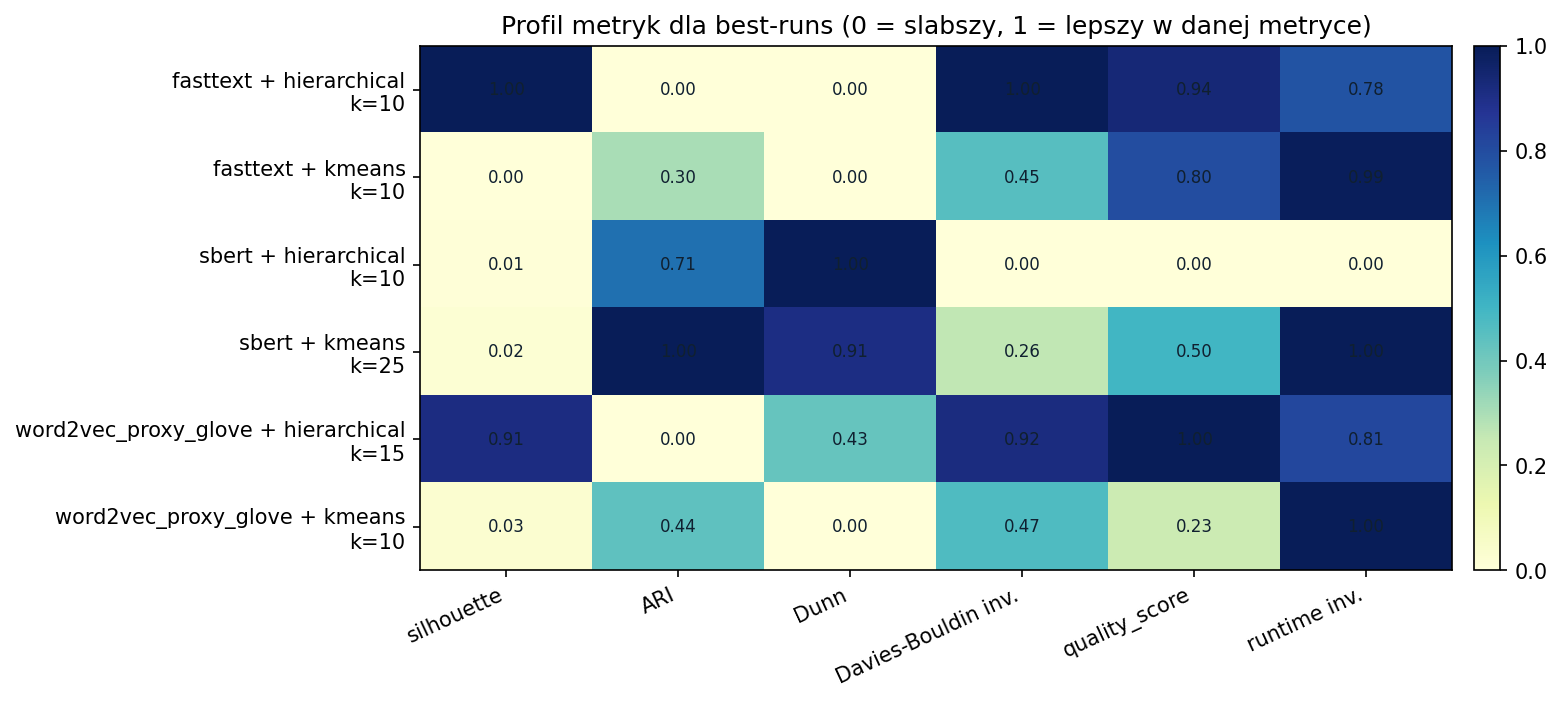

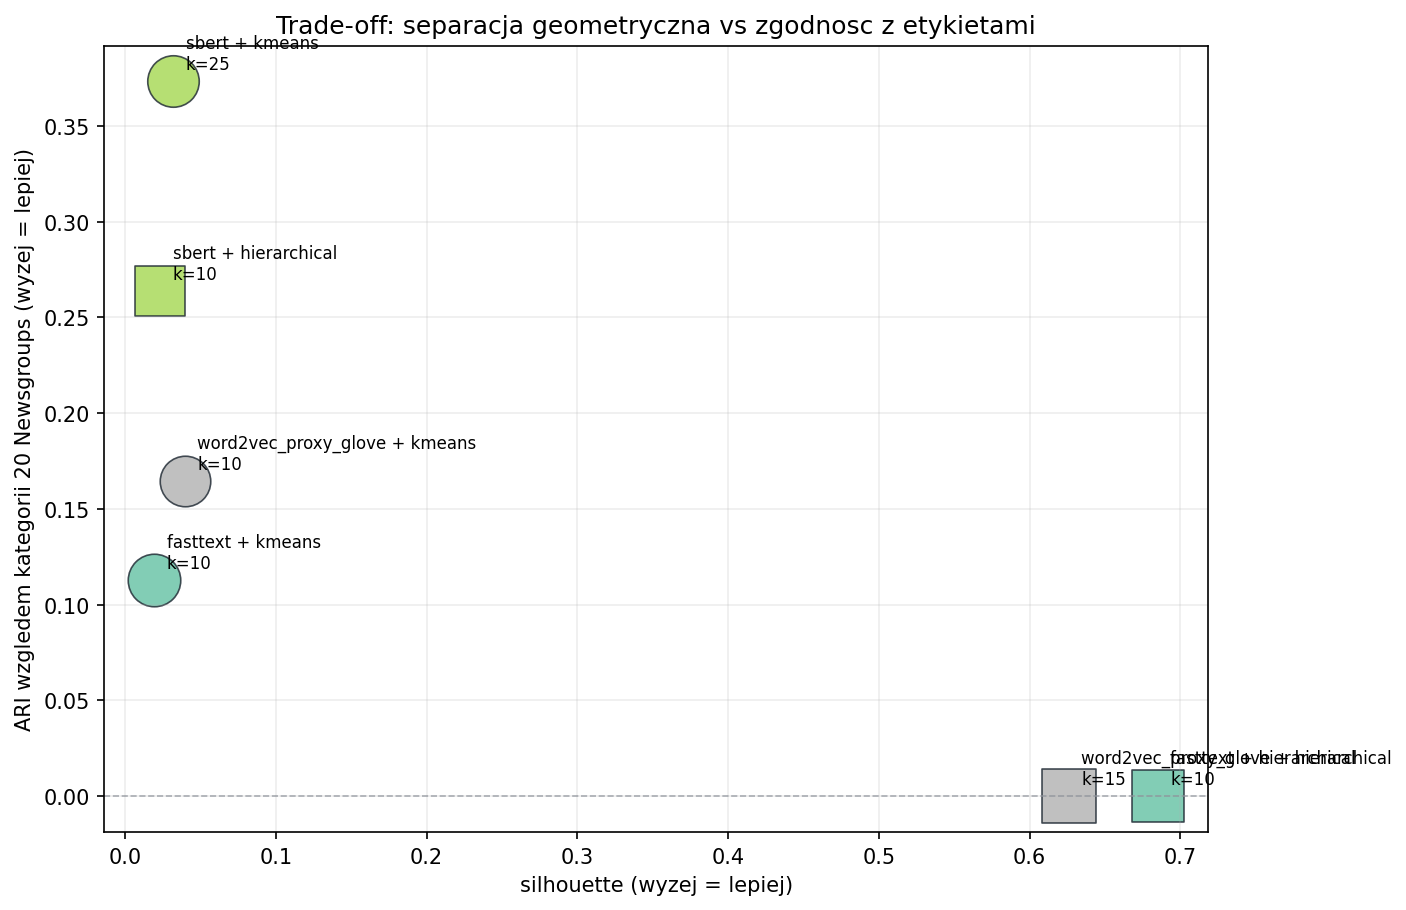

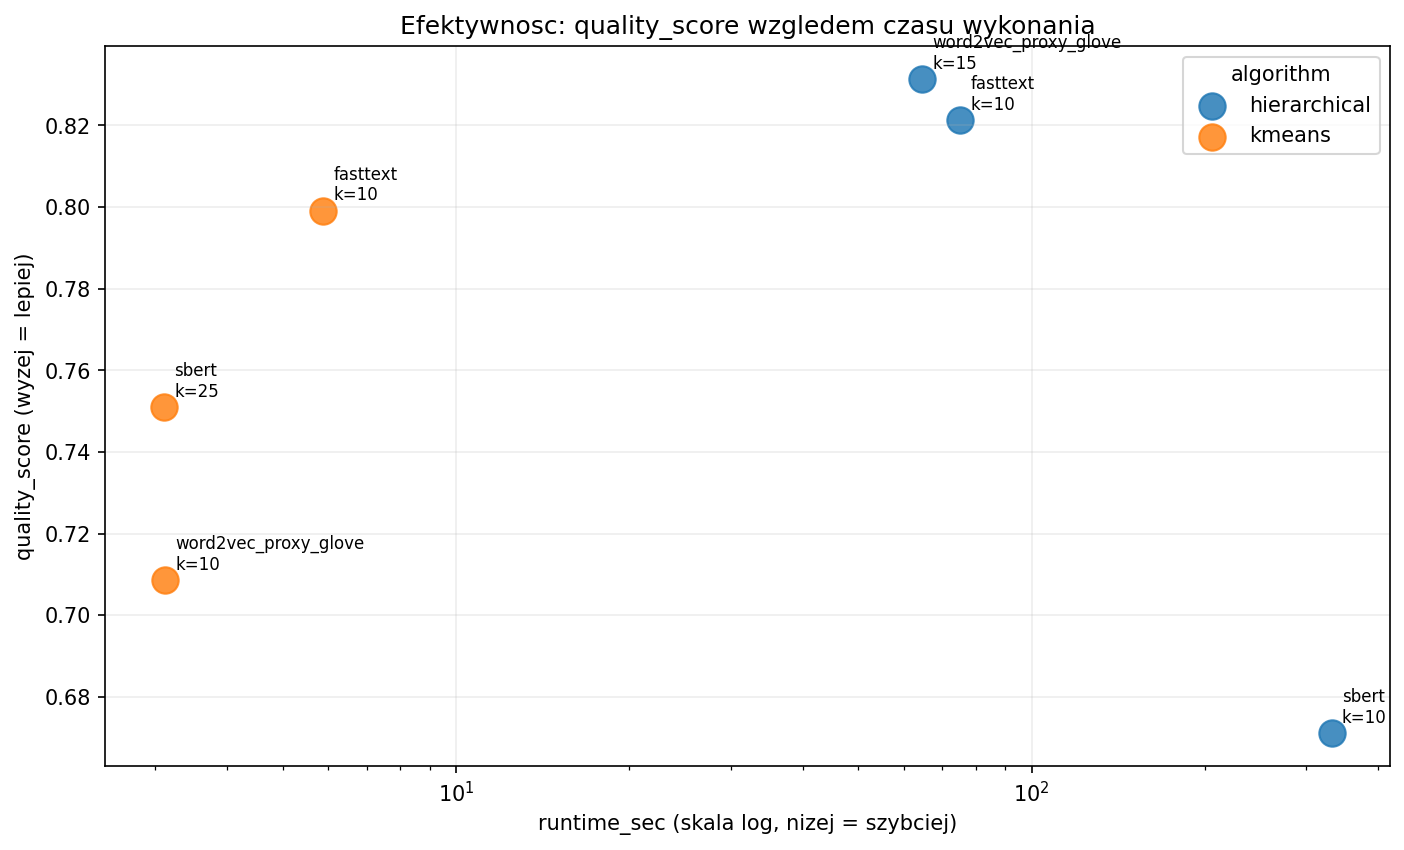

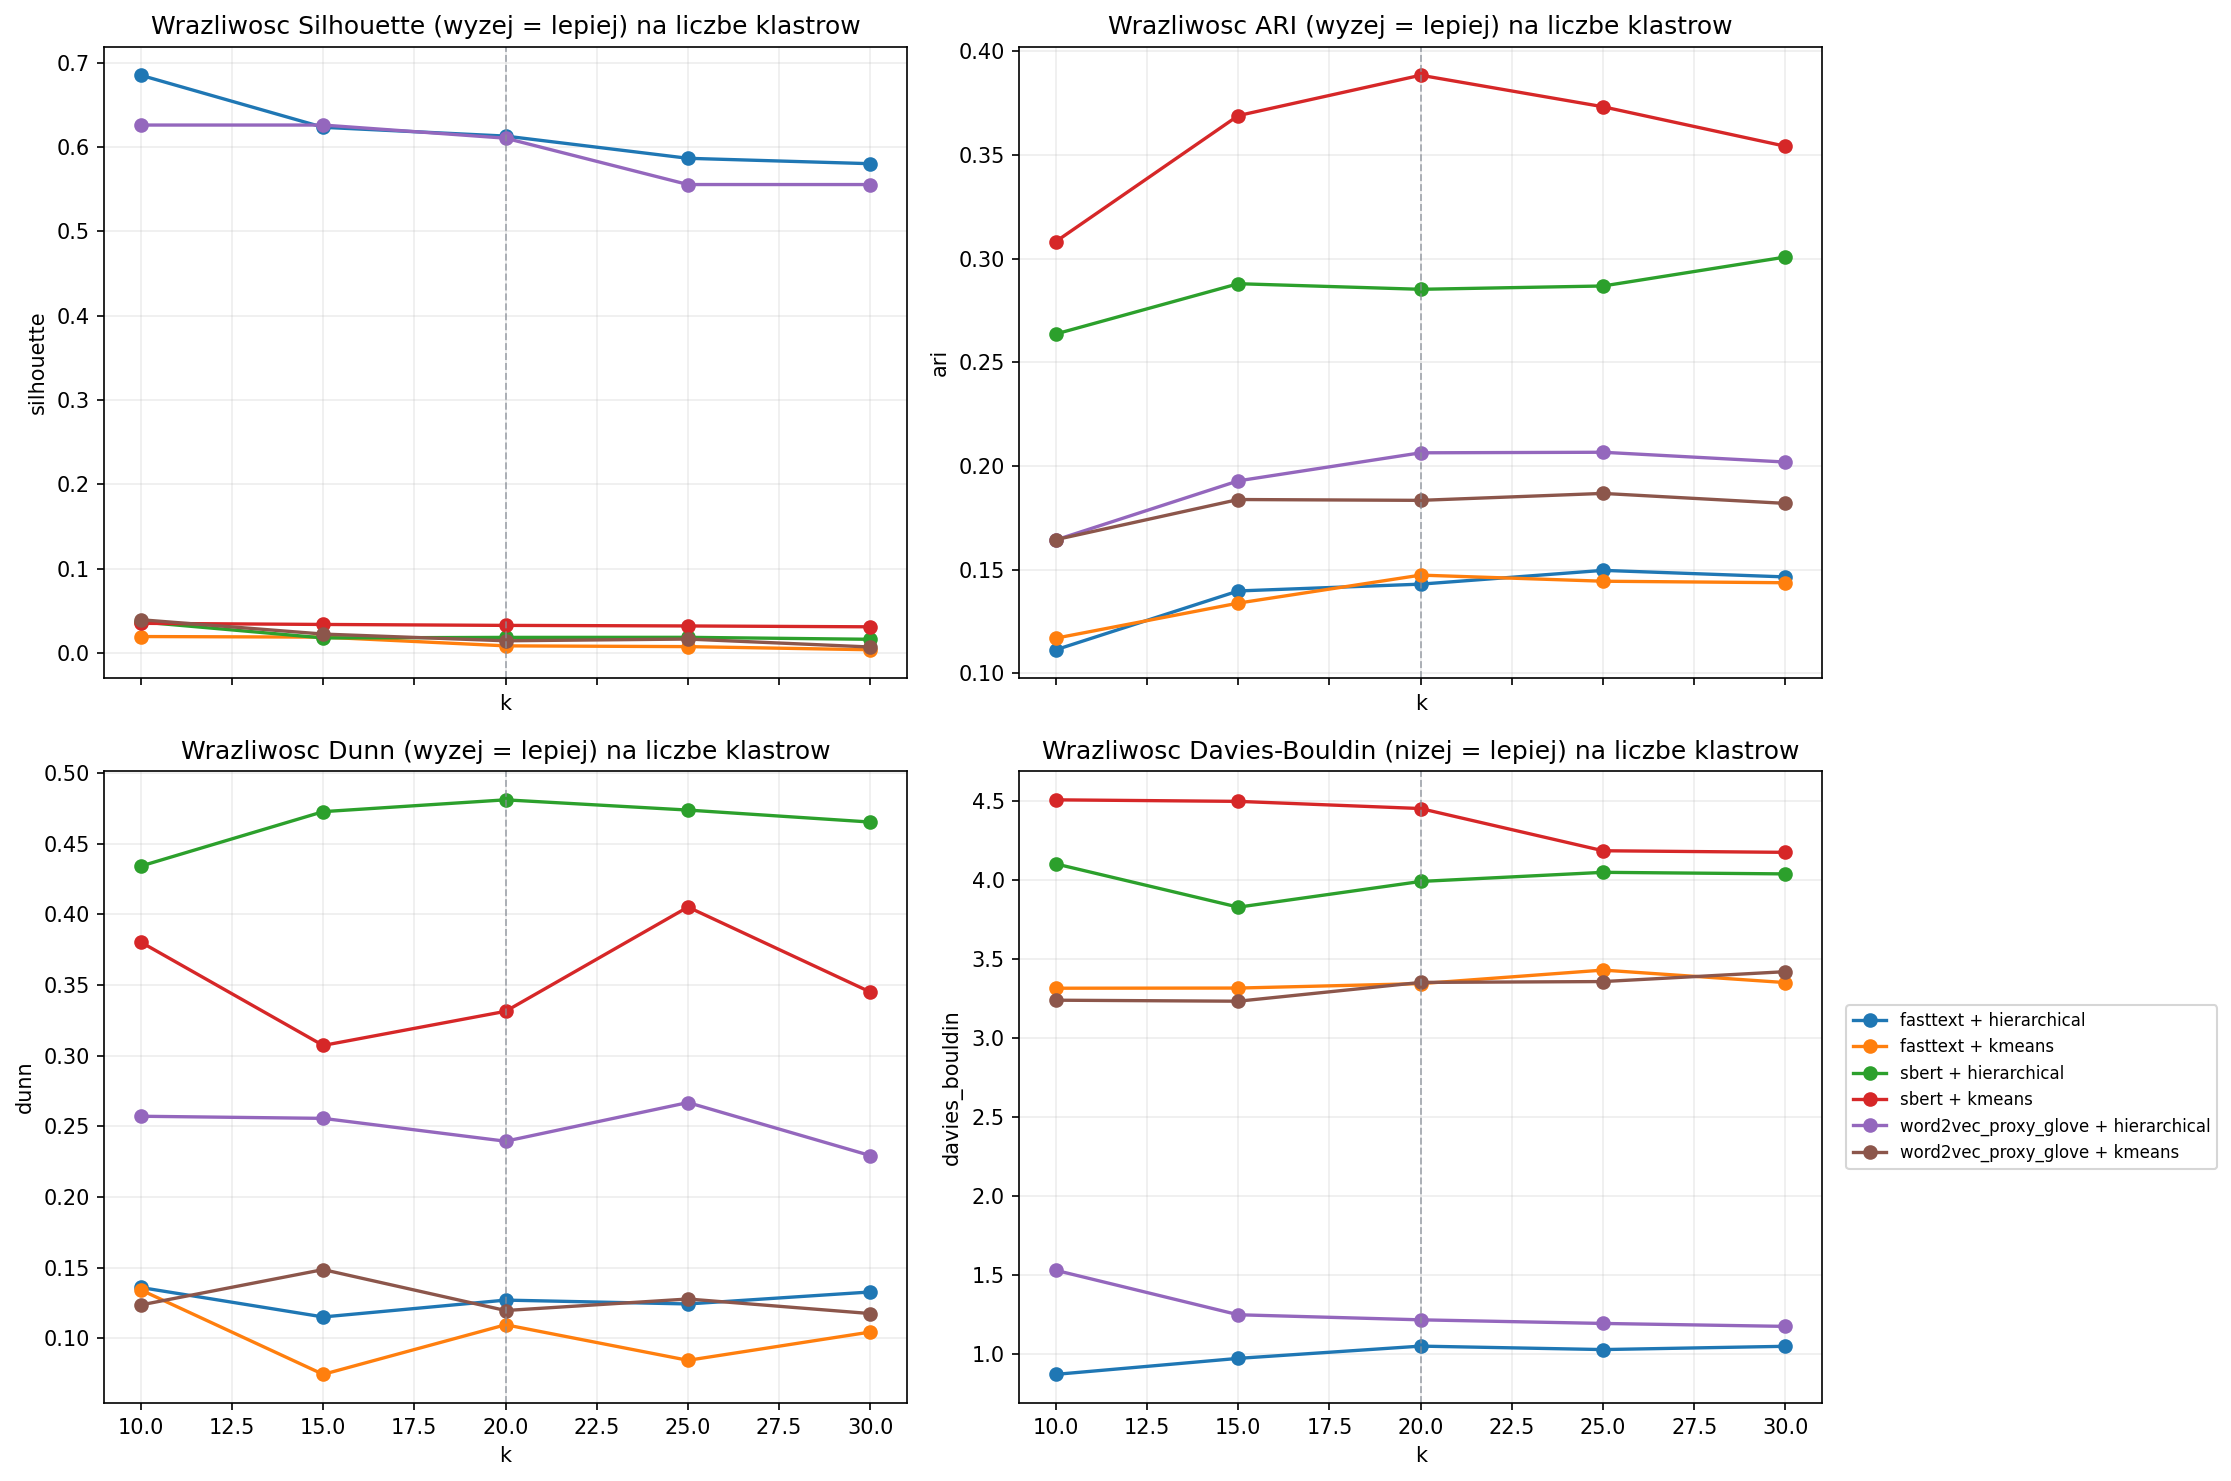

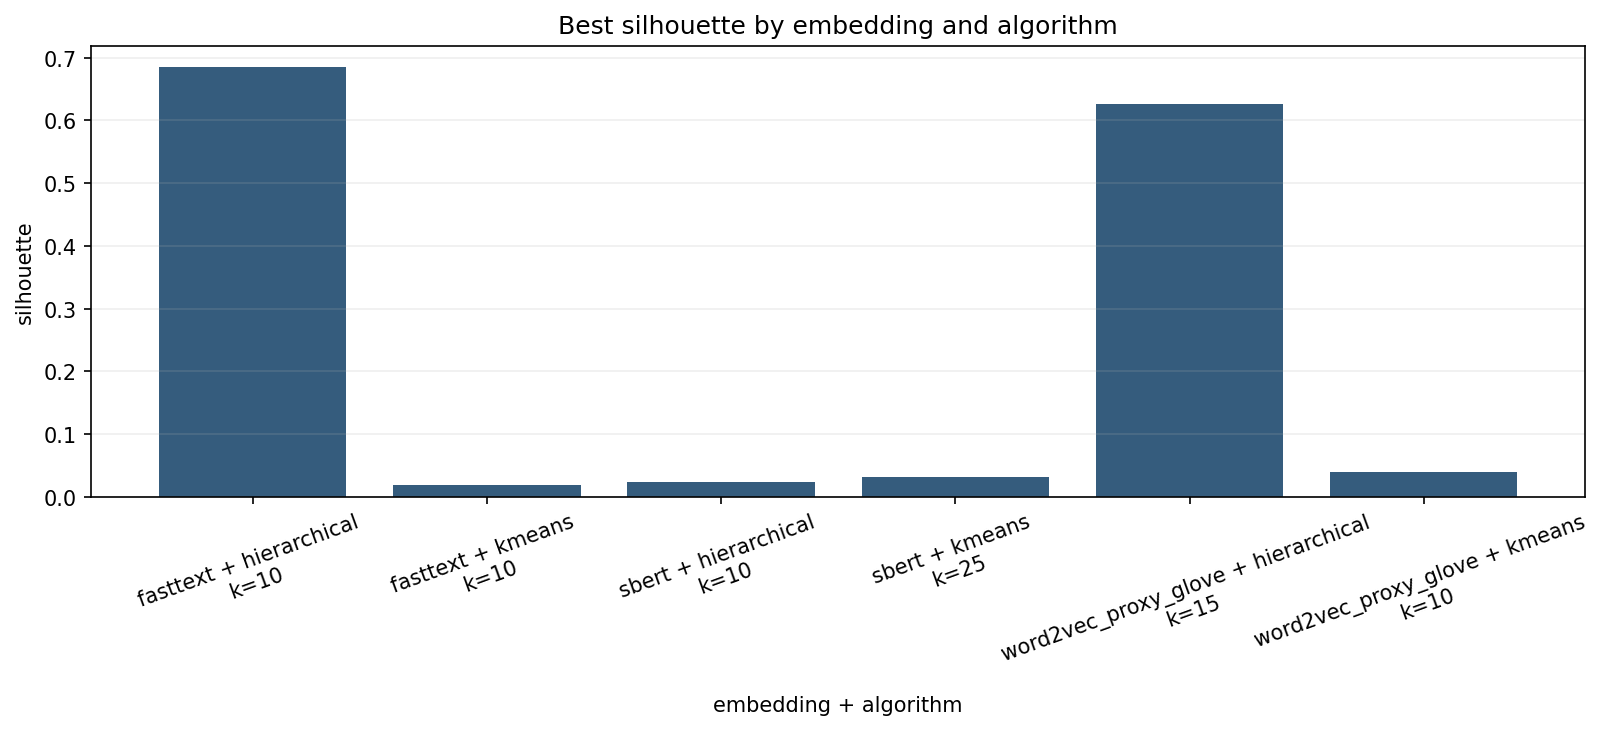

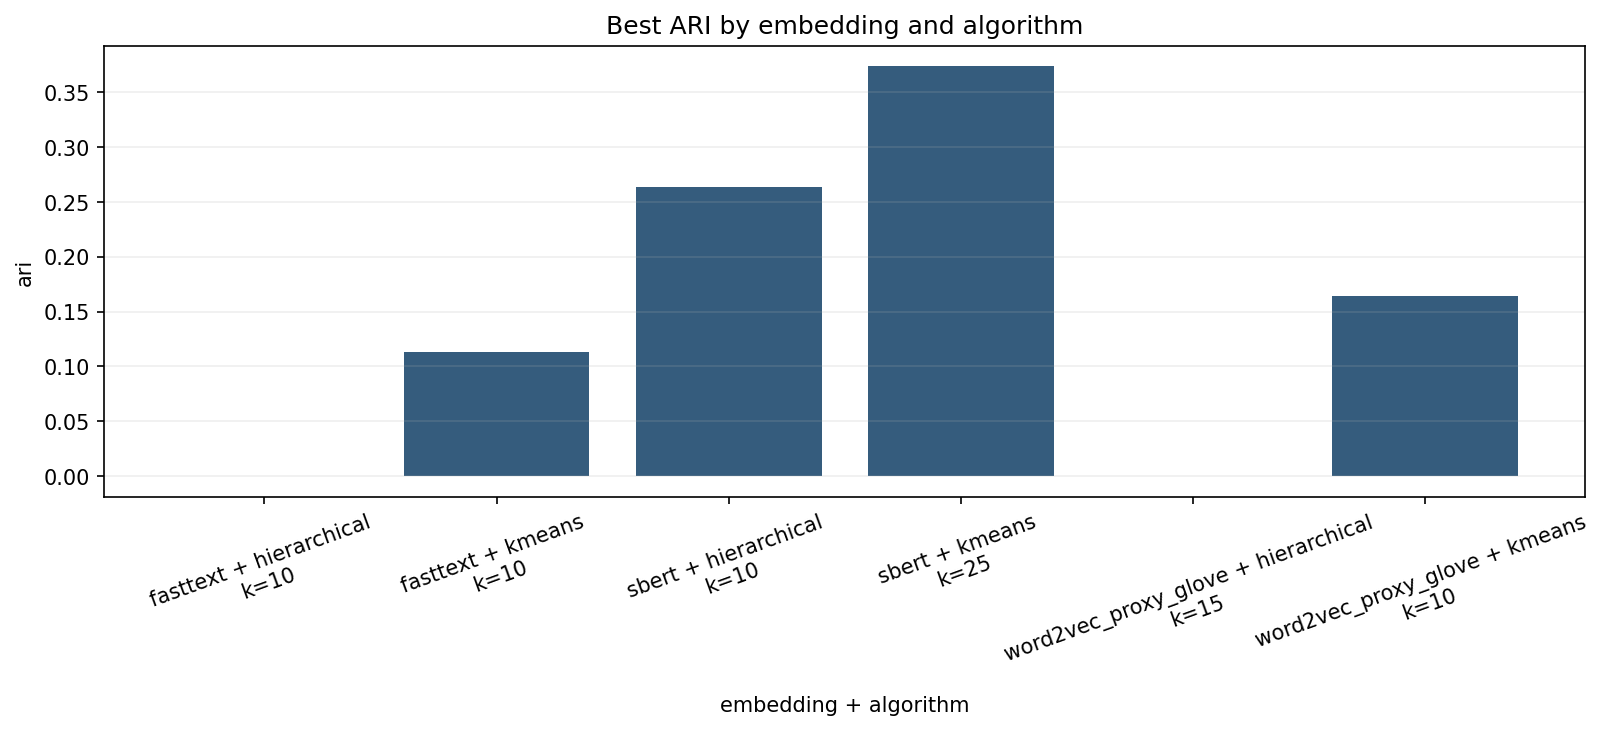

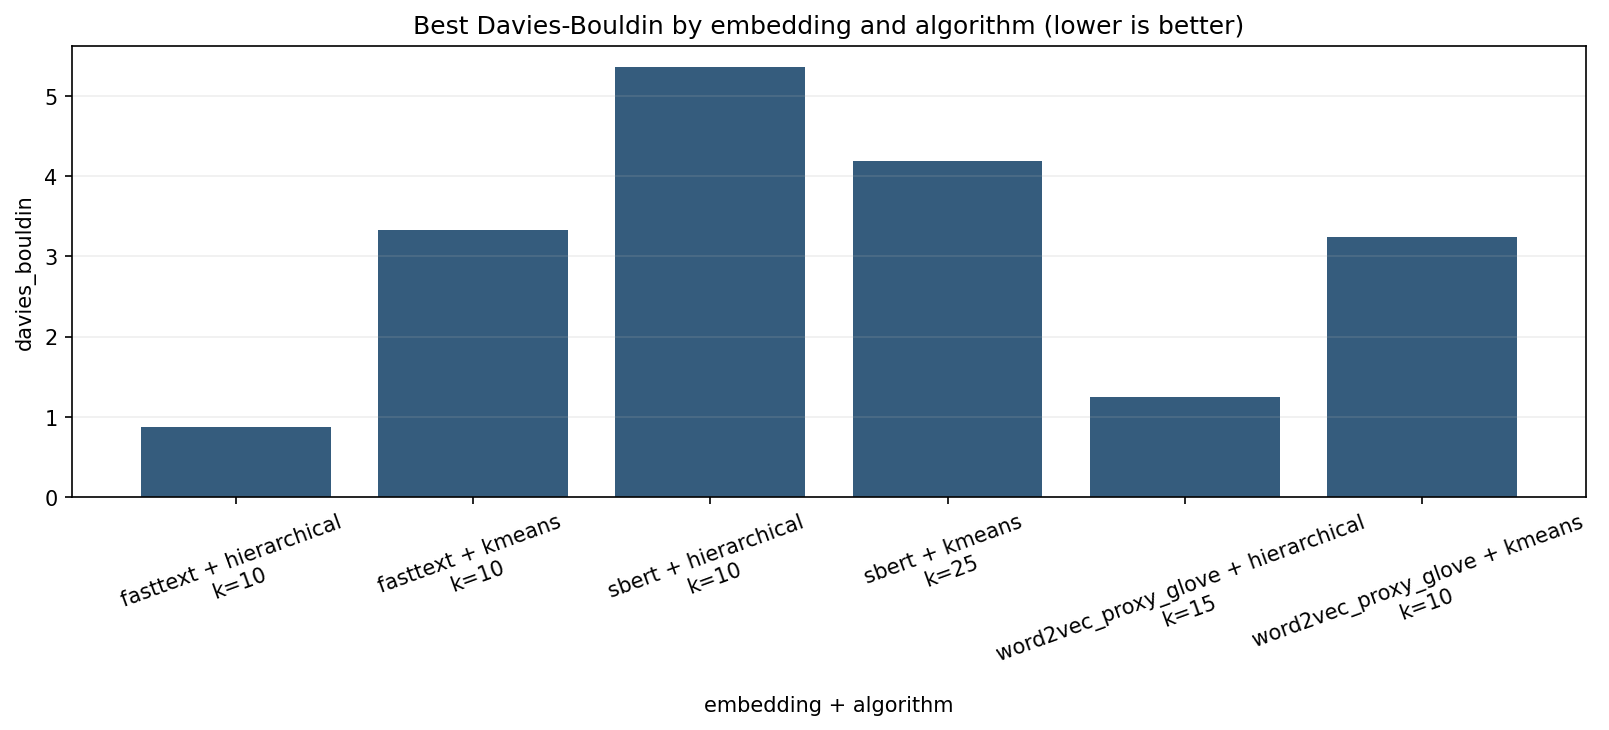

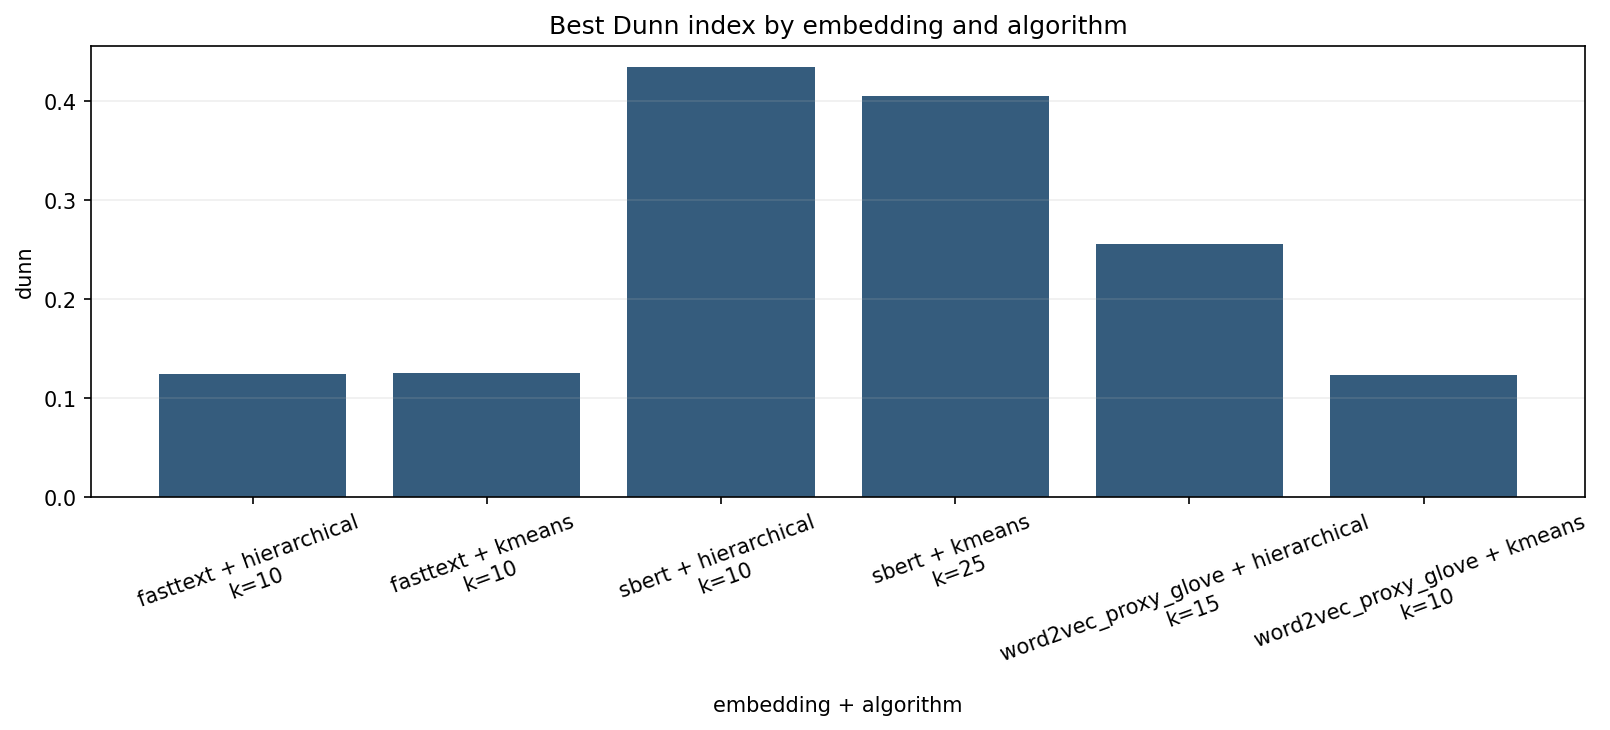

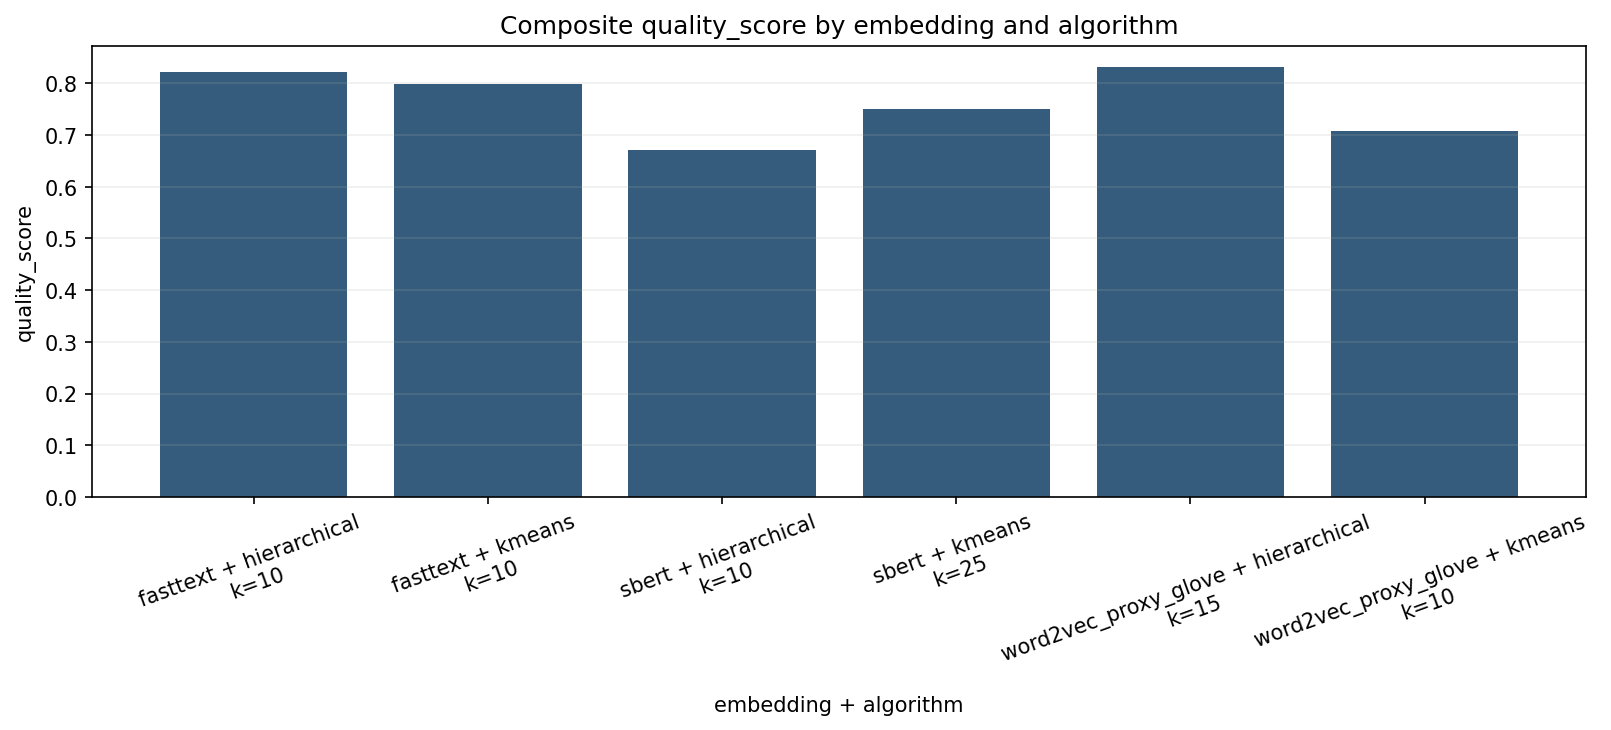

In [21]:

from IPython.display import Image, Markdown, display

section10_views = build_section10_views(
    best_runs_df=best_runs_df,
    interpretation_runs_df=interpretation_runs_df,
    cluster_profiles_df=cluster_profiles_df,
)

display(Markdown("### Tabela 10A. Leaderboard najlepszych przebiegow"))
display(section10_views["leaderboard"])

display(Markdown("### Tabela 10B. Podsumowanie reprezentacji"))
display(section10_views["embedding_summary"])

display(Markdown("### Tabela 10C. Podsumowanie algorytmow"))
display(section10_views["algorithm_summary"])

display(Markdown("### Tabela 10D. Analiza liczby klastrow (`k`)"))
display(section10_views["k_summary"])

if not section10_views["purity_summary"].empty:
    display(Markdown("### Tabela 10E. Zgodnosc klastrow z etykietami referencyjnymi"))
    display(section10_views["purity_summary"])

display(Markdown("### Wykresy przekrojowe sekcji 10"))
section10_plot_keys = [
    "section10_metric_profile_plot",
    "section10_tradeoff_plot",
    "section10_efficiency_plot",
    "section10_k_sensitivity_plot",
    "best_silhouette_plot",
    "best_ari_plot",
    "best_davies_bouldin_plot",
    "best_dunn_plot",
    "best_quality_score_plot",
]
for plot_key in section10_plot_keys:
    if plot_key in artifact_paths:
        display(Image(filename=artifact_paths[plot_key]))

## 11. Wnioski

**TODO**: Po wykonaniu notebooka uzupelnij wnioski na podstawie tabel i wykresow:
NP.:
- ktora reprezentacja ma najwyzszy `silhouette` i najnizszy `Davies-Bouldin`,
- czy `SBERT` poprawia separacje semantyczna wzgledem statycznych embeddingow,
- czy `K-means` i klasteryzacja hierarchiczna wskazuja podobna optymalna liczbe klastrow,
- jakie slowa i dokumenty najlepiej wyjasniaja najciekawsze klastry,
- jak wyniki `ARI` odnosza sie do prawdziwych kategorii `20 Newsgroups`.

## [TEMPLATE: Sekcja 11 - Wnioski i podsumowanie ogólne eksperymentu]
> **TODO:** W tej konkluzji opieramy się na całokształcie problemu (wyzwania przy redukcji wymiarów tekstowych, limitacje modeli).

### 11.1 Główne obserwacje
* *[Wylistuj główne punkty (takeaways) z całego projektu]*
1. ...
2. ...
3. ...

### 11.2 Rekomendacje dla przyszłych iteracji (Ograniczenia i Future Work)
* *[Zaproponuj modyfikacje, np. użycie modeli generatywnych (LLM), zmiana metod preprocessingu lub uwzględnienie metod t-SNE/UMAP przy pipeline (obecnie skupiliśmy się na metodach klasycznych)]*

## [TEMPLATE: Sekcja 12 - Weryfikacja pytań badawczych i hipotez]
> **TODO:** W oparciu o wygenerowane modele, odpowiedz na główne pytania badawcze ujęte w koncepcji projektu i uargumentuj je uzyskanymi metrykami z podsumowania.

### Hipoteza / Pytanie badawcze 1: *[Wpisz tu pierwsze główne pytanie]*
* **Rozstrzygnięcie**: *[uzupełnij]*
* **Uzasadnienie z wyników (metryki / czas przetwarzania)**: *[uzupełnij]*

### Hipoteza / Pytanie badawcze 2: *[Wpisz tu drugie pytanie]*
* **Rozstrzygnięcie**: *[uzupełnij]*
* **Uzasadnienie z wyników**: *[Algorytm...]*

### Hipoteza / Pytanie badawcze 3:
* **Rozstrzygnięcie**: *[uzupełnij]*
* **Uzasadnienie z wyników**: *[Algorytm...]*

### Końcowa weryfikacja obiektywna
*[Podsumowanie eksperymentów. Wybór najlepszych algorytmów. Ocena wykonania zadania]*